# Plotting notebook for geophysics
This notebook extracts and plots the geophysics compilation table. The steps are as follows:
- 1. Import dependencies and install packages
- 2. Import compilation
- 3. plot compilation

## 1. Import packages and setup folders and paths

### Install packages if not installed

In [108]:
#%pip install --upgrade DiadFit
#%pip install Thermobar



### Import packages

In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import DiadFit as pf
import os
import pickle
from labellines import labelLines
from scipy import stats, signal


mpl.rcParams['pdf.fonttype'] = 42  # 42 is for TrueType fonts
mpl.rcParams['font.size'] = 7
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["font.serif"] = ["Times New Roman"]

### Setup folders and data paths

In [110]:
# This is to make sure the code runs regardless of operating system
if os.name=='posix':
    slash='/'
else:
    slash='\\'

# Set master folder
MasterFolder=os.path.dirname(os.getcwd())

#Folder to save figures

figpath=MasterFolder +slash+"Plotting_notebooks"+slash+'Notebook_Figs'
if not os.path.exists(figpath):
    os.mkdir(figpath)
# Create folder to save full datasets

compilation_folder=MasterFolder +slash+"Plotting_notebooks"+slash+'Notebook_Compiled_data'
if not os.path.exists(compilation_folder):
    os.mkdir(compilation_folder)

### Create KS Bootstrapping functions

In [111]:
def calc_critKS_D(x1, x2, alpha=0.05):
    calpha_dict = {
        0.10: 1.22,
        0.05: 1.36,
        0.025: 1.48,
        0.01: 1.63,
        0.005: 1.73,
        0.001: 1.95
    }
    
    if alpha not in calpha_dict:
        raise ValueError(f"Alpha {alpha} not supported. Choose from {list(calpha_dict.keys())}")
    
    calpha = calpha_dict[alpha]
    
    criticalksD = calpha * np.sqrt((len(x1) + len(x2)) / (len(x1) * len(x2)))
    return criticalksD

def calculate_bootstrap_ks(data1, data2, data1_err, data2_err, 
                           alpha=0.05, iterations=2000,
                           plot=True,plot_method='plot',
                           xlabel="Depth (km)",
                           data1_label="Data1",
                           data2_label="Data2"):
    # plot_method can be 'plot' to get a simple CDF, smoothed. If anything else, it will use step function to plot.
    # if plot is true, a figure is produced, if anything else it will not plot. 

    def calculate_ks_stat(data1, data2):
        return stats.ks_2samp(data1, data2)

    bootstrap_ks_stats = []
    bootstrap_p_values = []
    resampled_distributions = []

    for _ in range(iterations):
        data1_resample = np.random.normal(data1, data1_err)
        data2_resample = np.random.normal(data2, data2_err)
        
        ks_result = calculate_ks_stat(data1_resample, data2_resample)
        bootstrap_ks_stats.append(ks_result.statistic)
        bootstrap_p_values.append(ks_result.pvalue)
        
        resampled_distributions.append({
            'data1_resample': np.sort(data1_resample),
            'data2_resample': np.sort(data2_resample),
        })

    bootstrap_ks_stats = np.array(bootstrap_ks_stats)
    bootstrap_p_values = np.array(bootstrap_p_values)

    data1_resample_sorted = np.sort(data1_resample)
    data2_resample_sorted = np.sort(data2_resample)

    original_ks_stat, original_p_value = calculate_ks_stat(data1, data2)
    critD=calc_critKS_D(data1_resample_sorted,data2_resample_sorted,alpha=alpha)

    res = {
        'original_ks_stat': original_ks_stat,
        'original_p_value': original_p_value,
        'critical D-val':critD,
        'bootstrap_ks_stats': bootstrap_ks_stats,
        'bootstrap_p_values': bootstrap_p_values,
        'bootstrap_ks_mean': np.mean(bootstrap_ks_stats),
        'bootstrap_ks_std': np.std(bootstrap_ks_stats),
        'bootstrap_p_mean': np.mean(bootstrap_p_values),
        'bootstrap_p_std': np.std(bootstrap_p_values),
        'data1_resample_sorted': data1,
        'data2_resample_sorted': data2,
        'resampled_distributions': resampled_distributions,
    }

    if plot!=False:
        fig,ax=plt.subplots(1,1, figsize=(7, 5))
        # This plots all the bootstraped CDF 
        for i, distribution in enumerate(res['resampled_distributions']):
            if plot_method!='plot':
                ax.step(np.concatenate([distribution['data1_resample'],distribution['data1_resample'][-1:]]),
                        np.arange(distribution['data1_resample'].size + 1) / distribution['data1_resample'].size, 
                        color='royalblue',alpha=0.2)
                ax.step(np.concatenate([distribution['data2_resample'],distribution['data2_resample'][-1:]]),
                        np.arange(distribution['data2_resample'].size + 1) / distribution['data2_resample'].size,
                          color='wheat',alpha=0.2)
            else:
                ax.plot(np.sort(distribution['data1_resample']), 
                        np.arange(1, len(distribution['data1_resample']) + 1) / len(distribution['data1_resample']), 
                        color='royalblue', alpha=0.2)
                ax.plot(np.sort(distribution['data2_resample']), 
                        np.arange(1, len(distribution['data2_resample']) + 1) / len(distribution['data2_resample']), 
                        color='wheat', alpha=0.2)
        

        # This plots the original data CDF
        if plot_method!='plot':
            ax.step(np.concatenate([res['data1_resample_sorted'],res['data1_resample_sorted'][-1:]]),
                    np.arange(res['data1_resample_sorted'].size + 1) / res['data1_resample_sorted'].size, 
                    color='midnightblue', linewidth=2,label=data1_label)
            ax.step(np.concatenate([res['data2_resample_sorted'],res['data2_resample_sorted'][-1:]]),
                    np.arange(res['data2_resample_sorted'].size + 1) / res['data2_resample_sorted'].size, 
                    color='darkorange', linewidth=2,label=data2_label)
        else:
            ax.plot(res['data1_resample_sorted'], 
                    np.arange(1, len(res['data1_resample_sorted']) + 1) / len(res['data1_resample_sorted']), 
                    color='midnightblue',linewidth=2, label=data1_label)
            ax.plot(res['data2_resample_sorted'], 
                    np.arange(1, len(res['data2_resample_sorted']) + 1) / len(res['data2_resample_sorted']), 
                    color='darkorange',linewidth=2, label=data2_label)

        handles, labels = ax.get_legend_handles_labels()
        unique = dict(zip(labels, handles))

        stats_text = f"Sample KS Statistic: {res['original_ks_stat']:.3f}\n" \
                    f"Sample P-val: {res['original_p_value']:.2e}\n" \
                    f"Critical KS D - conf {alpha}: {res['critical D-val']:.3f}\n" \
                    f"MC KS Mean: {res['bootstrap_ks_mean']:.3f} ± {res['bootstrap_ks_std']:.3f}\n" \
                    f"MC P-val Mean: {res['bootstrap_p_mean']:.3f} ± {res['bootstrap_p_std']:.3f}"

        dummy_handle = mpl.lines.Line2D([], [], color='none')
        handles = list(unique.values()) + [dummy_handle]
        labels = list(unique.keys()) + [stats_text]

        ax.legend(handles, labels, loc='lower right', handletextpad=0.25,handlelength=0.5,fancybox=False,edgecolor='k')

        ax.set_xlim([0,max(data1.max(), data2.max())])
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Cumulative probability")



    if 'fig' in locals():
        final_result=fig,res
    else:
        final_result=res
    
    return final_result

## 2. Import all datasets

### Import geophysics compilation

In [112]:
geophysics=pd.read_excel(MasterFolder +slash+'geophysics compilation_2Dec25.xlsx') # has the explanation row. Unecessary after this
geophysics = geophysics.drop(index=0)
geophysics.head(1)

,Reference Study,Publication year,Ref short,Activity,Data year,Data year end,"Main Geophysical method (Deformation, Seismic, Gravity, Electromagnetic)",Study type,Deformation source geometry,Source #,...,Time Period (month/year or year),Reservoir locations,"Depth measured, inferred, external (M or I,E)","Reservoir depth is a range (R ), mean (A), best-fit (B), Best-fit MCMC (BMC)",Depth (km),Depth uncertainty left (-km),Depth uncertainty right (+km),Cumulate upper depth (km),Cumulate lower depth (km),Comments
1,Mogi [1958],1958,M58,"Deflation of summit related to 1924 eruption, ...",1924,NaN,Deformation,"Tilt, triangulation; Point source",Point source,1,...,1912-1927,1-2 km S of Halema'uma'u,M,B,3.5,1,1,NaN,NaN,"Assumed spherical source, visual matching of t..."


### Import magma supply compilation

In [113]:
magsup=pd.read_excel(MasterFolder +slash+'magma_volume_estimates.xlsx') # has the explanation row. Unecessary after this
magsup = magsup.drop(index=0)
magsup.head()

,Start year,End year,Month/Day,Duration (days),Location,Location name,Volume (m3),Volume (km3),Magma supply km3/yr
1,-200,1000,NaN,438000,Summit,Uēkahuna Ash,300000000,0.3,0.00025
2,1000,1500,NaN,182500,Rift zones and summit,Effusive period comprising ‘Ailā‘au flows,11000000000,11,0.022
3,1410,1470,NaN,21900,East rift,‘Ailā‘au flows,6000000000,6,0.1
4,1500,1800,NaN,109500,Summit,Keanakākoʻi Tephra,NaN,0.15,0.0005
5,1750,1750,NaN,NaN,East rift,Late Keanakākoʻi era flow?,14200000,0.0142,NaN


Text(0, 0.5, 'Magma supply rate (km3/yr)')

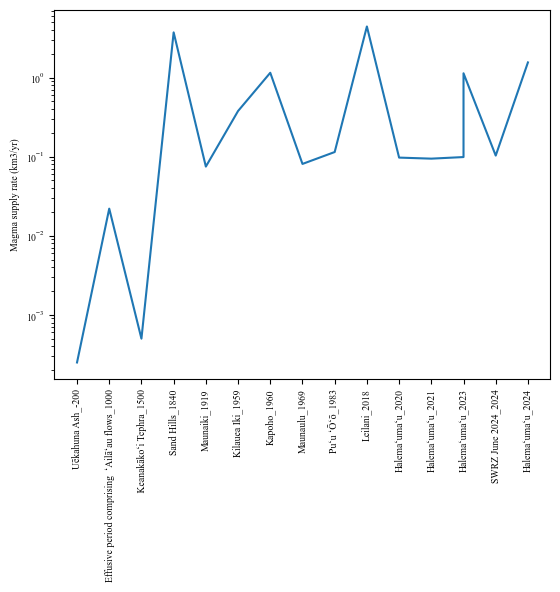

In [114]:
magsup['Location name_year'] = magsup['Location name'] + '_' + magsup['Start year'].astype(str)

filter=(~magsup['Location name'].str.contains("Dec 1974|Late Keanakākoʻi era flow?"))&(~(magsup['Start year']==1410))

plt.plot(magsup['Location name_year'][filter],magsup['Magma supply km3/yr'][filter])
plt.yscale('log')
plt.xticks(rotation=90)
plt.ylabel("Magma supply rate (km3/yr)")


### Import new Pre-Post Caldera data


In [115]:
newdata=pd.read_excel(MasterFolder +slash+"Data_processing_notebooks"+slash+'Notebook_Compiled_data'+slash+'FinalNewDataset.xlsx')

newdata =newdata.loc[:, ~newdata.columns.str.contains('Unnamed')].copy()
newdata = newdata.drop(columns='i')
newdata['Day']=newdata['Day'].astype(int)
newdata.insert(newdata.columns.get_loc('Atomic %_Ti_Ol')+1,'Total_Atomic%_Ol',newdata.loc[:, (newdata.columns.str.contains('Atomic'))&(newdata.columns.str.contains('Ol'))].sum(axis=1).where(lambda x: x != 0, np.nan))
newdata.insert(newdata.columns.get_loc('Total_Atomic%_Ol')+1,'(Mg+Fe)/Si_Atomic%_Ol',(newdata['Atomic %_Mg_Ol']+newdata['Atomic %_Mg_Ol'])/newdata['Atomic %_Si_Ol'].where(lambda x: x != 0, np.nan))
newdata.insert(newdata.columns.get_loc('σ Density g/cm3 (from densimeter)'),'σ Density g/cm3 (from DiadFit for individual, Std dev for averaged FI)',np.nan)
# newdata.to_clipboard(excel=True)
newdata.head()


,filename,Density g/cm3,σ Density g/cm3,σ Density g/cm3 (from Ne+peakfit),"σ Density g/cm3 (from DiadFit for individual, Std dev for averaged FI)",σ Density g/cm3 (from densimeter),Corrected_Splitting,Corrected_Splitting_σ,Corrected_Splitting_σ_Ne,Corrected_Splitting_σ_peak_fit,...,T_K_input,error_T_K,CO2_dens_gcm3_input,error_CO2_dens_gcm3,crust_dens_kgm3_input,error_crust_dens_kgm3,model,EOS,XH2O_input,error_XH2O
0,919_50_FIA,0.141984,0.008781,0.007880,NaN,0.003876,103.108584,0.019886,0.000992,0.019891,...,1586.067191,50,0.141984,0.008781,NaN,0,denlinger_lerner,DZ06,0.065145,0.033490
1,919_50_FIB,0.151694,0.004892,0.002947,NaN,0.003905,103.133089,0.007437,0.000995,0.007381,...,1586.067191,50,0.151694,0.004892,NaN,0,denlinger_lerner,DZ06,0.061202,0.031835
2,919_51_FIA,0.191270,0.004434,0.003749,NaN,0.002369,103.221905,0.009185,0.001005,0.009143,...,1585.870579,50,0.191270,0.004434,NaN,0,denlinger_lerner,DZ06,0.051709,0.028335
3,919_52_FIA,0.153743,0.004916,0.002978,NaN,0.003912,103.138260,0.007515,0.001008,0.007458,...,1581.879866,50,0.153743,0.004916,NaN,0,denlinger_lerner,DZ06,0.060602,0.031591
4,919_52_FIB,0.143131,0.005096,0.003305,NaN,0.003879,103.111478,0.008341,0.001011,0.008292,...,1582.911649,50,0.143131,0.005096,NaN,0,denlinger_lerner,DZ06,0.064755,0.033323


### Import the re-processed JPET data (September 2023 rapid response)
We re-processed (SO2 mol%, T from Fo, XH2O and PD MC simulations) this literature dataset for consistency in comparisons

In [116]:
K23=pd.read_excel(MasterFolder +slash+"Data_processing_notebooks"+slash+'Data_reprocessing_Literature'+slash+'Notebook_Compiled_data'+slash+'K23_recalculated.xlsx')

## We need to drop some old columns and rename some others to merge correctly with the new data

K23 =K23.loc[:, ~K23.columns.str.contains('Unnamed|Old|P_kbar_1150C|SO2_mol%|py_index|Recalculations for Pre-Post Caldera paper >|T_C')]
K23 = K23.drop(columns='i')
K23['decrepit']=K23['decrepit'].astype(object)
K23['sulfide']=K23['sulfide'].astype(object)
K23.drop(columns=['Column headers', 'EDS Data >>', 'Depth (km)_ryanlerner',], inplace=True)
K23.rename(columns={'Corrected_Splitting (cm-1)':'Corrected_Splitting', 
                     'Splitting (cm-1)':'Splitting',
                    'Crystal Name':'Sample_crystal',
                    'EDS_Name':'Name_on_SEM',
                    'FI Name':'FI_name',
                    'O':'Atomic %_O_Ol','Mg':'Atomic %_Mg_Ol','Fe':'Atomic %_Fe_Ol','Si':'Atomic %_Si_Ol',
                    'Total':"Total_Atomic%_Ol",
                    '(Mg+Fe)/Si':'(Mg+Fe)/Si_Atomic%_Ol',
                    'Filename':'filename',
                    'Fo':'Fo_Ol',
                    'SO2 mol%_recalculated':'SO2 mol%',
                    'σ Density g/cm3 (DiadFit)':'σ Density g/cm3',
                    'Reported density mean of reps?':'averaged?',
                    'STDofreps_Density g/cm3':'Density g/cm3_Raman_STD',
                    'σ Density g/cm3 (as plotted, from DiadFit for individual, Std dev for averaged FI)':'σ Density g/cm3 (from DiadFit for individual, Std dev for averaged FI)'}
                    , inplace=True)

K23.head()


,Sample_crystal,FI_name,averaged?,Density g/cm3,"σ Density g/cm3 (from DiadFit for individual, Std dev for averaged FI)",Density g/cm3_Raman_STD,σ Density g/cm3,σ Density g/cm3 (from Ne+peakfit),σ Density g/cm3 (from densimeter),Corrected_Splitting,...,T_K_input,error_T_K,CO2_dens_gcm3_input,error_CO2_dens_gcm3,crust_dens_kgm3_input,error_crust_dens_kgm3,model,EOS,XH2O_input,error_XH2O
0,K23_101,K23_101_FIC,No,0.085665,0.007736,NaN,0.007736,0.006738,0.003801,102.966450,...,1565.805593,50,0.085665,0.007736,NaN,0,denlinger_lerner,DZ06,0.108233,0.053578
1,K23_101,K23_101_FID,No,0.100137,0.005037,NaN,0.005037,0.003301,0.003805,103.002974,...,1565.805593,50,0.100137,0.005037,NaN,0,denlinger_lerner,DZ06,0.093852,0.046643
2,K23_102,K23_102_FIA,No,0.112454,0.004482,NaN,0.004482,0.002350,0.003817,103.034058,...,1564.096549,50,0.112454,0.004482,NaN,0,denlinger_lerner,DZ06,0.083756,0.041885
3,KS23_103,K23_103_FIC,No,0.114374,0.004013,NaN,0.004013,0.001231,0.003819,103.038904,...,1511.482018,50,0.114374,0.004013,NaN,0,denlinger_lerner,DZ06,0.085135,0.042535
4,KS23_103,K23_103_FID,Yes,0.126346,0.001619,0.001619,0.004087,0.001400,0.003839,103.069118,...,1511.482018,50,0.126346,0.001619,NaN,0,denlinger_lerner,DZ06,0.076872,0.038712


### Now merge K23 with all except LERZ2018 

In [117]:
newdata_noK23=newdata.copy()
newdata=pd.merge(newdata,K23,how='outer')
newdata['SO2 mol%']=newdata['SO2 mol%'].fillna(0)
newdata=newdata.copy()

### Now create location column to ID sample origin
- the location column is to identify the region of the eruption (SSWRZ, VSWRZ, ERZ, Summit)

In [118]:
newdata['FI_type']=newdata['FI_type'].astype(str) # this is for later, to make sure it's a string column
newdata['Eruption_location_type(ERZ,VSWRZ,SSWRZ,Summit)']= ''

newdata.loc[newdata['Sample'].str.contains('UW|914|916|917|924|K20|K23|KD24|K21|921'),'Eruption_location_type(ERZ,VSWRZ,SSWRZ,Summit)'] = "Summit"
newdata.loc[newdata['Sample'].str.contains('L84|909|908|910'),'Eruption_location_type(ERZ,VSWRZ,SSWRZ,Summit)'] = "ERZ"
newdata.loc[newdata['Sample'].str.contains('919|920|K24'),'Eruption_location_type(ERZ,VSWRZ,SSWRZ,Summit)'] = "SSWRZ"
newdata.loc[newdata['Sample'].str.contains('930|931'),'Eruption_location_type(ERZ,VSWRZ,SSWRZ,Summit)'] = "VSWRZ"
newdata.head()


,filename,Density g/cm3,σ Density g/cm3,σ Density g/cm3 (from Ne+peakfit),"σ Density g/cm3 (from DiadFit for individual, Std dev for averaged FI)",σ Density g/cm3 (from densimeter),Corrected_Splitting,Corrected_Splitting_σ,Corrected_Splitting_σ_Ne,Corrected_Splitting_σ_peak_fit,...,error_T_K,CO2_dens_gcm3_input,error_CO2_dens_gcm3,crust_dens_kgm3_input,error_crust_dens_kgm3,model,EOS,XH2O_input,error_XH2O,"Eruption_location_type(ERZ,VSWRZ,SSWRZ,Summit)"
0,NaN,0.004106,0.000000,0.000000,0.0,0.000000,102.760619,0.032383,0.000252,0.032459,...,50,0.004106,0.000000,NaN,0,denlinger_lerner,DZ06,0.263381,0.145350,Summit
1,KL0920_c216_a2_FID,0.006448,0.020385,0.019995,NaN,0.003967,102.766530,0.050463,0.000777,0.050564,...,50,0.006448,0.020385,NaN,0,denlinger_lerner,DZ06,0.257385,0.140755,SSWRZ
2,K24_5_FIA,0.008291,0.005223,0.003406,NaN,0.003960,102.771180,0.008596,0.000935,0.008562,...,50,0.008291,0.005223,NaN,0,denlinger_lerner,DZ06,0.250687,0.135796,SSWRZ
3,KL0921_c288_a1_FIA,0.009482,0.015142,0.014616,NaN,0.003955,102.774185,0.036887,0.000666,0.036961,...,50,0.009482,0.015142,NaN,0,denlinger_lerner,DZ06,0.248156,0.133970,Summit
4,K21-78b-FI#5,0.009713,0.009637,0.008789,NaN,0.003954,102.774769,0.022180,0.000592,0.022219,...,50,0.009713,0.009637,NaN,0,denlinger_lerner,DZ06,0.246373,0.132693,Summit


### Now we add a new column with the Event description

In [119]:
newdata['Eruption_title']= ''

eruption_map = {
    r"UW": "Kulanaokuaiki \n(400-650)",
    r"K21|921": "Circ. flow\n(~1700)",
    r"L84": "Sand Hill\n(1840)",
    r"930": "Mauna Iki VSWRZ\n(1919-1920)",
    r"909": "ERZ (May 1969)",
    r"908": "ERZ (Dec 1969)",
    r"916": "IC (Aug 1971)",
    r"931": "VSWRZ\n(Sep 1971)",
    r"914": "IC\n(Sep 1971)",
    r"910": "ERZ (Nov 1973)",
    r"917": "IC\n(Jul 1974)",
    r"924": "EC\n (Jul 1974)",
    r"919|920": "SSWRZ\n(Dec 1974)",
    r"K20": "IC\n(Dec 2020)",
    r"K23": "IC\n(Sept 2023)",
    r"K24": "SSWRZ\n(June 2024)",
    r"KD24": "IC\n(Dec 2024)"
}

for pattern, title in eruption_map.items():
    newdata.loc[newdata['Sample'].str.contains(pattern, regex=True), 'Eruption_title'] = title

newdata.head()

,filename,Density g/cm3,σ Density g/cm3,σ Density g/cm3 (from Ne+peakfit),"σ Density g/cm3 (from DiadFit for individual, Std dev for averaged FI)",σ Density g/cm3 (from densimeter),Corrected_Splitting,Corrected_Splitting_σ,Corrected_Splitting_σ_Ne,Corrected_Splitting_σ_peak_fit,...,CO2_dens_gcm3_input,error_CO2_dens_gcm3,crust_dens_kgm3_input,error_crust_dens_kgm3,model,EOS,XH2O_input,error_XH2O,"Eruption_location_type(ERZ,VSWRZ,SSWRZ,Summit)",Eruption_title
0,NaN,0.004106,0.000000,0.000000,0.0,0.000000,102.760619,0.032383,0.000252,0.032459,...,0.004106,0.000000,NaN,0,denlinger_lerner,DZ06,0.263381,0.145350,Summit,IC\n(Sept 2023)
1,KL0920_c216_a2_FID,0.006448,0.020385,0.019995,NaN,0.003967,102.766530,0.050463,0.000777,0.050564,...,0.006448,0.020385,NaN,0,denlinger_lerner,DZ06,0.257385,0.140755,SSWRZ,SSWRZ\n(Dec 1974)
2,K24_5_FIA,0.008291,0.005223,0.003406,NaN,0.003960,102.771180,0.008596,0.000935,0.008562,...,0.008291,0.005223,NaN,0,denlinger_lerner,DZ06,0.250687,0.135796,SSWRZ,SSWRZ\n(June 2024)
3,KL0921_c288_a1_FIA,0.009482,0.015142,0.014616,NaN,0.003955,102.774185,0.036887,0.000666,0.036961,...,0.009482,0.015142,NaN,0,denlinger_lerner,DZ06,0.248156,0.133970,Summit,Circ. flow\n(~1700)
4,K21-78b-FI#5,0.009713,0.009637,0.008789,NaN,0.003954,102.774769,0.022180,0.000592,0.022219,...,0.009713,0.009637,NaN,0,denlinger_lerner,DZ06,0.246373,0.132693,Summit,Circ. flow\n(~1700)


### Import the re-processed LERZ 2018 data (GPL paper)
We re-processed (SO2 mol%, T from Fo, XH2O and PD MC simulations) this literature dataset for consistency in comparisons

In [120]:
LERZ2018=pd.read_excel(MasterFolder +slash+"Data_processing_notebooks"+slash+'Data_reprocessing_Literature'+slash+'Notebook_Compiled_data'+slash+'LERZ2018_recalculated.xlsx')
LERZ2018 =LERZ2018.loc[:, ~LERZ2018.columns.str.contains('Unnamed')]
LERZ2018['Day']=LERZ2018['Day'].astype(int)
LERZ2018['Int_time (s)']=LERZ2018['Int_time (s)'].astype(float)
LERZ2018['Sample_crystal']=LERZ2018['Host crystal ID']
LERZ2018['SO2 mol%']=LERZ2018['SO2 mol%_recalculated'].fillna(0)
LERZ2018['Eruption_location_type(ERZ,VSWRZ,SSWRZ,Summit)']= 'ERZ'
LERZ2018['Eruption_title']= 'LERZ\n(May-Aug 2018)'
LERZ2018['Sample']=LERZ2018["Event ID (LL8 - July, LL7-Aug, LL4-May)"]
LERZ2018['FI_name']=LERZ2018['Fluid inclusion ID']

LERZ2018.head()

,Py_index,Event Description,"Event ID (LL8 - July, LL7-Aug, LL4-May)",Host crystal ID,Fluid inclusion ID,Raman Data >,Fermi Diad separation ΔCO2 (cm-1),Corrected ΔCO2 (cm-1),Corrected ΔCO2 1σ (cm-1),CO2 density (g/cm3),...,model,EOS,XH2O_input,error_XH2O,Sample_crystal,SO2 mol%,"Eruption_location_type(ERZ,VSWRZ,SSWRZ,Summit)",Eruption_title,Sample,FI_name
0,0,"LERZ, Fissure 8, May 30th 2018",LL4,LL4-14dp,LL4-14dp-FI#1,ν1 refers to the low wavenumber band of the fe...,103.416763,103.186144,0.006461,0.176605,...,denlinger_lerner,DZ06,0.055466,0.029614,LL4-14dp,4.088172,ERZ,LERZ\n(May-Aug 2018),LL4,LL4-14dp-FI#1
1,1,"LERZ, Fissure 8, May 30th 2018",LL4,LL4-14dp,LL4-14dp-FI#2,NaN,103.431244,103.195894,0.007137,0.180578,...,denlinger_lerner,DZ06,0.054643,0.029323,LL4-14dp,2.406601,ERZ,LERZ\n(May-Aug 2018),LL4,LL4-14dp-FI#2
2,2,"LERZ, Fissure 8, May 30th 2018",LL4,LL4-14dp,LL4-14dp-MI#1,NaN,103.429713,103.196578,0.010404,0.180858,...,denlinger_lerner,DZ06,0.054514,0.029278,LL4-14dp,6.492751,ERZ,LERZ\n(May-Aug 2018),LL4,LL4-14dp-MI#1
3,3,"LERZ, Fissure 8, May 30th 2018",LL4,LL4-21,LL4-21-#2,NaN,103.379425,103.122405,0.001766,0.147317,...,denlinger_lerner,DZ06,0.066753,0.034190,LL4-21,0.000000,ERZ,LERZ\n(May-Aug 2018),LL4,LL4-21-#2
4,7,"LERZ, Fissure 8, May 30th 2018",LL4,LL4-21,LL4-21-MI#5,NaN,103.170121,102.953345,0.007431,0.080378,...,denlinger_lerner,DZ06,0.116065,0.057431,LL4-21,0.000000,ERZ,LERZ\n(May-Aug 2018),LL4,LL4-21-MI#5


##### I can't merge the whole LERZ dataframe, it's too different, I'd have to rename 220 columns/285
- Considering this, we can create a simplified dataframe later with only the essentials for plotting in the moment. For example here we create a new combined frame with only the Eruption names, FI names, and pressures + uncertainties. 

#### Checks number of different columns

In [121]:
only_in_LERZ2018 = set(LERZ2018.columns) - set(newdata.columns)
len(only_in_LERZ2018)

220

### Now grab reprocessed Lerner data for Keanakakoi

,Sample Name\n(melt inclusions and fluid inclusions),Keanakākoʻi Tephra unit name\n(Swanson & Houghton 2018 nomenclature),Sample,Keanakākoʻi Tephra unit description,Eruption Date (CE),Sample Site: Latitude (WGS84),Sample Site: Longitude (WGS84),Inclusion type,Inclusion notes,Sulfide diameter (um)\nif present in melt inclusion,...,error_XH2O,Sample_code,crystalFI,crystal_num,crystal_suffix,Sample_crystal,Eruption_title,"Eruption_location_type(ERZ,VSWRZ,SSWRZ,Summit)",FI_name,FI_type
0,K99-6_1c,B,L25_Keana_B,lower reticulite,1500,19.42567,-155.25163,fluid inclusion,Isolated fluid inclusion,-,...,0.041673,K99-6,1c,1,c,K99-6_1,Early Keanakākoʻi\n(1500-1650 CE),Explosive Era,K99-6_1c,P
1,K99-6_2d,B,L25_Keana_B,lower reticulite,1500,19.42567,-155.25163,fluid inclusion,Isolated fluid inclusion,-,...,0.036383,K99-6,2d,2,d,K99-6_2,Early Keanakākoʻi\n(1500-1650 CE),Explosive Era,K99-6_2d,P
2,K99-6_5b,B,L25_Keana_B,lower reticulite,1500,19.42567,-155.25163,fluid inclusion,Isolated fluid inclusion,-,...,0.039382,K99-6,5b,5,b,K99-6_5,Early Keanakākoʻi\n(1500-1650 CE),Explosive Era,K99-6_5b,P
3,K99-6_5d,B,L25_Keana_B,lower reticulite,1500,19.42567,-155.25163,fluid inclusion,Isolated fluid inclusion,-,...,0.043429,K99-6,5d,5,d,K99-6_5,Early Keanakākoʻi\n(1500-1650 CE),Explosive Era,K99-6_5d,P
4,K99-6_5e,B,L25_Keana_B,lower reticulite,1500,19.42567,-155.25163,fluid inclusion,Isolated fluid inclusion,-,...,0.042095,K99-6,5e,5,e,K99-6_5,Early Keanakākoʻi\n(1500-1650 CE),Explosive Era,K99-6_5e,P


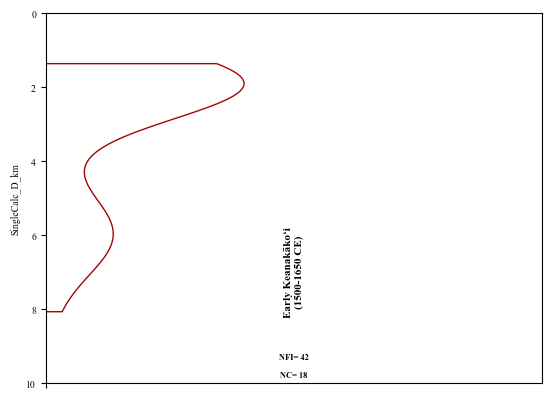

In [122]:
Lerner=pd.read_excel(MasterFolder +slash+"Data_processing_notebooks"+slash+'Data_reprocessing_Literature'+slash+'Notebook_Compiled_data'+slash+'Lerner2025_recalculated.xlsx')
Lerner =Lerner.loc[:, ~Lerner.columns.str.contains('Unnamed')]
Lerner[['Sample_code', 'crystalFI']] = Lerner['Sample Name\n(melt inclusions and fluid inclusions)'].str.split('_', n=1, expand=True)
Lerner[['crystal_num', 'crystal_suffix']] = Lerner['crystalFI'].str.extract(r'^(\d+)([A-Za-z]+)?$')
Lerner['Sample_crystal']=Lerner['Sample_code']+"_"+Lerner['crystal_num']
Lerner['Eruption_title']="Early Keanakākoʻi\n(1500-1650 CE)"
Lerner['Eruption_location_type(ERZ,VSWRZ,SSWRZ,Summit)']="Explosive Era"
Lerner['FI_name']=Lerner['Sample Name\n(melt inclusions and fluid inclusions)']
Lerner['FI_type']='P'


sns.violinplot(y=Lerner['SingleCalc_D_km'].dropna().astype(float),
               inner=None,fill=False,orient='v',cut=0,linewidth=1,color="#A10606")

plt.annotate("Early Keanakākoʻi\n(1500-1650 CE)", xy=(0.5, 0.3), xycoords='axes fraction', fontsize=8,
            ha='center', va='center', color='k', fontweight='bold', rotation=90)
plt.annotate(f'NFI= {len(Lerner)}', xy=(0.5, 0.07), xycoords='axes fraction', fontsize=8-2,
            ha='center', va='center', color='k', fontweight='bold')
plt.annotate(f'NC= {len(Lerner['Sample_crystal'].unique())}', xy=(0.5, 0.02), xycoords='axes fraction', fontsize=8-2,
        ha='center', va='center', color='k', fontweight='bold')

plt.ylim([10,0])
plt.xlim([0,1])
Lerner.head()

#### If someone else wants this data, this extracts the essentials for plotting

In [123]:
# sub_newdata=newdata[['Sample','FI_name',
#                   'SingleCalc_D_km', 'std_dev_MC_D_km',
#                  'SingleCalc_P_kbar', 'std_dev_MC_P_kbar',
#                 ]]

# sub_LERZ=LERZ2018[['Eruption', 'Fluid inclusion ID',
#                   'SingleCalc_D_km', 'std_dev_MC_D_km',
#                  'SingleCalc_P_kbar', 'std_dev_MC_P_kbar',
#                 ]]

# sub_LERZ=sub_LERZ.rename(columns={'Fluid inclusion ID':'FI_name','Eruption':'Sample'})


# Kil_4_Matt=pd.concat([sub_newdata,sub_LERZ],axis=0)

# Kil_4_Matt.to_clipboard(excel=True)

## 4. Plot Depth violins

### This filters by SO2 according to a specific cutoff

In [124]:
SO2_cutoff=None

newdata=newdata[~(newdata['SO2 mol%']>SO2_cutoff)]
# plottingdata=newdata[~(newdata['SO2 mol%']>SO2_cutoff)].copy()

LERZ2018=LERZ2018[~(LERZ2018['SO2 mol%']>SO2_cutoff)]

# This just creates sample filters for plotting
UW=newdata[(newdata['Sample'].str.contains('UW'))]
K21=newdata[(newdata['Sample'].str.contains('K21|921'))]
L84=newdata[(newdata['Sample'].str.contains('L84'))]
Ulu_919=newdata[newdata['Sample'].str.contains('919|920')]
K20=newdata[(newdata['Sample'].str.contains('K20'))]
K24=newdata[(newdata['Sample'].str.contains('K24'))]
KD24=newdata[(newdata['Sample'].str.contains('KD24'))]
Ulu_910=newdata[newdata['Sample'].str.contains('910')]
Ulu_908=newdata[newdata['Sample'].str.contains('908')]
Ulu_909=newdata[newdata['Sample'].str.contains('909')]
Ulu_916=newdata[newdata['Sample'].str.contains('916')]
Ulu_931=newdata[newdata['Sample'].str.contains('931')]
Ulu_914=newdata[newdata['Sample'].str.contains('914')]
Ulu_916=newdata[newdata['Sample'].str.contains('916')]
Ulu_917=newdata[newdata['Sample'].str.contains('917')]
Ulu_924=newdata[newdata['Sample'].str.contains('924')]
Iki_930=newdata[newdata['Sample'].str.contains('930')]
K23=newdata[newdata['Sample'].str.contains('K23')]

In [125]:
Lerner['Fo_Ol_%']=Lerner['Fo host (olivine Mg#)']
LERZ2018['Fo_Ol_%']=LERZ2018['Corrected Fo content (molar %)_Cambridge']
newdata['Fo_Ol_%']=newdata['Fo_Ol']*100
Lerner['GOS']=np.nan
LERZ2018['GOS']=np.nan
LERZ2018['GOS']

0     NaN
1     NaN
2     NaN
3     NaN
4     NaN
       ..
97    NaN
98    NaN
99    NaN
100   NaN
101   NaN
Name: GOS, Length: 102, dtype: float64

### Now plot

#### We can create a Subframe which has all the data but only some of the columns needed in the moment

In [126]:
Lerner['SO2 mol%']=np.nan
all_data_simplified = pd.concat([newdata[['Eruption_title','Eruption_location_type(ERZ,VSWRZ,SSWRZ,Summit)','Sample','Sample_crystal','FI_name','FI_type','CO2_dens_gcm3_input','SO2 mol%','XH2O_av_iteration3_final','SingleCalc_P_kbar','std_dev_MC_P_kbar','SingleCalc_D_km','std_dev_MC_D_km','Fo_Ol_%','GOS']],
                               LERZ2018[['Eruption_title','Eruption_location_type(ERZ,VSWRZ,SSWRZ,Summit)','Sample','Sample_crystal','FI_name','FI_type','CO2_dens_gcm3_input','SO2 mol%','XH2O_av_iteration3_final','SingleCalc_P_kbar','std_dev_MC_P_kbar','SingleCalc_D_km','std_dev_MC_D_km','Fo_Ol_%','GOS']],
                               Lerner[['Eruption_title','Eruption_location_type(ERZ,VSWRZ,SSWRZ,Summit)','Sample','Sample_crystal','FI_name','FI_type','CO2_dens_gcm3_input','SO2 mol%','XH2O_av_iteration3_final','SingleCalc_P_kbar','std_dev_MC_P_kbar','SingleCalc_D_km','std_dev_MC_D_km','Fo_Ol_%','GOS']]])

## Filters for rift vs summit eruptions, doesn't include Keanakakoi from Lerner because it's a bit of an odd ball
rifts=all_data_simplified['Eruption_location_type(ERZ,VSWRZ,SSWRZ,Summit)'].str.contains("RZ")
summit=all_data_simplified['Eruption_location_type(ERZ,VSWRZ,SSWRZ,Summit)'].str.contains("Summit")

all_data_simplified[rifts]

prim=~(all_data_simplified['FI_type']=='S')
all_data_simplified[prim]

,Eruption_title,"Eruption_location_type(ERZ,VSWRZ,SSWRZ,Summit)",Sample,Sample_crystal,FI_name,FI_type,CO2_dens_gcm3_input,SO2 mol%,XH2O_av_iteration3_final,SingleCalc_P_kbar,std_dev_MC_P_kbar,SingleCalc_D_km,std_dev_MC_D_km,Fo_Ol_%,GOS
0,IC\n(Sept 2023),Summit,K23,K23_2,K23_2_FIA,P,0.004106,15.513389,0.263381,0.016355,0.004008,0.072973,0.017833,87.266314,0.112099
1,SSWRZ\n(Dec 1974),SSWRZ,KL0920,KL0920_c216,KL0920_c216_a2_FID,P,0.006448,25.628255,0.257385,0.023846,0.079855,0.106306,0.353930,80.865821,0.364898
2,SSWRZ\n(June 2024),SSWRZ,K24,K24_5,K24_5_FIA,P,0.008291,8.352407,0.250687,0.032393,0.021015,0.144272,0.093193,86.965132,0.096661
3,Circ. flow\n(~1700),Summit,KL0921,KL0921_c288,KL0921_c288_a1_FIA,PS,0.009482,33.954900,0.248156,0.035677,0.061168,0.158844,0.271101,84.120395,0.803403
5,Kulanaokuaiki \n(400-650),Summit,UW5,UW5_OX25,UW5_OX25_FI#1,P,0.009730,0.000000,0.246964,0.037233,0.049395,0.165741,0.218701,85.715960,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37,Early Keanakākoʻi\n(1500-1650 CE),Explosive Era,"L25_Keana_D, upper",K99-5_11,K99-5_11b,P,0.151376,NaN,0.061224,0.539922,0.036124,2.278225,0.143955,88.892319,NaN
38,Early Keanakākoʻi\n(1500-1650 CE),Explosive Era,"L25_Keana_D, upper",K99-5_11,K99-5_11c,P,0.124454,NaN,0.074308,0.440448,0.041154,1.877495,0.167297,88.892319,NaN
39,Early Keanakākoʻi\n(1500-1650 CE),Explosive Era,"L25_Keana_D, upper",K99-5_11,K99-5_11e,P,0.132450,NaN,0.069709,0.469429,0.029397,1.995065,0.118793,88.892319,NaN
40,Early Keanakākoʻi\n(1500-1650 CE),Explosive Era,"L25_Keana_D, upper",K99-5_11,K99-5_11f,P,0.109361,NaN,0.084842,0.386834,0.026165,1.658169,0.107535,88.892319,NaN


#### KS stat bootstraping on FI distributions (pre-post 2018)

In [127]:
###### KS Bootstrapping of FI distributions
post2018_summit_data_sorted = (all_data_simplified[(summit) & (prim) & (all_data_simplified['Sample'].str.contains('K20|K23|KD24'))]
    .dropna(subset=['SingleCalc_D_km'])
    .assign(**{'SingleCalc_D_km': lambda df: df['SingleCalc_D_km'].astype(float)})
    .sort_values(by='SingleCalc_D_km', ascending=True)
)
pre2018_summit_data_sorted = (all_data_simplified[(summit) & (prim) & (~all_data_simplified['Sample'].str.contains('K20|K23|KD24'))]
    .dropna(subset=['SingleCalc_D_km'])
    .assign(**{'SingleCalc_D_km': lambda df: df['SingleCalc_D_km'].astype(float)})
    .sort_values(by='SingleCalc_D_km', ascending=True)
)
post2018_rifts_data_sorted = (all_data_simplified[(rifts) & (prim) & (all_data_simplified['Sample'].str.contains('K24|LL'))]
    .dropna(subset=['SingleCalc_D_km'])
    .assign(**{'SingleCalc_D_km': lambda df: df['SingleCalc_D_km'].astype(float)})
    .sort_values(by='SingleCalc_D_km', ascending=True)
)
pre2018_rifts_data_sorted = (all_data_simplified[(rifts) & (prim) & (~all_data_simplified['Sample'].str.contains('K24|LL'))]
    .dropna(subset=['SingleCalc_D_km'])
    .assign(**{'SingleCalc_D_km': lambda df: df['SingleCalc_D_km'].astype(float)})
    .sort_values(by='SingleCalc_D_km', ascending=True)
)
rifts_data_sorted = (all_data_simplified[(rifts) & (prim)]
    .dropna(subset=['SingleCalc_D_km'])
    .assign(**{'SingleCalc_D_km': lambda df: df['SingleCalc_D_km'].astype(float)})
    .sort_values(by='SingleCalc_D_km', ascending=True)
)
summit_data_sorted = (all_data_simplified[(summit) & (prim)]
    .dropna(subset=['SingleCalc_D_km'])
    .assign(**{'SingleCalc_D_km': lambda df: df['SingleCalc_D_km'].astype(float)})
    .sort_values(by='SingleCalc_D_km', ascending=True)
)
FI_data_sorted = (all_data_simplified[prim]
    .dropna(subset=['SingleCalc_D_km'])
    .assign(**{'SingleCalc_D_km': lambda df: df['SingleCalc_D_km'].astype(float)})
    .sort_values(by='SingleCalc_D_km', ascending=True)
)

post2018_allFI_data_sorted = (all_data_simplified[(prim) & (all_data_simplified['Sample'].str.contains('K24|LL|K20|K23|KD24'))]
    .dropna(subset=['SingleCalc_D_km'])
    .assign(**{'SingleCalc_D_km': lambda df: df['SingleCalc_D_km'].astype(float)})
    .sort_values(by='SingleCalc_D_km', ascending=True)
)
pre2018_allFI_data_sorted = (all_data_simplified[(prim) & (~all_data_simplified['Sample'].str.contains('K24|LL|K20|K23|KD24'))]
    .dropna(subset=['SingleCalc_D_km'])
    .assign(**{'SingleCalc_D_km': lambda df: df['SingleCalc_D_km'].astype(float)})
    .sort_values(by='SingleCalc_D_km', ascending=True)
)

all_geophysics_sorted = (geophysics
    .dropna(subset=['Depth (km)'])
    .assign(**{'Depth (km)': lambda df: df['Depth (km)'].astype(float)})
    .sort_values(by='Depth (km)', ascending=True)
)
deformation=geophysics['Main Geophysical method (Deformation, Seismic, Gravity, Electromagnetic)'].str.contains('Deformation',na=False)
hm=geophysics['Region (SC, HM, K, ERZ, SWRZ) '].str.contains('HM',na=False)
sc=geophysics['Region (SC, HM, K, ERZ, SWRZ) '].str.contains('SC',na=False)

deformation_all_sorted = (geophysics[deformation]
    .dropna(subset=['Depth (km)'])
    .assign(**{'Depth (km)': lambda df: df['Depth (km)'].astype(float)})
    .sort_values(by='Depth (km)', ascending=True)
)
hm_geophysics_sorted = (geophysics[hm]
    .dropna(subset=['Depth (km)'])
    .assign(**{'Depth (km)': lambda df: df['Depth (km)'].astype(float)})
    .sort_values(by='Depth (km)', ascending=True)
)
sc_geophysics_sorted = (geophysics[sc]
    .dropna(subset=['Depth (km)'])
    .assign(**{'Depth (km)': lambda df: df['Depth (km)'].astype(float)})
    .sort_values(by='Depth (km)', ascending=True)
)
schm_geophysics_sorted = (geophysics[sc|hm]
    .dropna(subset=['Depth (km)'])
    .assign(**{'Depth (km)': lambda df: df['Depth (km)'].astype(float)})
    .sort_values(by='Depth (km)', ascending=True)
)
deformation_hm_sorted = (geophysics[deformation&hm]
    .dropna(subset=['Depth (km)'])
    .assign(**{'Depth (km)': lambda df: df['Depth (km)'].astype(float)})
    .sort_values(by='Depth (km)', ascending=True)
)
deformation_sc_sorted = (geophysics[deformation&sc]
    .dropna(subset=['Depth (km)'])
    .assign(**{'Depth (km)': lambda df: df['Depth (km)'].astype(float)})
    .sort_values(by='Depth (km)', ascending=True)
)


In [128]:
iterations=1000
alpha=0.05

summit_prevspost2018_ks= calculate_bootstrap_ks(data1=pre2018_summit_data_sorted['SingleCalc_D_km'], data2=post2018_summit_data_sorted['SingleCalc_D_km'],
                                     data1_err=pre2018_summit_data_sorted['std_dev_MC_D_km'], data2_err=post2018_summit_data_sorted['std_dev_MC_D_km'],
                                     alpha=alpha, iterations=iterations,plot=False,plot_method='step',xlabel="Depth (km)",
                                     data1_label='Pre-2018 Summit FI',data2_label='Post-2018 Summit FI')
rifts_prevspost2018_ks= calculate_bootstrap_ks(data1=pre2018_rifts_data_sorted['SingleCalc_D_km'], data2=post2018_rifts_data_sorted['SingleCalc_D_km'],
                                     data1_err=pre2018_rifts_data_sorted['std_dev_MC_D_km'], data2_err=post2018_rifts_data_sorted['std_dev_MC_D_km'],
                                     alpha=alpha, iterations=iterations,plot=False,plot_method='step',xlabel="Depth (km)",
                                     data1_label='Pre-2018 Rift FI',data2_label='Post-2018 Rift FI')
summitrift_all_ks= calculate_bootstrap_ks(data1=rifts_data_sorted['SingleCalc_D_km'], data2=summit_data_sorted['SingleCalc_D_km'],
                                     data1_err=rifts_data_sorted['std_dev_MC_D_km'], data2_err=summit_data_sorted['std_dev_MC_D_km'],
                                     alpha=alpha, iterations=iterations,plot=False,plot_method='step',xlabel="Depth (km)",
                                     data1_label='Rifts FI',data2_label='Summit FI')
all_prevspost2018_ks= calculate_bootstrap_ks(data1=pre2018_allFI_data_sorted['SingleCalc_D_km'], data2=post2018_allFI_data_sorted['SingleCalc_D_km'],
                                     data1_err=pre2018_allFI_data_sorted['std_dev_MC_D_km'], data2_err=post2018_allFI_data_sorted['std_dev_MC_D_km'],
                                     alpha=alpha, iterations=iterations,plot=False,plot_method='step',xlabel="Depth (km)",
                                     data1_label='Pre-2018 FI',data2_label='Post-2018 FI')

## Plots Fig 2, panel KS stats

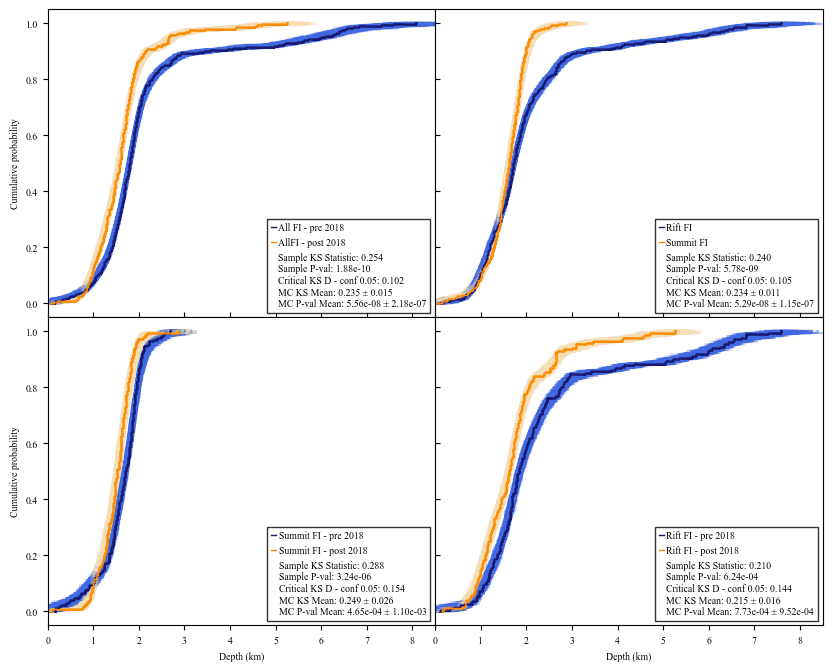

In [129]:
def plot_cdf_ks(ax,res,data1_label,data2_label,plot_method='step',lgd_fontsize=7):
        for i, distribution in enumerate(res['resampled_distributions']):
                if plot_method!='plot':
                        ax.step(np.concatenate([distribution['data1_resample'],distribution['data1_resample'][-1:]]),
                                np.arange(distribution['data1_resample'].size + 1) / distribution['data1_resample'].size, 
                                color='royalblue',alpha=0.2)
                        ax.step(np.concatenate([distribution['data2_resample'],distribution['data2_resample'][-1:]]),
                                np.arange(distribution['data2_resample'].size + 1) / distribution['data2_resample'].size,
                                color='wheat',alpha=0.2)
                else:
                        ax.plot(np.sort(distribution['data1_resample']), 
                                np.arange(1, len(distribution['data1_resample']) + 1) / len(distribution['data1_resample']), 
                                color='royalblue', alpha=0.2)
                        ax.plot(np.sort(distribution['data2_resample']), 
                                np.arange(1, len(distribution['data2_resample']) + 1) / len(distribution['data2_resample']), 
                                color='wheat', alpha=0.2)

                # This plots the original data CDF
                if plot_method!='plot':
                        ax.step(np.concatenate([res['data1_resample_sorted'],res['data1_resample_sorted'][-1:]]),
                                np.arange(res['data1_resample_sorted'].size + 1) / res['data1_resample_sorted'].size, 
                                color='midnightblue', linewidth=1,label=data1_label)
                        ax.step(np.concatenate([res['data2_resample_sorted'],res['data2_resample_sorted'][-1:]]),
                                np.arange(res['data2_resample_sorted'].size + 1) / res['data2_resample_sorted'].size, 
                                color='darkorange', linewidth=1,label=data2_label)
                else:
                        ax.plot(res['data1_resample_sorted'], 
                                np.arange(1, len(res['data1_resample_sorted']) + 1) / len(res['data1_resample_sorted']), 
                                color='midnightblue',linewidth=1, label=data1_label)
                        ax.plot(res['data2_resample_sorted'], 
                                np.arange(1, len(res['data2_resample_sorted']) + 1) / len(res['data2_resample_sorted']), 
                                color='darkorange',linewidth=1, label=data2_label)

                handles, labels = ax.get_legend_handles_labels()
                unique = dict(zip(labels, handles))

                stats_text = f"Sample KS Statistic: {res['original_ks_stat']:.3f}\n" \
                        f"Sample P-val: {res['original_p_value']:.2e}\n" \
                        f"Critical KS D - conf {alpha}: {res['critical D-val']:.3f}\n" \
                        f"MC KS Mean: {res['bootstrap_ks_mean']:.3f} ± {res['bootstrap_ks_std']:.3f}\n" \
                        f"MC P-val Mean: {res['bootstrap_p_mean']:.2e} ± {res['bootstrap_p_std']:.2e}"

                dummy_handle = mpl.lines.Line2D([], [], color='none')
                handles = list(unique.values()) + [dummy_handle]
                labels = list(unique.keys()) + [stats_text]

                ax.legend(handles, labels, loc='lower right', handletextpad=0.25,handlelength=0.5,fancybox=False,edgecolor='k',
                          fontsize=lgd_fontsize)

                ax.set_xlim([0,max(res['data1_resample_sorted'].max(), res['data2_resample_sorted'].max())])
                ax.set_xlabel("Depth (km)")
                ax.set_ylabel("Cumulative probability")

iterations=1000
alpha=0.05

iterations=1000
alpha=0.05

summit_prevspost2018_ks= calculate_bootstrap_ks(data1=pre2018_summit_data_sorted['SingleCalc_D_km'], data2=post2018_summit_data_sorted['SingleCalc_D_km'],
                                     data1_err=pre2018_summit_data_sorted['std_dev_MC_D_km'], data2_err=post2018_summit_data_sorted['std_dev_MC_D_km'],
                                     alpha=alpha, iterations=iterations,plot=False,plot_method='step',xlabel="Depth (km)",
                                     data1_label='Pre-2018 Summit FI',data2_label='Post-2018 Summit FI')
rifts_prevspost2018_ks= calculate_bootstrap_ks(data1=pre2018_rifts_data_sorted['SingleCalc_D_km'], data2=post2018_rifts_data_sorted['SingleCalc_D_km'],
                                     data1_err=pre2018_rifts_data_sorted['std_dev_MC_D_km'], data2_err=post2018_rifts_data_sorted['std_dev_MC_D_km'],
                                     alpha=alpha, iterations=iterations,plot=False,plot_method='step',xlabel="Depth (km)",
                                     data1_label='Pre-2018 Rift FI',data2_label='Post-2018 Rift FI')
summitrift_all_ks= calculate_bootstrap_ks(data1=rifts_data_sorted['SingleCalc_D_km'], data2=summit_data_sorted['SingleCalc_D_km'],
                                     data1_err=rifts_data_sorted['std_dev_MC_D_km'], data2_err=summit_data_sorted['std_dev_MC_D_km'],
                                     alpha=alpha, iterations=iterations,plot=False,plot_method='step',xlabel="Depth (km)",
                                     data1_label='Rifts FI',data2_label='Summit FI')
all_prevspost2018_ks= calculate_bootstrap_ks(data1=pre2018_allFI_data_sorted['SingleCalc_D_km'], data2=post2018_allFI_data_sorted['SingleCalc_D_km'],
                                     data1_err=pre2018_allFI_data_sorted['std_dev_MC_D_km'], data2_err=post2018_allFI_data_sorted['std_dev_MC_D_km'],
                                     alpha=alpha, iterations=iterations,plot=False,plot_method='step',xlabel="Depth (km)",
                                     data1_label='Pre-2018 FI',data2_label='Post-2018 FI')

## Plots
fig,ax=plt.subplots(2,2, figsize=(10, 8),sharey=True, sharex=True,gridspec_kw={'wspace': 0,'hspace':0})
plot_cdf_ks(ax=ax[0,1],res=summitrift_all_ks,data1_label="Rift FI",data2_label="Summit FI",lgd_fontsize=7)
plot_cdf_ks(ax=ax[1,0],res=summit_prevspost2018_ks,data1_label="Summit FI - pre 2018",data2_label="Summit FI - post 2018",lgd_fontsize=7)
plot_cdf_ks(ax=ax[1,1],res=rifts_prevspost2018_ks,data1_label="Rift FI - pre 2018",data2_label="Rift FI - post 2018",lgd_fontsize=7)
plot_cdf_ks(ax=ax[0,0],res=all_prevspost2018_ks,data1_label="All FI - pre 2018",data2_label="AllFI - post 2018",lgd_fontsize=7)

ax[0,1].set_ylabel(None)
ax[0,1].tick_params(axis='y', which='both', labelleft=False, left=True, direction='in')
ax[1,1].set_ylabel(None)
ax[1,1].tick_params(axis='y', which='both', labelleft=False, left=True, direction='in')

ax[0,0].set_xlabel(None)
ax[0,0].tick_params(axis='x', which='both', labelleft=False, left=True, direction='in')
ax[0,1].set_xlabel(None)
ax[0,1].tick_params(axis='x', which='both', labelleft=False, left=True, direction='in')
for _,a in enumerate(ax.flatten()):
        a.set_xlim(0,8.5)
fig.savefig(figpath + slash + 'KS_plots.pdf', dpi=300)

### Other possibility for the the fig panel

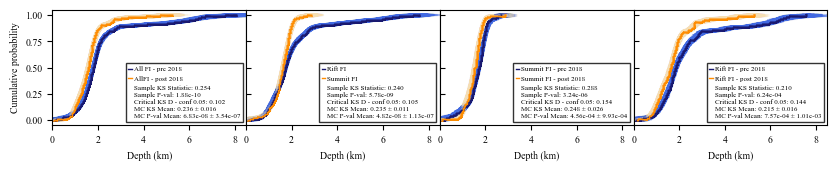

In [130]:
iterations=1000
alpha=0.05
lgd_fontsize=5

summit_prevspost2018_ks= calculate_bootstrap_ks(data1=pre2018_summit_data_sorted['SingleCalc_D_km'], data2=post2018_summit_data_sorted['SingleCalc_D_km'],
                                     data1_err=pre2018_summit_data_sorted['std_dev_MC_D_km'], data2_err=post2018_summit_data_sorted['std_dev_MC_D_km'],
                                     alpha=alpha, iterations=iterations,plot=False,plot_method='step',xlabel="Depth (km)",
                                     data1_label='Pre-2018 Summit FI',data2_label='Post-2018 Summit FI')
rifts_prevspost2018_ks= calculate_bootstrap_ks(data1=pre2018_rifts_data_sorted['SingleCalc_D_km'], data2=post2018_rifts_data_sorted['SingleCalc_D_km'],
                                     data1_err=pre2018_rifts_data_sorted['std_dev_MC_D_km'], data2_err=post2018_rifts_data_sorted['std_dev_MC_D_km'],
                                     alpha=alpha, iterations=iterations,plot=False,plot_method='step',xlabel="Depth (km)",
                                     data1_label='Pre-2018 Rift FI',data2_label='Post-2018 Rift FI')
summitrift_all_ks= calculate_bootstrap_ks(data1=rifts_data_sorted['SingleCalc_D_km'], data2=summit_data_sorted['SingleCalc_D_km'],
                                     data1_err=rifts_data_sorted['std_dev_MC_D_km'], data2_err=summit_data_sorted['std_dev_MC_D_km'],
                                     alpha=alpha, iterations=iterations,plot=False,plot_method='step',xlabel="Depth (km)",
                                     data1_label='Rifts FI',data2_label='Summit FI')
all_prevspost2018_ks= calculate_bootstrap_ks(data1=pre2018_allFI_data_sorted['SingleCalc_D_km'], data2=post2018_allFI_data_sorted['SingleCalc_D_km'],
                                     data1_err=pre2018_allFI_data_sorted['std_dev_MC_D_km'], data2_err=post2018_allFI_data_sorted['std_dev_MC_D_km'],
                                     alpha=alpha, iterations=iterations,plot=False,plot_method='step',xlabel="Depth (km)",
                                     data1_label='Pre-2018 FI',data2_label='Post-2018 FI')

fig,ax=plt.subplots(1,4, figsize=(10, 1.5),sharey=True, sharex=False,gridspec_kw={'wspace': 0,'hspace':0})
plot_cdf_ks(ax=ax[0],res=all_prevspost2018_ks,data1_label="All FI - pre 2018",data2_label="AllFI - post 2018",lgd_fontsize=lgd_fontsize)
plot_cdf_ks(ax=ax[1],res=summitrift_all_ks,data1_label="Rift FI",data2_label="Summit FI",lgd_fontsize=lgd_fontsize)
plot_cdf_ks(ax=ax[2],res=summit_prevspost2018_ks,data1_label="Summit FI - pre 2018",data2_label="Summit FI - post 2018",lgd_fontsize=lgd_fontsize)
plot_cdf_ks(ax=ax[3],res=rifts_prevspost2018_ks,data1_label="Rift FI - pre 2018",data2_label="Rift FI - post 2018",lgd_fontsize=lgd_fontsize)


ax[1].set_ylabel(None)
ax[1].tick_params(axis='y', which='both', labelleft=False, left=True, direction='in')
ax[2].set_ylabel(None)
ax[2].tick_params(axis='y', which='both', labelleft=False, left=True, direction='in')
ax[3].set_ylabel(None)
ax[3].tick_params(axis='y', which='both', labelleft=False, left=True, direction='in')

for _,a in enumerate(ax.flatten()):
        a.set_xlim(0,8.5)
fig.savefig(figpath + slash + 'KS_plots_line.pdf', dpi=300, transparent=True)

### Find modes in the datasets

In [131]:
K20_sorted = (all_data_simplified[(all_data_simplified['Sample'].str.contains('K20'))&(prim)]
    .dropna(subset=['SingleCalc_D_km'])
    .assign(**{'SingleCalc_D_km': lambda df: df['SingleCalc_D_km'].astype(float)})
    .sort_values(by='SingleCalc_D_km', ascending=True)
)
K23_sorted = (all_data_simplified[(all_data_simplified['Sample'].str.contains('K23'))&(prim)]
    .dropna(subset=['SingleCalc_D_km'])
    .assign(**{'SingleCalc_D_km': lambda df: df['SingleCalc_D_km'].astype(float)})
    .sort_values(by='SingleCalc_D_km', ascending=True)
)

In [132]:
datasets = {
    "K20":K20_sorted['SingleCalc_D_km'],
    "K23":K23_sorted['SingleCalc_D_km'],
    "pre2018_summitFI": pre2018_summit_data_sorted['SingleCalc_D_km'],
    "post2018_summitFI": post2018_summit_data_sorted['SingleCalc_D_km'],
    "pre2018_riftFI": pre2018_rifts_data_sorted['SingleCalc_D_km'],
    "post2018_riftFI": post2018_rifts_data_sorted['SingleCalc_D_km'],
    "All rift FI": rifts_data_sorted['SingleCalc_D_km'],
    "All summit FI": summit_data_sorted['SingleCalc_D_km'],
    "All FI": FI_data_sorted['SingleCalc_D_km'],
    "All geophysics":all_geophysics_sorted['Depth (km)'],
    "HM geophysics":hm_geophysics_sorted['Depth (km)'],
    "SC geophysics":sc_geophysics_sorted['Depth (km)'],
    "Deformation HMM":deformation_hm_sorted['Depth (km)'],
    "Deformation SC":deformation_sc_sorted['Depth (km)'],
    "SC & HMM geophysics":schm_geophysics_sorted['Depth (km)'],

}

modes_dict = {}


for name, data in datasets.items():
    kde = stats.gaussian_kde(data)
    x_grid = np.linspace(min(data), max(data), 1000)
    density = kde(x_grid)
    peaks, _ = signal.find_peaks(density)
    modes = x_grid[peaks]
    modes_dict[name] = modes

modes_dict


{'K20': array([1.16862505, 1.69204643]),
 'K23': array([1.63605477]),
 'pre2018_summitFI': array([1.81839077]),
 'post2018_summitFI': array([1.60529644]),
 'pre2018_riftFI': array([1.72968697, 6.2257801 ]),
 'post2018_riftFI': array([1.60909366, 4.50800703]),
 'All rift FI': array([1.62495269, 6.27066622]),
 'All summit FI': array([0.29946568, 1.70036764]),
 'All FI': array([1.66625928, 4.10823142, 5.41328538, 6.3500419 ]),
 'All geophysics': array([1.56406406, 2.61591592, 7.17157157]),
 'HM geophysics': array([1.16056056]),
 'SC geophysics': array([2.98378378]),
 'Deformation HMM': array([1.62432432]),
 'Deformation SC': array([3.1009009]),
 'SC & HMM geophysics': array([1.45225225, 2.64804805])}

### Plot the Geophysics compilation with the FI distributions

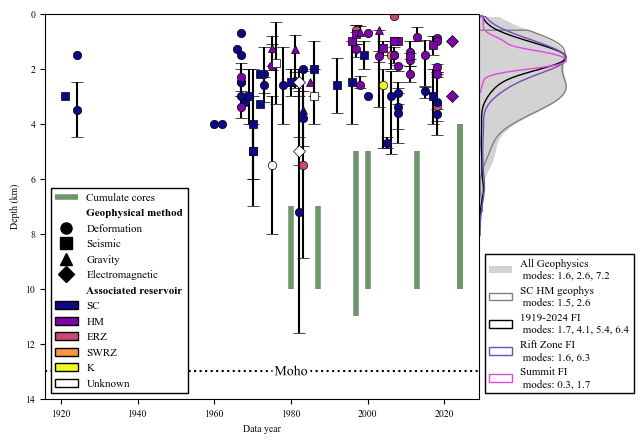

In [133]:
methods = ['Deformation', 'Seismic', 'Gravity','Electromagnetic']
markers = ['o', 's', '^', 'D', 'd','*'] 

color_by_col = 'Region (SC, HM, K, ERZ, SWRZ) '
chosen_cmap='plasma'
unique_vals = geophysics[color_by_col].dropna().astype(str).unique()
colors_map = {val: mpl.colormaps[chosen_cmap](s) for val, s in zip(unique_vals, np.linspace(0, 1, len(unique_vals)))}

fig = plt.figure(figsize=(7, 5))
gs = fig.add_gridspec(1, 2, width_ratios=[4, 1], wspace=0)

ax = fig.add_subplot(gs[0])
ax_hist = fig.add_subplot(gs[1], sharey=ax)

ax.set_zorder(1)
ax_hist.set_zorder(0)
ax.patch.set_alpha(0)

ax_hist.spines['top'].set_visible(False)
ax_hist.spines['right'].set_visible(False)
ax_hist.spines['bottom'].set_visible(False)
ax_hist.spines['left'].set_visible(False)
ax_hist.tick_params(left=False, labelleft=False, labelbottom=False,bottom=False)


ax.vlines(x=geophysics['Publication year'],
          ymin=geophysics['Cumulate upper depth (km)'].astype('float64'),
          ymax=geophysics['Cumulate lower depth (km)'].astype('float64'),
          colors="#6F956D", linestyles='-', label='Cumulate cores', linewidths=4)

for method, marker in zip(methods, markers):
    mask = geophysics['Main Geophysical method (Deformation, Seismic, Gravity, Electromagnetic)'].str.contains(method, na=False)
    subset = geophysics[mask]

    for _, row in subset.iterrows():
        x = float(row['Data year'])
        y = float(row['Depth (km)'])
        yerr = [[float(row['Depth uncertainty left (-km)'])], [float(row['Depth uncertainty right (+km)'])]]

        color_key = str(row[color_by_col])
        chosen_color = colors_map.get(color_key, 'white')

        ax.errorbar(x, y, yerr=yerr, fmt=marker, color=chosen_color,
                    ecolor='black', capsize=4, mec='k', markeredgewidth=0.5)

moho_line = ax.axhline(y=13, color='black', linestyle=':', linewidth=1.5, label='Moho')
labelLines([moho_line], xvals=[1980],align=True, fontsize=10, color='k',outline_color='white', outline_width=5, zorder=10)


ax.set_xlabel('Data year')
ax.set_ylabel('Depth (km)')
ax.set_ylim([14, 0])
deformation=geophysics['Main Geophysical method (Deformation, Seismic, Gravity, Electromagnetic)'].str.contains('Deformation',na=False)
em=geophysics['Main Geophysical method (Deformation, Seismic, Gravity, Electromagnetic)'].str.contains('Electromagnetic',na=False)
hm=geophysics['Region (SC, HM, K, ERZ, SWRZ) '].str.contains('HM',na=False)
sc=geophysics['Region (SC, HM, K, ERZ, SWRZ) '].str.contains('SC',na=False)
pre18_gp=~(geophysics['Data year'].astype(float)>2017)
post18_gp=geophysics['Data year'].astype(float)>2017


# sns.violinplot(y=geophysics[deformation]['Depth (km)'].dropna().astype(float),
#     ax=ax_hist,inner=None,fill=False,color='gray',orient='v',cut=0,linewidth=2,label="Deformation only")
# sns.violinplot(y=geophysics[deformation&hm]['Depth (km)'].dropna().astype(float),
#     ax=ax_hist,inner=None,fill=False,color='gray',orient='v',cut=0,linewidth=1,label="HM_deformation")
# sns.violinplot(y=geophysics[deformation&sc]['Depth (km)'].dropna().astype(float),
#     ax=ax_hist,inner=None,fill=False,color='gray',orient='v',cut=0,linewidth=1,label="SC_deformation")

# sns.violinplot(y=all_data_simplified[rifts]['SingleCalc_D_km'].dropna().astype(float),
#     ax=ax_hist,inner=None,fill=False,orient='v',cut=0,linewidth=1,color="#000000", label="Rift Zone FI")

# sns.violinplot(y=geophysics[pre18_gp]['Depth (km)'].dropna().astype(float),
#     ax=ax_hist,inner=None,color='lightgray',orient='v',cut=0,linewidth=0,label="Pre 2018 Geophysics")
# sns.violinplot(y=geophysics[post18_gp]['Depth (km)'].dropna().astype(float),
#     ax=ax_hist,inner=None,color='gray',orient='v',cut=0,linewidth=0,label="Post 2018 Geophysics")

sns.violinplot(y=geophysics['Depth (km)'].dropna().astype(float),
    ax=ax_hist,inner=None,color='lightgray',orient='v',cut=0,linewidth=0,
        label=("All Geophysics \n modes: " + ", ".join(f"{float(v):.1f}" for v in np.atleast_1d(modes_dict["All geophysics"])))
)
# sns.violinplot(y=geophysics[hm]['Depth (km)'].dropna().astype(float),
#     ax=ax_hist,inner=None,fill=False,color='grey',orient='v',cut=0,linewidth=1,
#         label=("HMM geophysics \n modes: " + ", ".join(f"{float(v):.1f}" for v in np.atleast_1d(modes_dict["HM geophysics"])))
# )
# sns.violinplot(y=geophysics[sc]['Depth (km)'].dropna().astype(float),
#     ax=ax_hist,inner=None,fill=False,color='grey',orient='v',cut=0,linewidth=1,
#         label=("SC geophysics \n modes: " + ", ".join(f"{float(v):.1f}" for v in np.atleast_1d(modes_dict["SC geophysics"])))
# )
sns.violinplot(y=geophysics[sc|hm]['Depth (km)'].dropna().astype(float),
    ax=ax_hist,inner=None,fill=False,color='grey',orient='v',cut=0,linewidth=1,
        label=("SC HM geophys \n modes: " + ", ".join(f"{float(v):.1f}" for v in np.atleast_1d(modes_dict["SC & HMM geophysics"])))
)
# sns.violinplot(y=all_data_simplified[rifts&(~all_data_simplified['Sample'].str.contains('LL|K24'))&(prim)]['SingleCalc_D_km'].dropna().astype(float),
#     ax=ax_hist,inner=None,fill=False,orient='v',cut=0,linewidth=1,color="#000000",    
#     label=("Pre-2018 Rift Zone FI \n modes: " + ", ".join(f"{float(v):.1f}" for v in np.atleast_1d(modes_dict["pre2018_riftFI"])))
# )
# sns.violinplot(y=all_data_simplified[rifts&(all_data_simplified['Sample'].str.contains('LL|K24'))&(prim)]['SingleCalc_D_km'].dropna().astype(float),
#     ax=ax_hist,inner=None,fill=False,orient='v',cut=0,linewidth=1,color="#12279B", 
#     label=("Post-2018 Rift Zone FI \n modes: " + ", ".join(f"{float(v):.1f}" for v in np.atleast_1d(modes_dict["post2018_riftFI"])))
# )

# sns.violinplot(y=all_data_simplified[(summit)&(all_data_simplified['Sample'].str.contains('K20|K23|KD24'))&(prim)]['SingleCalc_D_km'].dropna().astype(float),
#     ax=ax_hist,inner=None,fill=False,orient='v',cut=0,linewidth=1,color="#E69F00",
#     label=("Post-2018 Summit FI \n modes: " + ", ".join(f"{float(v):.1f}" for v in np.atleast_1d(modes_dict["post2018_summitFI"])))
# )

# sns.violinplot(y=all_data_simplified[(summit)&(~all_data_simplified['Sample'].str.contains('K20|K23|KD24'))&(prim)]['SingleCalc_D_km'].dropna().astype(float),
#     ax=ax_hist,inner=None,fill=False,orient='v',cut=0,linewidth=1,color="#A10606",
# label=("Pre-2018 Summit FI \n modes: " + ", ".join(f"{float(v):.1f}" for v in np.atleast_1d(modes_dict["pre2018_summitFI"])))
# )
sns.violinplot(y=all_data_simplified[(~all_data_simplified['Sample'].str.contains('L84|UW|K21|921'))&(prim)]['SingleCalc_D_km'].dropna().astype(float),
    ax=ax_hist,inner=None,fill=False,orient='v',cut=0,linewidth=1,color="#000000",
label=("1919-2024 FI \n modes: " + ", ".join(f"{float(v):.1f}" for v in np.atleast_1d(modes_dict["All FI"])))
)

sns.violinplot(y=all_data_simplified[rifts
&(prim)]['SingleCalc_D_km'].dropna().astype(float),
    ax=ax_hist,inner=None,fill=False,orient='v',cut=0,linewidth=1,color="#754BB7", 
    label=("Rift Zone FI \n modes: " + ", ".join(f"{float(v):.1f}" for v in np.atleast_1d(modes_dict['All rift FI'])))
)

sns.violinplot(y=all_data_simplified[(summit)&(prim)]['SingleCalc_D_km'].dropna().astype(float),
    ax=ax_hist,inner=None,fill=False,orient='v',cut=0,linewidth=1,color="#E447DF",
    label=("Summit FI \n modes: " + ", ".join(f"{float(v):.1f}" for v in np.atleast_1d(modes_dict['All summit FI'])))
)

## Plot setup and legend handling
ax_hist.set_ylim(ax.get_ylim())
xlim = ax_hist.get_xlim()
ax_hist.set_xlim(max(0, xlim[0]), xlim[1])

for spine in ax_hist.spines.values():
    spine.set_visible(False)

handles, labels = ax.get_legend_handles_labels()
handles_filtered = [h for h, l in zip(handles, labels) if l != 'Moho']
labels_filtered = [l for l in labels if l != 'Moho']
method_handles = [mpl.lines.Line2D([], [], color='black', marker=m, linestyle='None', markersize=8, label=method) for method, m in zip(methods, markers)]
region_handles = [mpl.patches.Patch(facecolor=colors_map[val], label=val,edgecolor='k') for val in unique_vals]
nan_handle = mpl.patches.Patch(facecolor='white', label='Unknown',edgecolor='k')
region_handles.append(nan_handle)

header_methods = mpl.lines.Line2D([], [], linestyle='None', label='Geophysical method')
header_regions = mpl.lines.Line2D([], [], linestyle='None', label='Associated reservoir')

all_handles = handles_filtered+[header_methods] + method_handles + [header_regions] + region_handles
all_labels  = [h.get_label() for h in all_handles]

ax.set_xlabel('Data year')
ax.set_ylabel('Depth (km)')
ax.set_ylim([14,0])
leg=ax.legend(all_handles,all_labels,loc='best',fancybox=False, edgecolor='black',ncol=1, fontsize=8,framealpha=1)
for text, handle in zip(leg.texts, all_handles):
    if handle in (header_methods, header_regions):
        text.set_fontweight('bold')
ax_hist.legend(loc='best',  fancybox=False, edgecolor='black',              
    ncol=1, fontsize=8,framealpha=1)

plt.show()
fig.savefig(figpath + slash + 'Geophysics_FI_allsummit_allrifts.pdf', dpi=300)


### Synthetic inclusion distributions

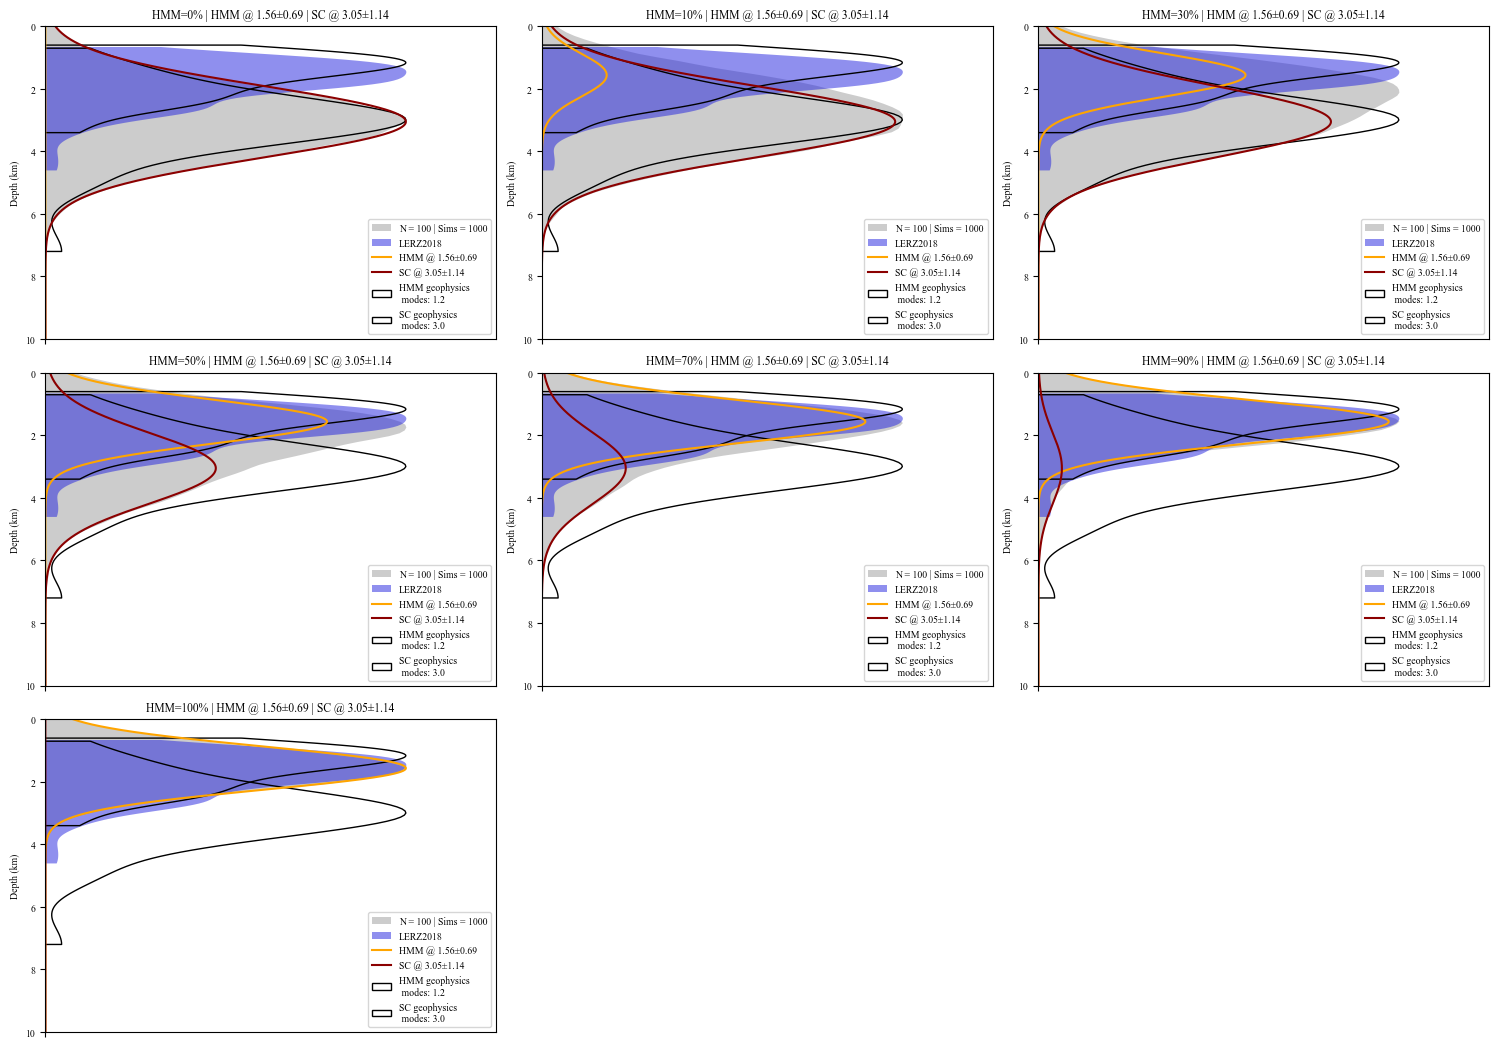

In [134]:
mu1, sigma1 = 1.56, 0.69
mu2, sigma2 = 3.05, 1.14
proportions = [0,0.1,0.3,0.5,0.7,0.9,1]
N_grid = [10, 20, 50, 100, 200, 500]
rng = np.random.default_rng(42)

ylims = (10, 0)
xs = np.linspace(min(ylims), max(ylims), 2000)

N_total = N_grid[3]
n_sims = 1000
mix_mean_var_sd=False # if you want to calculate and export mean, variance and sd for the mixed dists set to True
scale_mix_to_violin=True # if you want to scale the mixed pdfs to the violins set to true
plot_theoretical_mix=False # if you want to plot the analytical mixture of Gaussian PDFs

res = {}

for p1 in proportions:
    n1 = int(round(p1 * N_total))
    n2 = N_total - n1
    p2 = 1-p1

    f_mix_theo = (p1 * (1.0 / (sigma1 * np.sqrt(2*np.pi))) * np.exp(-0.5 * ((xs - mu1) / sigma1)**2) +
              p2 * (1.0 / (sigma2 * np.sqrt(2*np.pi))) * np.exp(-0.5 * ((xs - mu2) / sigma2)**2))

    peaks, _ = signal.find_peaks(f_mix_theo)
    theo_modes = xs[peaks]
    mix_kurtosis=stats.kurtosis(f_mix_theo,fisher=True)
    mix_skewness=stats.skew(f_mix_theo)

    pooled_list = []
    by_sim_detail=[]
    for s in range(n_sims):
        x1 = rng.normal(mu1, sigma1, size=n1)
        x2 = rng.normal(mu2, sigma2, size=n2)
        pooled = np.concatenate([x1, x2])
        pooled_list.append(pooled)
        by_sim_detail.append({"sim": s, "data": [x1,x2]})

    all_data = np.concatenate(pooled_list)
    data_by_sim = np.vstack(pooled_list)

    res[p1] = {
        "data": all_data,
        "data_by_sim": data_by_sim,
        "mu1": mu1, "sigma1": sigma1,
        "mu2": mu2, "sigma2": sigma2,
        "p1": p1, "p2": 1 - p1,
        "n1": n1, "n2": n2,
        "N_total": N_total,
        "n_sims": n_sims,
        "xs": xs,
        "f_mix_theo":f_mix_theo,
        "mix_theo_modes":theo_modes,
        "mix_kurtosis":mix_kurtosis,
        "mix_skewness":mix_skewness,
    }
    ## if we want the mean, variance and stdev of the mixture, theoretical and empirical, use this, 
    ## but honestly, it is not very meaningful since the mixture could be bimodal
    if mix_mean_var_sd==True:

        mu_mix = p1*mu1 + p2*mu2
        var_mix = p1*(sigma1**2 + mu1**2) + p2*(sigma2**2 + mu2**2) - mu_mix**2
        std_mix = np.sqrt(var_mix)
        emp_mean = float(np.mean(all_data))
        emp_std = float(np.std(all_data, ddof=1)) if all_data.size > 1 else float(np.std(all_data))

        res[p1].update({
            "emp_mean": emp_mean,
            "emp_std": emp_std,
            "theo_mean": mu_mix,
            "theo_std": std_mix,
            "theo_var": var_mix,
        })

## Now plot the res
n_cols = 3
n_rows = int(np.ceil(len(proportions)/ n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
axes = axes.flatten()  
for ax, p1 in zip(axes, proportions):
    r = res[p1]

    sns.violinplot(y=r['data'],ax=ax,bw_method='silverman',density_norm='area',
                   inner=None,fill=True,orient='v',cut=0,linewidth=0,color="#000000",alpha=0.2,
                   label=f"N = {N_total} | Sims = {n_sims}")
    sns.violinplot(data=all_data_simplified[all_data_simplified['Sample'].str.contains("LL")]['SingleCalc_D_km'], 
                   color='blue', fill=True,inner=None, ax=ax, cut=0,orient='v',linewidth=0,zorder=1,
                   alpha=0.5,label='LERZ2018')
    # this is to scale the theoretical pdfs to the violin
    if scale_mix_to_violin==True:
        polys = [c for c in ax.collections if hasattr(c, "get_paths") and c.get_paths()]
        target_half_width = max((np.max(np.abs(p.vertices[:, 0]))
                for p in (polys[0].get_paths() if polys else [])
                if p.vertices.size),default=0.2)
        scale_factor = (target_half_width / np.max(r["f_mix_theo"])) if np.max(r["f_mix_theo"]) > 0 else 1
    else:
        scale_factor=1
    if plot_theoretical_mix==True:
        ax.plot(r["f_mix_theo"] * scale_factor,r['xs'], color="black", lw=1,label='Gaussian PDF mix')
    
    hm_f=r["p1"] * (1.0 / (sigma1 * np.sqrt(2*np.pi))) * np.exp(-0.5 * ((r['xs'] - r["mu1"]) / r["sigma1"])**2)
    sc_f=r["p2"] * (1.0 / (sigma2 * np.sqrt(2*np.pi))) * np.exp(-0.5 * ((r['xs'] - r["mu2"]) / r["sigma2"])**2)
    ax.plot(hm_f*scale_factor,r['xs'],color='orange',label=f'HMM @ {r["mu1"]}±{r["sigma1"]}')
    ax.plot(sc_f*scale_factor,r['xs'],color='darkred',label=f'SC @ {r["mu2"]}±{r["sigma2"]}')
    sns.violinplot(y=geophysics[hm]['Depth (km)'].dropna().astype(float),
        ax=ax,inner=None,fill=False,color='k',orient='v',cut=0,linewidth=1,
            label=("HMM geophysics \n modes: " + ", ".join(f"{float(v):.1f}" for v in np.atleast_1d(modes_dict["HM geophysics"])))
    )
    sns.violinplot(y=geophysics[sc]['Depth (km)'].dropna().astype(float),
        ax=ax,inner=None,fill=False,color='k',orient='v',cut=0,linewidth=1,
            label=("SC geophysics \n modes: " + ", ".join(f"{float(v):.1f}" for v in np.atleast_1d(modes_dict["SC geophysics"])))
    )
    ax.set_title(f"HMM={r["p1"]*100:.0f}% | HMM @ {r["mu1"]}±{r["sigma1"]} | SC @ {r["mu2"]}±{r["sigma2"]}")
    ax.set_xlim(0)
    ax.set_ylim(max(ylims),min(ylims))
    ax.legend(loc='lower right')
    ax.set_ylabel("Depth (km)")

for ax in axes[len(proportions):]:
    ax.axis("off")

fig.tight_layout()
plt.show()

### Suppose we add a third reservoir

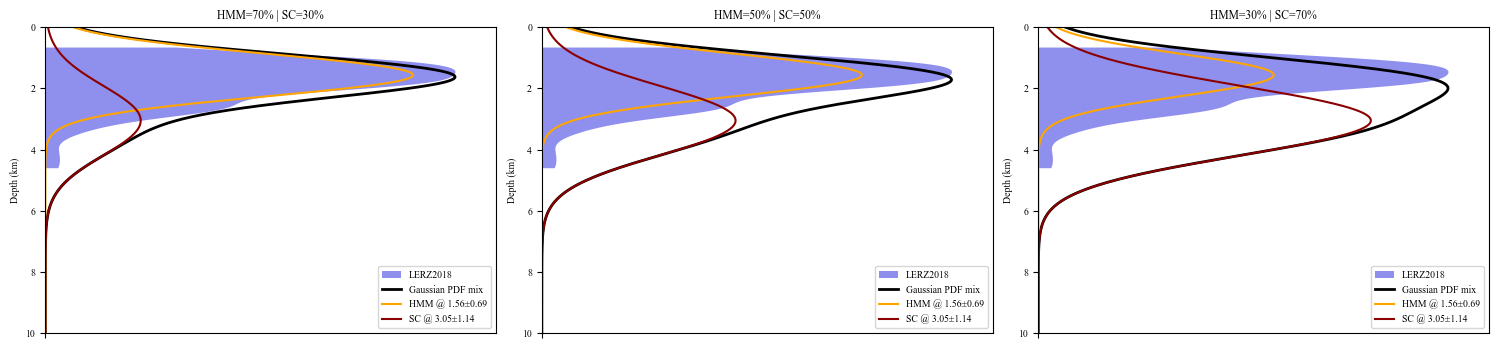

In [135]:
components = [
    {"key": "HMM", "mu": 1.56, "sigma": 0.69, "color": "orange"},
    {"key": "HMM2",  "mu": 1, "sigma": 0.5, "color": "darkblue"},
    {"key": "SC",  "mu": 3.05, "sigma":1.14, "color": "darkred"},
]
proportions = [[0.7,0,0.3],[0.5,0,0.5],[0.3,0,0.7]]
rng = np.random.default_rng(42)

N_total = 100
n_sims = 1000
mix_mean_var_sd=False
scale_mix_to_violin=True
plot_theoretical_mix=True
plot_geophysics=False
plot_simulations=False

ylims = (10, 0)
xs = np.linspace(min(ylims), max(ylims), 2000)

def gaussian_pdf(x, mu, sigma):
    return (1.0 / (sigma * np.sqrt(2*np.pi))) * np.exp(-0.5 * ((x - mu) / sigma)**2)

results_all = {}

for i, p in enumerate(proportions):
    p = np.array(p, dtype=float)
    p = p / p.sum() if p.sum()!=1 else p
    n_list = [int(round(pi * N_total)) for pi in p]

    f_mix_theo = np.zeros_like(xs)
    for pi, comp in zip(p, components):
        f_mix_theo += pi * gaussian_pdf(xs, comp["mu"], comp["sigma"])

    peaks, _ = signal.find_peaks(f_mix_theo)
    theo_modes = xs[peaks]
    mix_kurtosis=stats.kurtosis(f_mix_theo,fisher=True)
    mix_skewness=stats.skew(f_mix_theo)

    pooled_list = []
    by_sim_detail=[]
    for s in range(n_sims):
        samples = [rng.normal(comp["mu"], comp["sigma"], size=ni) for comp, ni in zip(components, n_list)]
        pooled = np.concatenate(samples) if len(samples)>1 else samples[0]
        pooled_list.append(pooled)
        by_sim_detail.append({"sim": s, "data": samples})

    all_data = np.concatenate(pooled_list)
    data_by_sim = np.vstack(pooled_list)

    res = {
        "data": all_data,
        "data_by_sim": data_by_sim,
        "components": components,
        "proportions": p,
        "component_sample_number": n_list,
        "N_total": N_total,
        "n_sims": n_sims,
        "xs": xs,
        "f_mix_theo":f_mix_theo,
        "mix_theo_modes":theo_modes,
        "mix_kurtosis":mix_kurtosis,
        "mix_skewness":mix_skewness,
    }

    if mix_mean_var_sd==True:
        mu_mix = float(np.sum(p * np.array([c["mu"] for c in components])))
        var_mix = float(np.sum(p * (np.array([c["sigma"] for c in components])**2 + np.array([c["mu"] for c in components])**2))) - mu_mix**2
        std_mix = float(np.sqrt(var_mix))
        emp_mean = float(np.mean(all_data))
        emp_std = float(np.std(all_data, ddof=1)) if all_data.size > 1 else float(np.std(all_data))
        res.update({
            "emp_mean": emp_mean,
            "emp_std": emp_std,
            "theo_mean": mu_mix,
            "theo_std": std_mix,
            "theo_var": var_mix,
        })

    results_all[i] = res

n_cols = 3
n_rows = int(np.ceil(len(proportions)/ n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
axes = axes.flatten()

for ax, i in zip(axes, range(len(proportions))):
    res = results_all[i]
    if plot_simulations==True:
        sns.violinplot(y=res['data'],ax=ax,bw_method='silverman',density_norm='area',
                    inner=None,fill=False,orient='v',cut=0,linewidth=2,color="#000000",alpha=1,
                    label=f"N = {N_total} | Sims = {n_sims}")

    sns.violinplot(data=all_data_simplified[all_data_simplified['Sample'].str.contains("LL")]['SingleCalc_D_km'], 
                    color='blue', fill=True,inner=None, ax=ax, cut=0,orient='v',linewidth=0,zorder=1,
                    alpha=0.5,label='LERZ2018')

    if scale_mix_to_violin==True:
        polys = [c for c in ax.collections if hasattr(c, "get_paths") and c.get_paths()]
        target_half_width = max((np.max(np.abs(p.vertices[:, 0]))
                for p in (polys[0].get_paths() if polys else [])
                if p.vertices.size),default=0.2)
        scale_factor = (target_half_width / np.max(res["f_mix_theo"])) if np.max(res["f_mix_theo"]) > 0 else 1
    else:
        scale_factor=1
    if plot_theoretical_mix==True:
        ax.plot(res["f_mix_theo"] * scale_factor,res['xs'], color="black", lw=2,label='Gaussian PDF mix')

    if plot_geophysics==True:
        sns.violinplot(y=geophysics[hm]['Depth (km)'].dropna().astype(float),
            ax=ax,inner=None,fill=False,color='k',linestyle=":",orient='v',cut=0,linewidth=1,
                label=("HMM geophysics \n modes: " + ", ".join(f"{float(v):.1f}" for v in np.atleast_1d(modes_dict["HM geophysics"])))
        )
        sns.violinplot(y=geophysics[sc]['Depth (km)'].dropna().astype(float),
            ax=ax,inner=None,fill=False,color='k',linestyle=":",orient='v',cut=0,linewidth=1,
                label=(("SC geophysics \n modes: " + ", ".join(f"{float(v):.1f}" for v in np.atleast_1d(modes_dict["SC geophysics"]))))
        )


    for pi, comp in zip(res["proportions"], res["components"]):
        if pi > 0:
            comp_pdf = pi * gaussian_pdf(res['xs'], comp["mu"], comp["sigma"])
            ax.plot(comp_pdf * scale_factor, res['xs'], color=comp.get("color","gray"),
                    label=f'{comp["key"]} @ {comp["mu"]:.2f}±{comp["sigma"]:.2f}')
    

    title_bits = ["{}={}%" .format(c["key"], int(round(w_i*100))) 
                for c, w_i in zip(res["components"], res["proportions"]) if w_i > 0]
    ax.set_title(" | ".join(title_bits))


    ax.set_xlim(0)
    ax.set_ylim(max(ylims),min(ylims))
    ax.legend(loc='lower right')
    ax.set_ylabel("Depth (km)")

for ax in axes[len(proportions):]:
    ax.axis("off")

fig.tight_layout()
fig.savefig(figpath + slash + 'Synthetics_gaussians_geophys.pdf', dpi=300)


### Sampling directly from the PDFs from geophysics. 

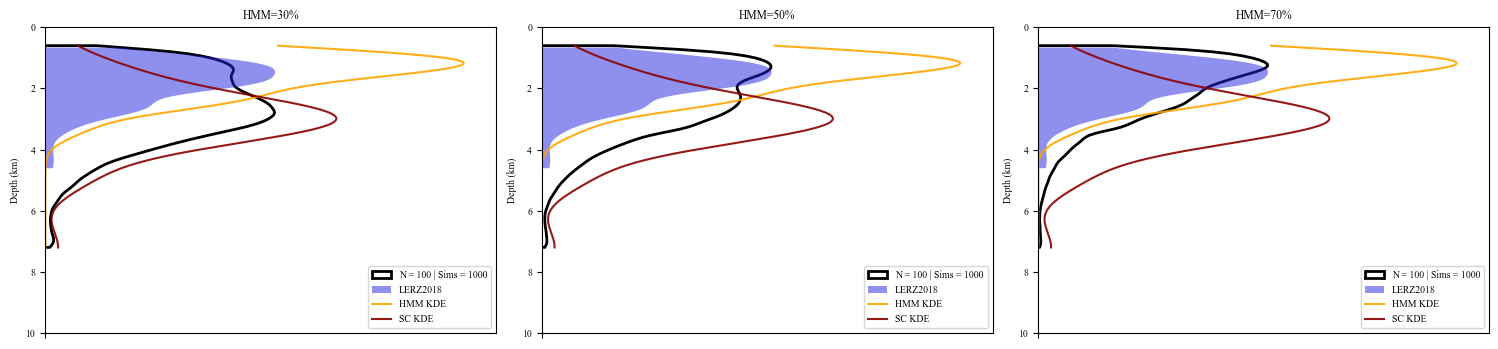

In [136]:
mu1, sigma1 = 1.56, 0.69
mu2, sigma2 = 3.05, 1.14
proportions = [0.3,0.5,0.7]
N_grid = [10, 20, 50, 100, 200, 500]
rng = np.random.default_rng(42)

ylims = (10, 0)

hmm_data=geophysics[hm]['Depth (km)'].dropna().astype(float).to_numpy()
sc_data=geophysics[sc]['Depth (km)'].dropna().astype(float).to_numpy()

kde_hmm = stats.gaussian_kde(hmm_data, bw_method='silverman')
kde_sc  = stats.gaussian_kde(sc_data,  bw_method='silverman')

low  = min(np.min(hmm_data),np.min(sc_data))
high = max(np.max(hmm_data),np.max(sc_data))

xs = np.linspace(low,high, 2000)

N_total = N_grid[3]
n_sims = 1000
mix_mean_var_sd=False # if you want to calculate and export mean, variance and sd for the mixed dists set to True
scale_mix_to_violin=True # if you want to scale the mixed pdfs to the violins set to true
plot_theoretical_mix=False # if you want to plot the analytical mixture of Gaussian PDFs

def resample_with_redraw(kde, n, lo, hi, rng):
    if n <= 0:
        return np.empty(0, dtype=float)
    samples = np.asarray(kde.resample(n, seed=rng), dtype=float).reshape(-1)
    oob_idx = np.where((samples < lo) | (samples > hi))[0]
    for idx in oob_idx:
        while True:
            new_val = float(np.asarray(kde.resample(1, seed=rng)).reshape(-1)[0])
            if lo <= new_val <= hi:
                samples[idx] = new_val
                break
    return samples.reshape(-1)

res = {}

for p1 in proportions:
    n1 = int(round(p1 * N_total))
    n2 = N_total - n1
    p2 = 1-p1

    f_mix_theo = (p1 * (1.0 / (sigma1 * np.sqrt(2*np.pi))) * np.exp(-0.5 * ((xs - mu1) / sigma1)**2) +
              p2 * (1.0 / (sigma2 * np.sqrt(2*np.pi))) * np.exp(-0.5 * ((xs - mu2) / sigma2)**2))

    peaks, _ = signal.find_peaks(f_mix_theo)
    theo_modes = xs[peaks]
    mix_kurtosis=stats.kurtosis(f_mix_theo,fisher=True)
    mix_skewness=stats.skew(f_mix_theo)

    pooled_list = []
    by_sim_detail=[]
    for s in range(n_sims):


        x1 = resample_with_redraw(kde_hmm, n1, np.min(hmm_data), np.max(hmm_data), rng) if n1 > 0 else np.array([], dtype=float)
        x2 = resample_with_redraw(kde_sc,  n2, np.min(sc_data),  np.max(sc_data),  rng) if n2 > 0 else np.array([], dtype=float)

        pooled = np.concatenate([x1, x2])
        pooled_list.append(pooled)
        by_sim_detail.append({"sim": s, "data": [x1,x2]})

    all_data = np.concatenate(pooled_list)
    data_by_sim = np.vstack(pooled_list)

    res[p1] = {
        "data": all_data,
        "data_by_sim": data_by_sim,
        "mu1": mu1, "sigma1": sigma1,
        "mu2": mu2, "sigma2": sigma2,
        "p1": p1, "p2": 1 - p1,
        "n1": n1, "n2": n2,
        "N_total": N_total,
        "n_sims": n_sims,
        "xs": xs,
        "f_mix_theo":f_mix_theo,
        "mix_theo_modes":theo_modes,
        "mix_kurtosis":mix_kurtosis,
        "mix_skewness":mix_skewness,
    }
    ## if we want the mean, variance and stdev of the mixture, theoretical and empirical, use this, 
    ## but honestly, it is not very meaningful since the mixture could be bimodal
    if mix_mean_var_sd==True:

        mu_mix = p1*mu1 + p2*mu2
        var_mix = p1*(sigma1**2 + mu1**2) + p2*(sigma2**2 + mu2**2) - mu_mix**2
        std_mix = np.sqrt(var_mix)
        emp_mean = float(np.mean(all_data))
        emp_std = float(np.std(all_data, ddof=1)) if all_data.size > 1 else float(np.std(all_data))

        res[p1].update({
            "emp_mean": emp_mean,
            "emp_std": emp_std,
            "theo_mean": mu_mix,
            "theo_std": std_mix,
            "theo_var": var_mix,
        })

## Now plot the res
n_cols = 3
n_rows = int(np.ceil(len(proportions)/ n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
axes = axes.flatten()  
for ax, p1 in zip(axes, proportions):
    r = res[p1]

    sns.violinplot(y=r['data'],ax=ax,bw_method='silverman',density_norm='area',
                   inner=None,fill=False,orient='v',cut=0,linewidth=2,color="#000000",alpha=1,
                   label=f"N = {N_total} | Sims = {n_sims}")
    sns.violinplot(data=all_data_simplified[all_data_simplified['Sample'].str.contains("LL")]['SingleCalc_D_km'], 
                   color='blue', fill=True,inner=None, ax=ax, cut=0,orient='v',linewidth=0,zorder=1,
                   alpha=0.5,label='LERZ2018')
    # # this is to scale the theoretical pdfs to the violin
    # if scale_mix_to_violin==True:
    #     polys = [c for c in ax.collections if hasattr(c, "get_paths") and c.get_paths()]
    #     target_half_width = max((np.max(np.abs(p.vertices[:, 0]))
    #             for p in (polys[0].get_paths() if polys else [])
    #             if p.vertices.size),default=0.2)
    #     scale_factor = (target_half_width / np.max(r["f_mix_theo"])) if np.max(r["f_mix_theo"]) > 0 else 1
    # else:
    #     scale_factor=1
    # if plot_theoretical_mix==True:
    #     ax.plot(r["f_mix_theo"] * scale_factor,r['xs'], color="black", lw=1,label='Gaussian PDF mix')
    
    # hm_f=r["p1"] * (1.0 / (sigma1 * np.sqrt(2*np.pi))) * np.exp(-0.5 * ((r['xs'] - r["mu1"]) / r["sigma1"])**2)
    # sc_f=r["p2"] * (1.0 / (sigma2 * np.sqrt(2*np.pi))) * np.exp(-0.5 * ((r['xs'] - r["mu2"]) / r["sigma2"])**2)
    # ax.plot(hm_f*scale_factor,r['xs'],color='orange',label=f'HMM @ {r["mu1"]}±{r["sigma1"]}')
    # ax.plot(sc_f*scale_factor,r['xs'],color='darkred',label=f'SC @ {r["mu2"]}±{r["sigma2"]}')

    # sns.violinplot(y=geophysics[hm]['Depth (km)'].dropna().astype(float),
    #     ax=ax,inner=None,fill=True,color='grey',orient='v',cut=0,linewidth=0,alpha=0.3,
    #         label=("HMM geophysics \n modes: " + ", ".join(f"{float(v):.1f}" for v in np.atleast_1d(modes_dict["HM geophysics"])))
    # )
    # sns.violinplot(y=geophysics[sc]['Depth (km)'].dropna().astype(float),
    #     ax=ax,inner=None,fill=True,color='grey',orient='v',cut=0,linewidth=0,alpha=0.3,
    #         label=("SC geophysics \n modes: " + ", ".join(f"{float(v):.1f}" for v in np.atleast_1d(modes_dict["SC geophysics"])))
    # )


    kde_hmm_vals = kde_hmm.evaluate(r['xs'])
    kde_sc_vals  = kde_sc.evaluate(r['xs'])
    ax.plot(kde_hmm_vals*scale_factor, r['xs'],
            color='orange', lw=1.5, alpha=0.9,
            label='HMM KDE')

    ax.plot(kde_sc_vals*scale_factor, r['xs'],
            color='darkred', lw=1.5, alpha=0.9,
            label='SC KDE')

    ax.set_title(f"HMM={r["p1"]*100:.0f}%")
    ax.set_xlim(0)
    ax.set_ylim(max(ylims),min(ylims))
    ax.legend(loc='lower right')
    ax.set_ylabel("Depth (km)")

for ax in axes[len(proportions):]:
    ax.axis("off")

fig.tight_layout()
plt.show()
fig.savefig(figpath + slash + 'Synthetics_geophys.pdf', dpi=300)

In [137]:
xs

array([0.6       , 0.60330165, 0.6066033 , ..., 7.1933967 , 7.19669835,
       7.2       ])

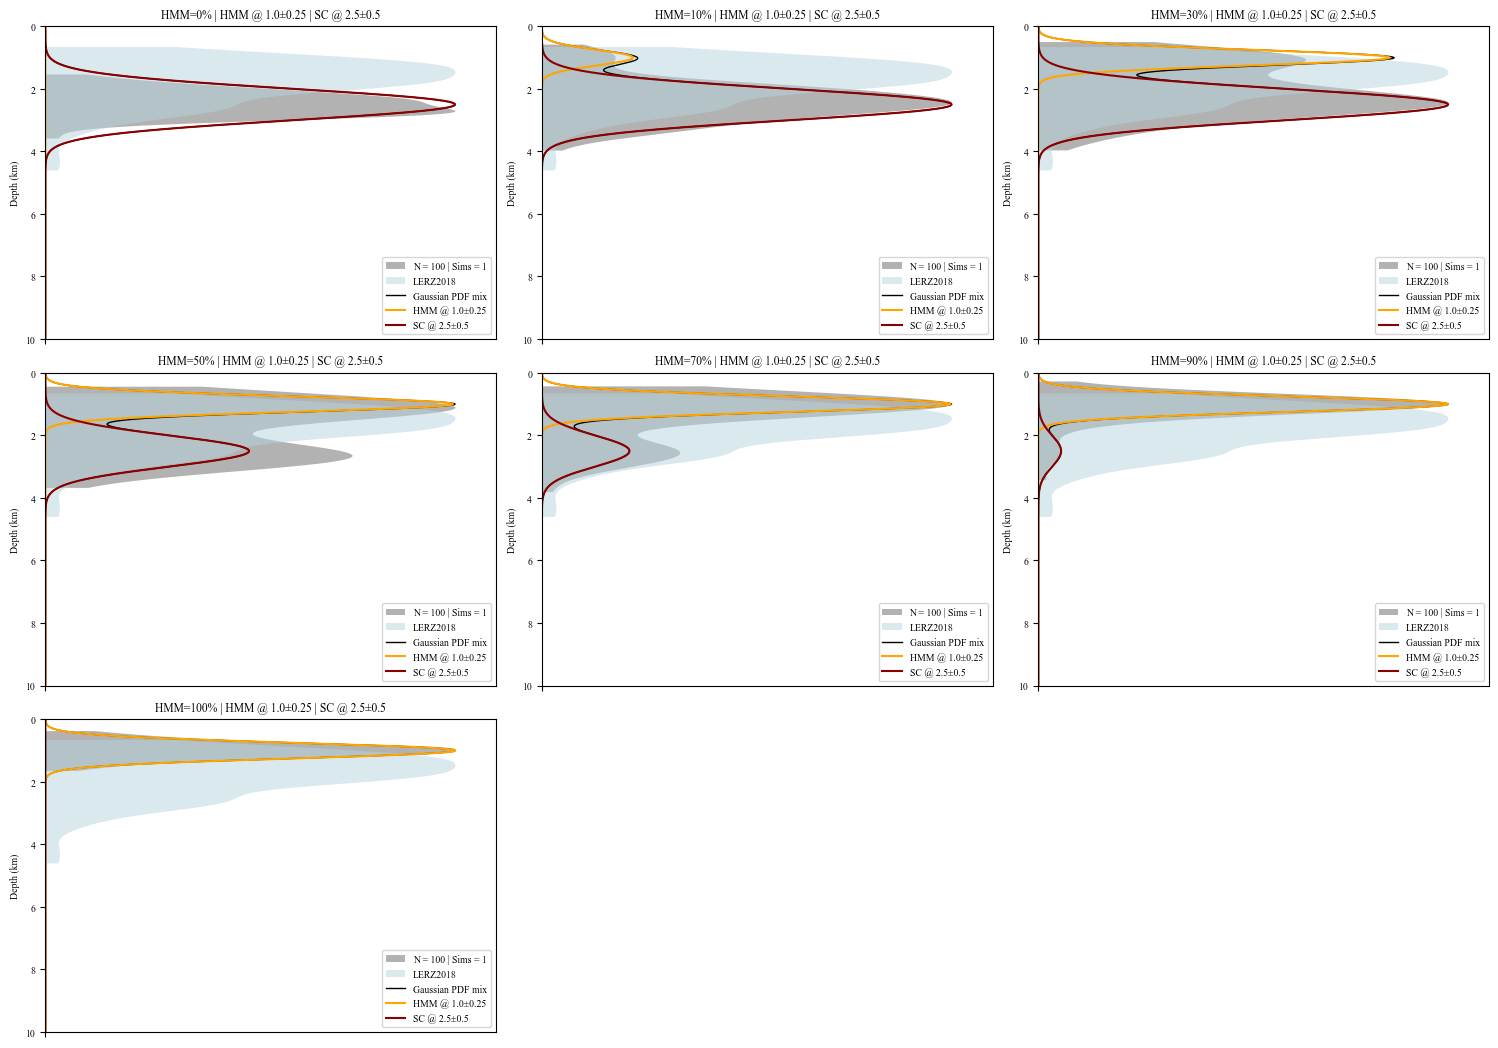

In [138]:
mu1, sigma1 = 1., 0.5/2
mu2, sigma2 = 2.5, 1/2
proportions = [0,0.1,0.3,0.5,0.7,0.9,1]
N_grid = [10, 20, 50, 100, 200, 500]
rng = np.random.default_rng(42)

ylims = (10, 0)
xs = np.linspace(min(ylims), max(ylims), 2000)

N_total = N_grid[3]
n_sims = 1
mix_mean_var_sd=False # if you want to calculate and export mean, variance and sd for the mixed dists set to True
scale_mix_to_violin=True # if you want to scale the mixed pdfs to the violins set to true
plot_theoretical_mix=True # if you want to plot the analytical mixture of Gaussian PDFs

res = {}

for p1 in proportions:
    n1 = int(round(p1 * N_total))
    n2 = N_total - n1
    p2 = 1-p1

    f_mix_theo = (p1 * (1.0 / (sigma1 * np.sqrt(2*np.pi))) * np.exp(-0.5 * ((xs - mu1) / sigma1)**2) +
              p2 * (1.0 / (sigma2 * np.sqrt(2*np.pi))) * np.exp(-0.5 * ((xs - mu2) / sigma2)**2))

    peaks, _ = signal.find_peaks(f_mix_theo)
    theo_modes = xs[peaks]
    mix_kurtosis=stats.kurtosis(f_mix_theo,fisher=True)
    mix_skewness=stats.skew(f_mix_theo)

    pooled_list = []
    by_sim_detail=[]
    for s in range(n_sims):
        x1 = rng.normal(mu1, sigma1, size=n1)
        x2 = rng.normal(mu2, sigma2, size=n2)
        pooled = np.concatenate([x1, x2])
        pooled_list.append(pooled)
        by_sim_detail.append({"sim": s, "data": [x1,x2]})

    all_data = np.concatenate(pooled_list)
    data_by_sim = np.vstack(pooled_list)

    res[p1] = {
        "data": all_data,
        "data_by_sim": data_by_sim,
        "mu1": mu1, "sigma1": sigma1,
        "mu2": mu2, "sigma2": sigma2,
        "p1": p1, "p2": 1 - p1,
        "n1": n1, "n2": n2,
        "N_total": N_total,
        "n_sims": n_sims,
        "xs": xs,
        "f_mix_theo":f_mix_theo,
        "mix_theo_modes":theo_modes,
        "mix_kurtosis":mix_kurtosis,
        "mix_skewness":mix_skewness,
    }
    ## if we want the mean, variance and stdev of the mixture, theoretical and empirical, use this, 
    ## but honestly, it is not very meaningful since the mixture could be bimodal
    if mix_mean_var_sd==True:

        mu_mix = p1*mu1 + p2*mu2
        var_mix = p1*(sigma1**2 + mu1**2) + p2*(sigma2**2 + mu2**2) - mu_mix**2
        std_mix = np.sqrt(var_mix)
        emp_mean = float(np.mean(all_data))
        emp_std = float(np.std(all_data, ddof=1)) if all_data.size > 1 else float(np.std(all_data))

        res[p1].update({
            "emp_mean": emp_mean,
            "emp_std": emp_std,
            "theo_mean": mu_mix,
            "theo_std": std_mix,
            "theo_var": var_mix,
        })

## Now plot the res
n_cols = 3
n_rows = int(np.ceil(len(proportions)/ n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows))
axes = axes.flatten()  
for ax, p1 in zip(axes, proportions):
    r = res[p1]

    sns.violinplot(y=r['data'],ax=ax,bw_method='silverman',density_norm='area',
                   inner=None,fill=True,orient='v',cut=0,linewidth=0,color="#000000",alpha=0.3,
                   label=f"N = {N_total} | Sims = {n_sims}")
    sns.violinplot(data=all_data_simplified[all_data_simplified['Sample'].str.contains("LL")]['SingleCalc_D_km'], 
                   color='lightblue', fill=True,inner=None, ax=ax, cut=0,orient='v',linewidth=0,zorder=1,
                   alpha=0.5,label='LERZ2018')
    # this is to scale the theoretical pdfs to the violin
    if scale_mix_to_violin==True:
        polys = [c for c in ax.collections if hasattr(c, "get_paths") and c.get_paths()]
        target_half_width = max((np.max(np.abs(p.vertices[:, 0]))
                for p in (polys[0].get_paths() if polys else [])
                if p.vertices.size),default=0.2)
        scale_factor = (target_half_width / np.max(r["f_mix_theo"])) if np.max(r["f_mix_theo"]) > 0 else 1
    else:
        scale_factor=1
    if plot_theoretical_mix==True:
        ax.plot(r["f_mix_theo"] * scale_factor,r['xs'], color="black", lw=1,label='Gaussian PDF mix')
    
    hm_f=r["p1"] * (1.0 / (sigma1 * np.sqrt(2*np.pi))) * np.exp(-0.5 * ((r['xs'] - r["mu1"]) / r["sigma1"])**2)
    sc_f=r["p2"] * (1.0 / (sigma2 * np.sqrt(2*np.pi))) * np.exp(-0.5 * ((r['xs'] - r["mu2"]) / r["sigma2"])**2)
    ax.plot(hm_f*scale_factor,r['xs'],color='orange',label=f'HMM @ {r["mu1"]}±{r["sigma1"]}')
    ax.plot(sc_f*scale_factor,r['xs'],color='darkred',label=f'SC @ {r["mu2"]}±{r["sigma2"]}')

    ax.set_title(f"HMM={r["p1"]*100:.0f}% | HMM @ {r["mu1"]}±{r["sigma1"]} | SC @ {r["mu2"]}±{r["sigma2"]}")
    ax.set_xlim(0)
    ax.set_ylim(max(ylims),min(ylims))
    ax.legend(loc='lower right')
    ax.set_ylabel("Depth (km)")

for ax in axes[len(proportions):]:
    ax.axis("off")

fig.tight_layout()
plt.show()

(10.0, 0.0)

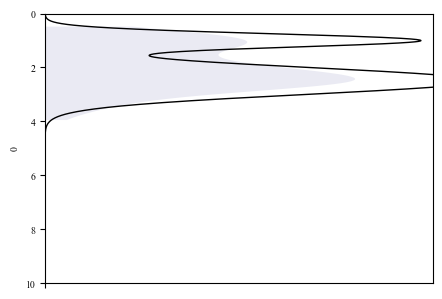

In [139]:
prop=proportions[2]
df = pd.DataFrame(res[prop]['data_by_sim'])

fig, ax = plt.subplots(1, 1, figsize=(5 * 1, 3.5 * 1))

for row,data in df.iterrows():
    sns.violinplot(y=data,ax=ax,bw_method='silverman',density_norm='area',
                inner=None,fill=True,orient='v',cut=0,linewidth=0,color="#B5B7DD",alpha=0.3
                )
ax.set_xlim(0)
ax.plot(res[prop]["f_mix_theo"] ,res[prop]['xs'], color="black", lw=1,label='Gaussian PDF mix')
ax.set_ylim([10,0])
    

In [140]:
all_data_simplified[all_data_simplified['Sample'].str.contains("LL")]

,Eruption_title,"Eruption_location_type(ERZ,VSWRZ,SSWRZ,Summit)",Sample,Sample_crystal,FI_name,FI_type,CO2_dens_gcm3_input,SO2 mol%,XH2O_av_iteration3_final,SingleCalc_P_kbar,std_dev_MC_P_kbar,SingleCalc_D_km,std_dev_MC_D_km,Fo_Ol_%,GOS
0,LERZ\n(May-Aug 2018),ERZ,LL4,LL4-14dp,LL4-14dp-FI#1,P,0.176605,4.088172,0.055466,0.615465,0.028431,2.577375,0.111604,86.489906,NaN
1,LERZ\n(May-Aug 2018),ERZ,LL4,LL4-14dp,LL4-14dp-FI#2,P,0.180578,2.406601,0.054643,0.630145,0.030796,2.635003,0.120528,86.408810,NaN
2,LERZ\n(May-Aug 2018),ERZ,LL4,LL4-14dp,LL4-14dp-MI#1,P,0.180858,6.492751,0.054514,0.632577,0.032788,2.644538,0.128258,86.562293,NaN
3,LERZ\n(May-Aug 2018),ERZ,LL4,LL4-21,LL4-21-#2,P,0.147317,0.000000,0.066753,0.490991,0.025091,2.082096,0.100907,83.886871,NaN
4,LERZ\n(May-Aug 2018),ERZ,LL4,LL4-21,LL4-21-MI#5,P,0.080378,0.000000,0.116065,0.277623,0.022966,1.203838,0.096463,86.554679,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97,LERZ\n(May-Aug 2018),ERZ,LL8,LL8_406,LL8_406-FI#4,P,0.117806,0.000000,0.081526,0.402316,0.072328,1.721747,0.295439,86.443569,NaN
98,LERZ\n(May-Aug 2018),ERZ,LL8,LL8_406,LL8_406_FI#1,P,0.109444,0.000000,0.087831,0.373903,0.031660,1.604906,0.130321,86.443569,NaN
99,LERZ\n(May-Aug 2018),ERZ,LL8,LL8_406,LL8_406_FI#2,P,0.134293,6.023012,0.071222,0.459464,0.024843,1.954717,0.100606,86.443569,NaN
100,LERZ\n(May-Aug 2018),ERZ,LL8,LL8_406,LL8_406_FI#3,P,0.121505,1.258356,0.078976,0.414997,0.024963,1.773676,0.101975,86.443569,NaN


In [141]:
print(np.mean(pd.to_numeric(geophysics[sc]['Depth (km)'], errors='coerce')))
print(np.std(pd.to_numeric(geophysics[sc]['Depth (km)'], errors='coerce')))

3.0470731707317076
1.138634706412045


In [142]:
all_data_simplified[all_data_simplified['Eruption_title'].str.contains("Keana")]

,Eruption_title,"Eruption_location_type(ERZ,VSWRZ,SSWRZ,Summit)",Sample,Sample_crystal,FI_name,FI_type,CO2_dens_gcm3_input,SO2 mol%,XH2O_av_iteration3_final,SingleCalc_P_kbar,std_dev_MC_P_kbar,SingleCalc_D_km,std_dev_MC_D_km,Fo_Ol_%,GOS
0,Early Keanakākoʻi\n(1500-1650 CE),Explosive Era,L25_Keana_B,K99-6_1,K99-6_1c,P,0.120007,NaN,0.083273,0.394130,0.037063,1.688157,0.152161,82.782003,NaN
1,Early Keanakākoʻi\n(1500-1650 CE),Explosive Era,L25_Keana_B,K99-6_2,K99-6_2d,P,0.137424,NaN,0.071719,0.456349,0.023423,1.942088,0.094967,83.780761,NaN
2,Early Keanakākoʻi\n(1500-1650 CE),Explosive Era,L25_Keana_B,K99-6_5,K99-6_5b,P,0.126863,NaN,0.078322,0.418456,0.023944,1.787816,0.097834,83.238780,NaN
3,Early Keanakākoʻi\n(1500-1650 CE),Explosive Era,L25_Keana_B,K99-6_5,K99-6_5d,P,0.114421,NaN,0.087029,0.377381,0.030935,1.619246,0.127451,83.238780,NaN
4,Early Keanakākoʻi\n(1500-1650 CE),Explosive Era,L25_Keana_B,K99-6_5,K99-6_5e,P,0.118254,NaN,0.084181,0.389956,0.022062,1.671005,0.090651,83.238780,NaN
5,Early Keanakākoʻi\n(1500-1650 CE),Explosive Era,L25_Keana_B,K99-6_6,K99-6_6a,P,0.133633,NaN,0.074064,0.442030,0.036217,1.883930,0.147208,83.451016,NaN
6,Early Keanakākoʻi\n(1500-1650 CE),Explosive Era,L25_Keana_B,K99-6_7,K99-6_7,P,0.113523,NaN,0.089258,0.368059,0.026657,1.580791,0.109975,81.066308,NaN
7,Early Keanakākoʻi\n(1500-1650 CE),Explosive Era,L25_Keana_B,K99-6_8,K99-6_8b,P,0.114549,NaN,0.086658,0.378971,0.031415,1.625800,0.129327,83.573095,NaN
8,Early Keanakākoʻi\n(1500-1650 CE),Explosive Era,L25_Keana_B,K99-6_8,K99-6_8c,P,0.135555,NaN,0.072890,0.449063,0.024612,1.912517,0.099855,83.573095,NaN
9,Early Keanakākoʻi\n(1500-1650 CE),Explosive Era,L25_Keana_B,K99-6_8,K99-6_8d,P,0.108834,NaN,0.091773,0.357926,0.026122,1.538906,0.107989,82.843566,NaN


In [144]:
sns.__version__

'0.13.2'

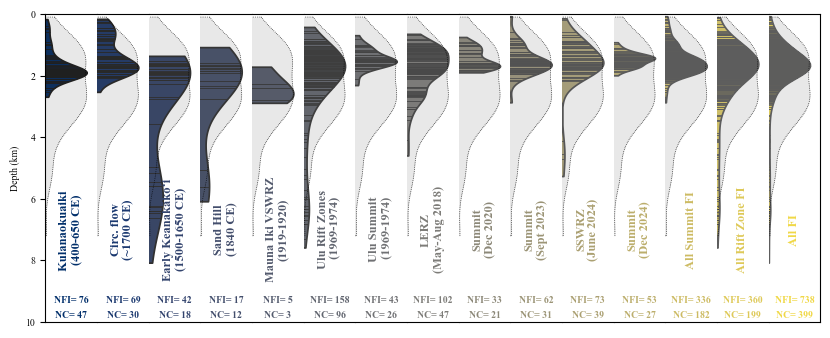

In [143]:
mask=(~all_data_simplified['FI_type'].str.contains('T'))
datasets = [all_data_simplified[mask&all_data_simplified['Eruption_title'].str.contains("Kulana")],
            all_data_simplified[mask&all_data_simplified['Eruption_title'].str.contains("Circ.")],
            all_data_simplified[mask&all_data_simplified['Eruption_title'].str.contains("Keana")],
            all_data_simplified[mask&all_data_simplified['Eruption_title'].str.contains("Sand")],
            all_data_simplified[mask&all_data_simplified['Eruption_title'].str.contains("Mauna Iki")],
            all_data_simplified[mask&all_data_simplified['Sample'].str.contains('908|909|910|931|919')],
            all_data_simplified[mask&all_data_simplified['Sample'].str.contains('914|916|917|924')],
            all_data_simplified[mask&all_data_simplified['Eruption_title'].str.contains("LERZ")],
            all_data_simplified[mask&all_data_simplified['Sample'].str.contains("K20")],
            all_data_simplified[mask&all_data_simplified['Sample'].str.contains("K23")],
            all_data_simplified[mask&all_data_simplified['Sample'].str.contains("K24")],
            all_data_simplified[mask&all_data_simplified['Sample'].str.contains("KD24")],
            all_data_simplified[mask&all_data_simplified['Eruption_location_type(ERZ,VSWRZ,SSWRZ,Summit)'].str.contains("Summit")],
            all_data_simplified[mask&all_data_simplified['Eruption_location_type(ERZ,VSWRZ,SSWRZ,Summit)'].str.contains("RZ")],
            all_data_simplified[mask]
            ]


titles = ["Kulanaokuaiki \n(400-650 CE)", 
          "Circ. flow\n(~1700 CE)",
          "Early Keanakākoʻi\n(1500-1650 CE)",
          "Sand Hill\n(1840 CE)", 
          "Mauna Iki VSWRZ\n(1919-1920)",
          "Ulu Rift Zones\n (1969-1974)",
          "Ulu Summit\n (1969-1974)",
          "LERZ\n(May-Aug 2018)", 
          "Summit\n(Dec 2020)", 
          "Summit\n(Sept 2023)", 
          "SSWRZ\n(June 2024)", 
          "Summit\n(Dec 2024)",
          "All Summit FI",
          "All Rift Zone FI",
          "All FI"
          ]

num_axes = len(datasets)
annotation_colors = sns.color_palette("cividis", num_axes)

fig, axes = plt.subplots(1, num_axes, figsize=(10, 4), sharey=True)

for i, (ax, data, title, ann_color) in enumerate(zip(axes, datasets, titles, annotation_colors)):
    sns.violinplot(data=data['SingleCalc_D_km'], color=ann_color, inner='stick', ax=ax, cut=0,zorder=1)
    if i>=0:
        sns.violinplot(y=geophysics['Depth (km)'].dropna().astype(float),
            ax=ax,inner=None,fill=False,color='k',orient='v',linestyle=':',cut=0,linewidth=0.5,zorder=2)
        sns.violinplot(y=geophysics['Depth (km)'].dropna().astype(float),
            ax=ax,inner=None,color='lightgrey',orient='v',cut=0,linewidth=0,zorder=0,alpha=0.5)
    ax.set_ylim([10, 0])
    ax.xaxis.set_tick_params(bottom=False)
    # ax.spines['top'].set_visible(False)   
    # ax.spines['bottom'].set_visible(False)   
    if i == 0:
        ax.set_ylabel('Depth (km)')
        ax.spines['right'].set_visible(False)   
    elif i==num_axes-1:
        ax.yaxis.set_tick_params(left=False, labelleft=False)
        ax.spines['left'].set_visible(False)        
        ax.spines['right'].set_visible(True)        
    else:
        ax.yaxis.set_tick_params(left=False, labelleft=False)
        ax.spines['left'].set_visible(False)
        ax.spines['right'].set_visible(False)

    ax.set_xlim(0,0.5)
    fontsize = 9
    ax.annotate(title, xy=(0.5, 0.3), xycoords='axes fraction', fontsize=fontsize,
                ha='center', va='center', color=ann_color, fontweight='bold', rotation=90)
    ax.annotate(f'NFI= {len(data)}', xy=(0.5, 0.07), xycoords='axes fraction', fontsize=fontsize-2,
                ha='center', va='center', color=ann_color, fontweight='bold')
    ax.annotate(f'NC= {len(data["Sample_crystal"].unique())}', xy=(0.5, 0.02), xycoords='axes fraction', fontsize=fontsize-2,
            ha='center', va='center', color=ann_color, fontweight='bold')

plt.subplots_adjust(wspace=0)
fig.savefig(figpath + slash + 'Kil_violin_plot_allFI_grouped_4talk.pdf', format='pdf', dpi=300, transparent=False)


In [67]:
K20['Fo_Ol']

35     0.801426
65     0.812591
67     0.816193
69     0.880733
77     0.860823
87     0.802764
93     0.813388
101    0.880834
112    0.835383
123    0.862001
141    0.839806
142    0.830208
145    0.813524
167    0.852364
254    0.818902
292    0.814377
298    0.814540
310    0.872405
312    0.815682
317    0.814473
319    0.815682
323    0.809874
332    0.813722
355    0.812893
363    0.813244
367    0.814768
379    0.815682
384    0.816569
422    0.810570
423    0.810957
435    0.814133
442    0.812315
469    0.810570
Name: Fo_Ol, dtype: float64

In [68]:
K20[K20['filename'].str.contains("K20_c005")][['filename','Density g/cm3','Fo_Ol']] ## this is the shoulder crystal from Kendra. So maybe it grew in HM, then went down, then up? or it grew in HM, then got hit with hot magmas, didn't erupt and got hit again?
K20[K20['filename'].str.contains("K20_c008|K20_c009")][['filename','Density g/cm3','Fo_Ol','SingleCalc_D_km']] # 008 is a noraml zoned, high Fo core. FI in the core. Lynn suggested this would have come from SC. But the pressures don't track. It's also undeformed.
K20[['filename','Density g/cm3','Fo_Ol','SingleCalc_D_km','GOS']]


,filename,Density g/cm3,Fo_Ol,SingleCalc_D_km,GOS
35,K20_c021_a1_FIA,0.050869,0.801426,0.747363,0.181699
65,K20_c010_a1_FIA,0.063404,0.812591,0.921114,0.109259
67,K20_c019_a1_FIA,0.064011,0.816193,0.931493,0.181335
69,K20_c008_a1_FIA,0.064505,0.880733,1.002641,0.128481
77,K20_c005_a2_FIB,0.068034,0.860823,1.026516,0.204347
87,K20_c003_a1_FIA_r2,0.070133,0.802764,1.004456,0.094166
93,K20_c018_a2_FIB,0.073429,0.813388,1.054786,0.202384
101,K20_c008_a2_FIB,0.077172,0.880834,1.182734,0.128481
112,K20_c009_a2_FIB,0.081024,0.835383,1.175009,0.157840
123,K20_c005_a3_FIC,0.084521,0.862001,1.255884,0.204347


In [69]:
K20[K20['filename'].str.contains("K20_c015")][['filename','Density g/cm3','Fo_Ol','SingleCalc_D_km','GOS']]

,filename,Density g/cm3,Fo_Ol,SingleCalc_D_km,GOS
142,K20_c015_a1_FIA,0.08911,0.830208,1.277673,0.244097


/var/folders/r2/dcn33vbj1x1b46n5mm7vn9bc0000gn/T/ipykernel_40380/1899834912.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  rift_data['Category'] = 'Rift Zones'
/var/folders/r2/dcn33vbj1x1b46n5mm7vn9bc0000gn/T/ipykernel_40380/1899834912.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=combined_data, x='Category', y='SingleCalc_D_km',


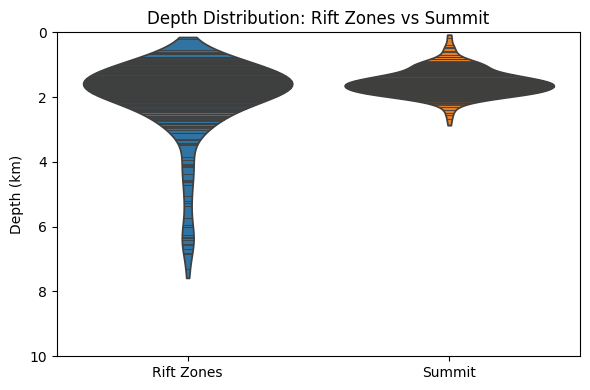

In [70]:
newdata['FI_type']=newdata['FI_type'].astype(str)
Ulu_all=newdata[newdata['Sample'].str.contains('908|909|910|914|916|917|919|924|931')&~(newdata['SO2 mol%']>SO2_cutoff)&~(newdata['FI_type'].str.contains('S'))]
Ulu_summit=newdata[newdata['Sample'].str.contains('914|916|917|924')&~(newdata['SO2 mol%']>SO2_cutoff)&~(newdata['FI_type'].str.contains('S'))]
Ulu_rzs=newdata[newdata['Sample'].str.contains('908|909|910|931|919')&~(newdata['SO2 mol%']>SO2_cutoff)&~(newdata['FI_type'].str.contains('S'))]

rift_data = pd.concat([Ulu_rzs['SingleCalc_D_km'],K24,LERZ2018,Iki_930])
summit_data = pd.concat([UW,Ulu_summit,K20,K23,KD24])

rift_data['Category'] = 'Rift Zones'
summit_data['Category'] = 'Summit'

combined_data = pd.concat([rift_data, summit_data])

plt.figure(figsize=(6, 4))
sns.violinplot(data=combined_data, x='Category', y='SingleCalc_D_km',
               palette=['#1f77b4', '#ff7f0e'], inner='stick', cut=0, bw_method='silverman')

# Customize plot
plt.ylim([10, 0])  # Invert y-axis
plt.ylabel('Depth (km)')
plt.xlabel('')
plt.title('Depth Distribution: Rift Zones vs Summit')

# Save figure
plt.tight_layout()
plt.savefig(figpath + slash + 'Kil_violin_plot_rift_vs_summit.pdf', dpi=300)


### All FI, all eruptions

In [71]:
pf.__version__

'1.0.5'

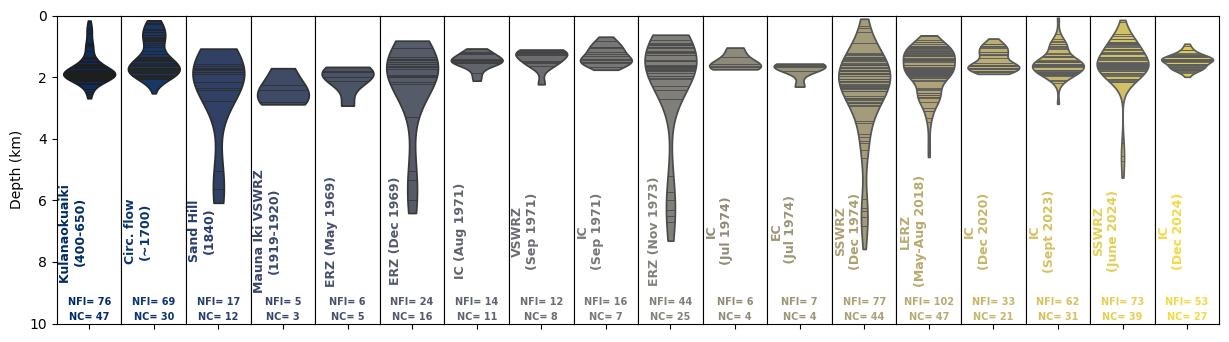

In [72]:
# Define datasets
datasets = [UW,K21,L84,
            Iki_930,
            Ulu_909,
            Ulu_908,
            Ulu_916,
            Ulu_931,
            Ulu_914,
            Ulu_910,
            Ulu_917,
            Ulu_924,
            Ulu_919,  
            LERZ2018, K20, K23, K24, KD24]
titles = ["Kulanaokuaiki \n(400-650)", "Circ. flow\n(~1700)", "Sand Hill\n(1840)", 
          "Mauna Iki VSWRZ\n(1919-1920)",
          "ERZ (May 1969)",
          "ERZ (Dec 1969)",
          "IC (Aug 1971)",
          "VSWRZ\n(Sep 1971)",
          "IC\n(Sep 1971)",
          "ERZ (Nov 1973)",
          "IC\n(Jul 1974)",
          "EC\n (Jul 1974)",
          "SSWRZ\n(Dec 1974)",
          "LERZ\n(May-Aug 2018)", "IC\n(Dec 2020)", "IC\n(Sept 2023)", "SSWRZ\n(June 2024)", "IC\n(Dec 2024)"]

# Define the number of subplots based on datasets
num_axes = len(datasets)

# Generate colors using a seaborn color palette
annotation_colors = sns.color_palette("cividis", num_axes)  # Darker contrasting colors

# Create subplots
fig, axes = plt.subplots(1, num_axes, figsize=(15, 4), sharey=True)

# Plot data
for i, (ax, data, title, ann_color) in enumerate(zip(axes, datasets, titles, annotation_colors)):
    
    # Create violin plot
    sns.violinplot(data=data['SingleCalc_D_km'], color=ann_color, inner='stick', ax=ax, cut=0)
    
    # Set y-axis properties
    ax.set_ylim([10, 0])  # Inverted y-axis
    if i == 0:
        ax.set_ylabel('Depth (km)')
    else:
        ax.yaxis.set_tick_params(left=False, labelleft=False)
    
    # Add title and annotation
    fontsize = 9
    ax.annotate(title, xy=(0.25, 0.3), xycoords='axes fraction', fontsize=fontsize,
                ha='center', va='center', color=ann_color, fontweight='bold', rotation=90)
    ax.annotate(f'NFI= {len(data)}', xy=(0.5, 0.07), xycoords='axes fraction', fontsize=fontsize-2,
                ha='center', va='center', color=ann_color, fontweight='bold')
    ax.annotate(f'NC= {len(data["Sample_crystal"].unique())}', xy=(0.5, 0.02), xycoords='axes fraction', fontsize=fontsize-2,
            ha='center', va='center', color=ann_color, fontweight='bold')
# Adjust layout and save
plt.subplots_adjust(wspace=0)  # Slight spacing between plots
fig.savefig(figpath + slash + 'Kil_violin_plot_alleruptions.pdf', format='pdf', dpi=300, transparent=False)


### PLotting maximum pressure per crystal only, eruptions grouped

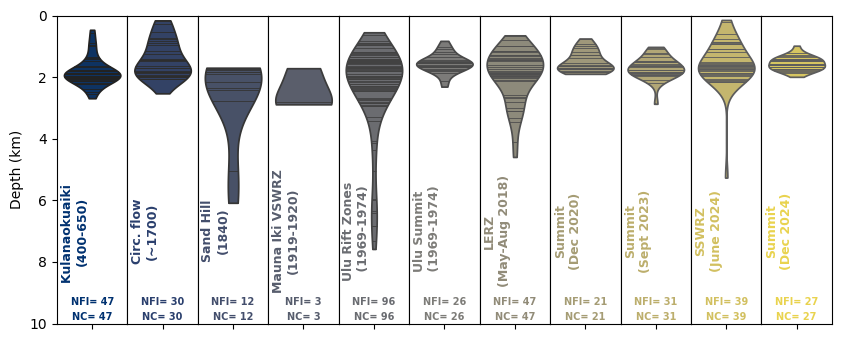

In [73]:
max_pressures_only = newdata.loc[newdata.groupby('Sample_crystal')['SingleCalc_P_kbar'].idxmax()]

Ulu_all=max_pressures_only[max_pressures_only['Sample'].str.contains('908|909|910|914|916|917|919|924|931')&~(max_pressures_only['SO2 mol%']>SO2_cutoff)]
Ulu_summit=max_pressures_only[max_pressures_only['Sample'].str.contains('914|916|917|924')&~(max_pressures_only['SO2 mol%']>SO2_cutoff)]
Ulu_rzs=max_pressures_only[max_pressures_only['Sample'].str.contains('908|909|910|931|919')&~(max_pressures_only['SO2 mol%']>SO2_cutoff)]
UW_plot=UW.loc[UW.groupby('Sample_crystal')['SingleCalc_P_kbar'].idxmax()]
K21_plot=K21.loc[K21.groupby('Sample_crystal')['SingleCalc_P_kbar'].idxmax()]
L84_plot=L84.loc[L84.groupby('Sample_crystal')['SingleCalc_P_kbar'].idxmax()]
Iki_930_plot=Iki_930.loc[Iki_930.groupby('Sample_crystal')['SingleCalc_P_kbar'].idxmax()]
LERZ2018_plot=LERZ2018.loc[LERZ2018.groupby('Sample_crystal')['SingleCalc_P_kbar'].idxmax()]
K20_plot=K20.loc[K20.groupby('Sample_crystal')['SingleCalc_P_kbar'].idxmax()]
K23_plot=K23.loc[K23.groupby('Sample_crystal')['SingleCalc_P_kbar'].idxmax()]
K24_plot=K24.loc[K24.groupby('Sample_crystal')['SingleCalc_P_kbar'].idxmax()]
KD24_plot=KD24.loc[KD24.groupby('Sample_crystal')['SingleCalc_P_kbar'].idxmax()]

# Define datasets
datasets = [UW_plot,K21_plot,L84_plot,
            Iki_930_plot,
            Ulu_rzs,
            Ulu_summit,
            LERZ2018_plot, K20_plot, K23_plot, K24_plot, KD24_plot]
titles = ["Kulanaokuaiki \n(400-650)", "Circ. flow\n(~1700)", "Sand Hill\n(1840)", 
          "Mauna Iki VSWRZ\n(1919-1920)",
          "Ulu Rift Zones\n (1969-1974)",
          "Ulu Summit\n (1969-1974)",
          "LERZ\n(May-Aug 2018)", "Summit\n(Dec 2020)", "Summit\n(Sept 2023)", "SSWRZ\n(June 2024)", "Summit\n(Dec 2024)"]

# Define the number of subplots based on datasets
num_axes = len(datasets)

# Generate colors using a seaborn color palette
annotation_colors = sns.color_palette("cividis", num_axes)  # Darker contrasting colors

# Create subplots
fig, axes = plt.subplots(1, num_axes, figsize=(10, 4), sharey=True)



# Plot data
for i, (ax, data, title, ann_color) in enumerate(zip(axes, datasets, titles, annotation_colors)):

    # Create violin plot
    sns.violinplot(data=data['SingleCalc_D_km'], color=ann_color, inner='stick', ax=ax, cut=0,bw_method='silverman')
    
    # Set y-axis properties
    ax.set_ylim([10, 0])  # Inverted y-axis
    if i == 0:
        ax.set_ylabel('Depth (km)')
    else:
        ax.yaxis.set_tick_params(left=False, labelleft=False)
    
    # Add title and annotation
    fontsize = 9
    ax.annotate(title, xy=(0.25, 0.3), xycoords='axes fraction', fontsize=fontsize,
                ha='center', va='center', color=ann_color, fontweight='bold', rotation=90)
    ax.annotate(f'NFI= {len(data)}', xy=(0.5, 0.07), xycoords='axes fraction', fontsize=fontsize-2,
                ha='center', va='center', color=ann_color, fontweight='bold')
    ax.annotate(f'NC= {len(data["Sample_crystal"].unique())}', xy=(0.5, 0.02), xycoords='axes fraction', fontsize=fontsize-2,
            ha='center', va='center', color=ann_color, fontweight='bold')
# Adjust layout and save
plt.subplots_adjust(wspace=0)  # Slight spacing between plots
fig.savefig(figpath + slash + 'Kil_violin_plot_maxP_only.pdf', format='pdf', dpi=300, transparent=False)


### All FI, eruptions grouped.

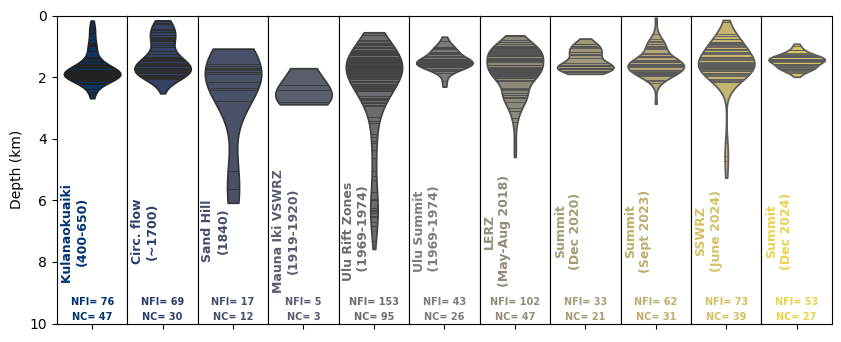

In [74]:
newdata['FI_type']=newdata['FI_type'].astype(str)
Ulu_all=newdata[newdata['Sample'].str.contains('908|909|910|914|916|917|919|924|931')&~(newdata['SO2 mol%']>SO2_cutoff)&~(newdata['FI_type'].str.contains('S'))]
Ulu_summit=newdata[newdata['Sample'].str.contains('914|916|917|924')&~(newdata['SO2 mol%']>SO2_cutoff)&~(newdata['FI_type'].str.contains('S'))]
Ulu_rzs=newdata[newdata['Sample'].str.contains('908|909|910|931|919')&~(newdata['SO2 mol%']>SO2_cutoff)&~(newdata['FI_type'].str.contains('S'))]

# Define datasets
datasets = [UW,K21,L84,
            Iki_930,
            Ulu_rzs,
            Ulu_summit,
            LERZ2018, K20, K23, K24, KD24]
titles = ["Kulanaokuaiki \n(400-650)", "Circ. flow\n(~1700)", "Sand Hill\n(1840)", 
          "Mauna Iki VSWRZ\n(1919-1920)",
          "Ulu Rift Zones\n (1969-1974)",
          "Ulu Summit\n (1969-1974)",
          "LERZ\n(May-Aug 2018)", "Summit\n(Dec 2020)", "Summit\n(Sept 2023)", "SSWRZ\n(June 2024)", "Summit\n(Dec 2024)"]

# Define the number of subplots based on datasets
num_axes = len(datasets)

# Generate colors using a seaborn color palette
annotation_colors = sns.color_palette("cividis", num_axes)  # Darker contrasting colors

# Create subplots
fig, axes = plt.subplots(1, num_axes, figsize=(10, 4), sharey=True)



# Plot data
for i, (ax, data, title, ann_color) in enumerate(zip(axes, datasets, titles, annotation_colors)):

    # Create violin plot
    sns.violinplot(data=data['SingleCalc_D_km'], color=ann_color, inner='stick', ax=ax, cut=0,bw_method='silverman')
    
    # Set y-axis properties
    ax.set_ylim([10, 0])  # Inverted y-axis
    if i == 0:
        ax.set_ylabel('Depth (km)')
    else:
        ax.yaxis.set_tick_params(left=False, labelleft=False)
    
    # Add title and annotation
    fontsize = 9
    ax.annotate(title, xy=(0.25, 0.3), xycoords='axes fraction', fontsize=fontsize,
                ha='center', va='center', color=ann_color, fontweight='bold', rotation=90)
    ax.annotate(f'NFI= {len(data)}', xy=(0.5, 0.07), xycoords='axes fraction', fontsize=fontsize-2,
                ha='center', va='center', color=ann_color, fontweight='bold')
    ax.annotate(f'NC= {len(data["Sample_crystal"].unique())}', xy=(0.5, 0.02), xycoords='axes fraction', fontsize=fontsize-2,
            ha='center', va='center', color=ann_color, fontweight='bold')
# Adjust layout and save
plt.subplots_adjust(wspace=0)  # Slight spacing between plots
fig.savefig(figpath + slash + 'Kil_violin_plot_allFI_grouped.pdf', format='pdf', dpi=300, transparent=False)


## plot fo vs depths

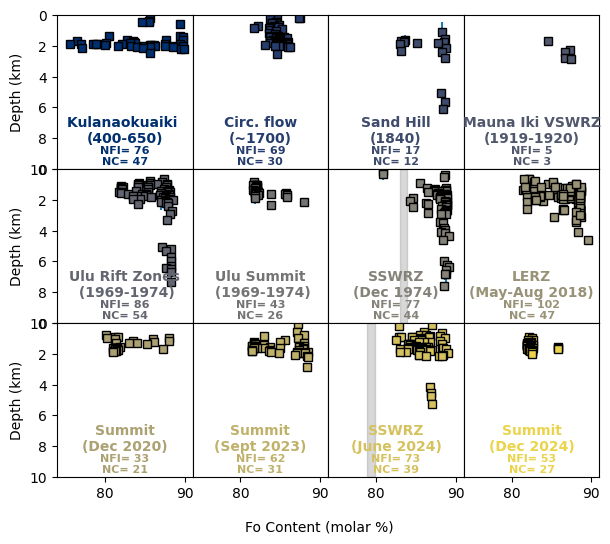

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math

Ulu_all=newdata[newdata['Sample'].str.contains('908|909|910|914|916|917|919|924|931')&~(newdata['SO2 mol%']>SO2_cutoff)&~(newdata['FI_type'].str.contains('S'))]
Ulu_summit=newdata[newdata['Sample'].str.contains('914|916|917|924')&~(newdata['SO2 mol%']>SO2_cutoff)&~(newdata['FI_type'].str.contains('S'))]
Ulu_rzs=newdata[newdata['Sample'].str.contains('908|909|910|931')&~(newdata['SO2 mol%']>SO2_cutoff)&~(newdata['FI_type'].str.contains('S'))]

# Define datasets
datasets = [UW,K21,L84,
            Iki_930,
            Ulu_rzs,
            Ulu_summit,
            Ulu_919,
            LERZ2018, K20, K23, K24, KD24]
titles = ["Kulanaokuaiki \n(400-650)", "Circ. flow\n(~1700)", "Sand Hill\n(1840)", 
          "Mauna Iki VSWRZ\n(1919-1920)",
          "Ulu Rift Zones\n (1969-1974)",
          "Ulu Summit\n (1969-1974)",
          "SSWRZ\n(Dec 1974)",
          "LERZ\n(May-Aug 2018)", "Summit\n(Dec 2020)", "Summit\n(Sept 2023)", "SSWRZ\n(June 2024)", "Summit\n(Dec 2024)"]


num_axes = len(datasets)
num_cols = math.ceil(num_axes / 3)  # Compute number of columns for 2 rows

# Generate colors using a seaborn color palette
annotation_colors = sns.color_palette("cividis", num_axes)

# Create subplots with 3 rows
fig, axes = plt.subplots(3, num_cols, figsize=(7,6), sharey=True, sharex=True)

# Flatten axes array for easier iteration
axes = axes.flatten()

# Plot data
for i, (ax, data, title, ann_color) in enumerate(zip(axes, datasets, titles, annotation_colors)):
    
    # Determine which column to use for 'x'
    if 'May-Aug 2018' in title:
        x = data['Corrected Fo content (molar %)_Cambridge']
    else:
        # Handle cases where 'Fo_Ol' is all NaN or missing
        if 'Fo_Ol' in data.columns and not data['Fo_Ol'].dropna().empty:
            x = data['Fo_Ol']*100
        else:
            x = np.full(len(data), np.nan)  # Placeholder array of NaNs

    # Plot only if x has valid values
    if not all(pd.isna(x)):
        ax.errorbar(x=x, y=data['SingleCalc_D_km'], yerr=data['std_dev_MC_D_km'],
                    mec='k', mfc=ann_color, fmt='s')

    # Set axis limits
    ax.set_ylim([10, 0])  # Inverted y-axis
    ax.set_xlim([74, 91])  

    if i % num_cols == 0:
        ax.set_ylabel('Depth (km)')
    else:
        ax.yaxis.set_tick_params(left=False, labelleft=False)

    # Ensure tick marks for x-axis
    ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=(i >= num_axes - num_cols))
    
    # Add title and annotation
    fontsize = 10
    ax.annotate(title, xy=(0.5, 0.25), xycoords='axes fraction', fontsize=fontsize,
                ha='center', va='center', color=ann_color, fontweight='bold')
    
    ax.annotate(f'NFI= {len(data)}', xy=(0.5, 0.12), xycoords='axes fraction', fontsize=fontsize-2,
                ha='center', va='center', color=ann_color, fontweight='bold')

    ax.annotate(f'NC= {len(data["Sample_crystal"].unique())}', xy=(0.5, 0.05), xycoords='axes fraction', 
                fontsize=fontsize-2, ha='center', va='center', color=ann_color, fontweight='bold')

    if title =="SSWRZ\n(Dec 1974)":
        ax.fill_betweenx(y=[0, 10], x1=83.01501029514966, x2=83.84032141030799, color='grey', alpha=0.3, label='Eq ol Shea 24')
    elif title =="SSWRZ\n(June 2024)":
        ax.fill_betweenx(y=[0, 10], x1=78.86156115618836, x2=79.83991990449506, color='grey', alpha=0.3, label='Eq ol Shea 24')

# Hide empty subplots if necessary
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout
plt.subplots_adjust(hspace=0, wspace=0)

# Add x-axis label only on the bottom row
fig.text(0.5, 0.02, 'Fo Content (molar %)', ha='center', fontsize=10)

# Save figure
fig.savefig(figpath + slash + 'Kil_Fodepth_plot.pdf', format='pdf', dpi=300, transparent=False)

plt.show()



### Fo per eruption color by depth

In [76]:
all_data_simplified


,Eruption_title,"Eruption_location_type(ERZ,VSWRZ,SSWRZ,Summit)",Sample,Sample_crystal,FI_name,FI_type,SingleCalc_D_km,std_dev_MC_D_km,Fo_Ol_%,GOS
0,IC\n(Sept 2023),Summit,K23,K23_2,K23_2_FIA,P,0.072973,0.017833,87.266314,0.112099
1,SSWRZ\n(Dec 1974),SSWRZ,KL0920,KL0920_c216,KL0920_c216_a2_FID,nan,0.106306,0.342417,80.865821,0.364898
2,SSWRZ\n(June 2024),SSWRZ,K24,K24_5,K24_5_FIA,P,0.144272,0.093193,86.965132,0.096661
3,Circ. flow\n(~1700),Summit,KL0921,KL0921_c288,KL0921_c288_a1_FIA,nan,0.158844,0.290971,84.120395,0.803403
4,Circ. flow\n(~1700),Summit,K21,K21_78b,K21_78b_FI#5,S,0.169164,0.179097,87.416437,NaN
...,...,...,...,...,...,...,...,...,...,...
37,Early Keanakākoʻi\n(1500-1650 CE),Explosive Era,"L25_Keana_D, upper",K99-5_11,K99-5_11b,P,2.278225,0.143955,88.892319,NaN
38,Early Keanakākoʻi\n(1500-1650 CE),Explosive Era,"L25_Keana_D, upper",K99-5_11,K99-5_11c,P,1.877495,0.167297,88.892319,NaN
39,Early Keanakākoʻi\n(1500-1650 CE),Explosive Era,"L25_Keana_D, upper",K99-5_11,K99-5_11e,P,1.995065,0.118793,88.892319,NaN
40,Early Keanakākoʻi\n(1500-1650 CE),Explosive Era,"L25_Keana_D, upper",K99-5_11,K99-5_11f,P,1.658169,0.107535,88.892319,NaN


/var/folders/r2/dcn33vbj1x1b46n5mm7vn9bc0000gn/T/ipykernel_40380/816636921.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[:,'dummy_x']=1
/var/folders/r2/dcn33vbj1x1b46n5mm7vn9bc0000gn/T/ipykernel_40380/816636921.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.loc[:,'dummy_x']=1
/var/folders/r2/dcn33vbj1x1b46n5mm7vn9bc0000gn/T/ipykernel_40380/816636921.py:50: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_ind

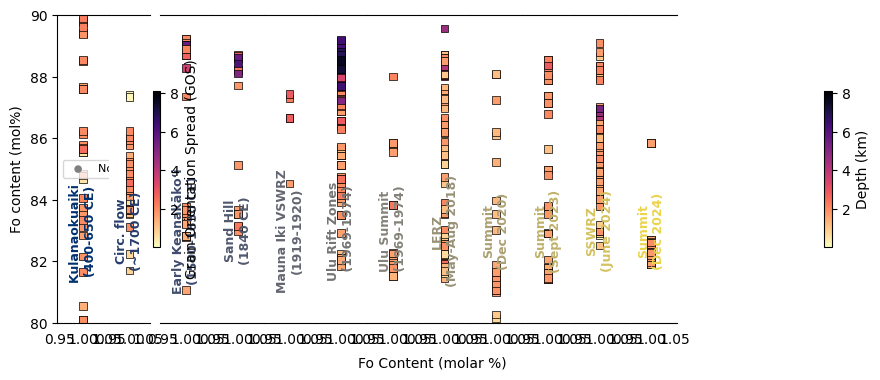

In [77]:
mask=(~all_data_simplified['FI_type'].str.contains('T'))
datasets = [all_data_simplified[mask&all_data_simplified['Eruption_title'].str.contains("Kulana")],
            all_data_simplified[mask&all_data_simplified['Eruption_title'].str.contains("Circ.")],
            all_data_simplified[mask&all_data_simplified['Eruption_title'].str.contains("Keana")],
            all_data_simplified[mask&all_data_simplified['Eruption_title'].str.contains("Sand")],
            all_data_simplified[mask&all_data_simplified['Eruption_title'].str.contains("Mauna Iki")],
            all_data_simplified[mask&all_data_simplified['Sample'].str.contains('908|909|910|931|919')],
            all_data_simplified[mask&all_data_simplified['Sample'].str.contains('914|916|917|924')],
            all_data_simplified[mask&all_data_simplified['Eruption_title'].str.contains("LERZ")],
            all_data_simplified[mask&all_data_simplified['Sample'].str.contains("K20")],
            all_data_simplified[mask&all_data_simplified['Sample'].str.contains("K23")],
            all_data_simplified[mask&all_data_simplified['Sample'].str.contains("K24")],
            all_data_simplified[mask&all_data_simplified['Sample'].str.contains("KD24")],
            all_data_simplified[mask&all_data_simplified['Eruption_location_type(ERZ,VSWRZ,SSWRZ,Summit)'].str.contains("Summit")],
            all_data_simplified[mask&all_data_simplified['Eruption_location_type(ERZ,VSWRZ,SSWRZ,Summit)'].str.contains("RZ")],
            all_data_simplified[mask]
            ]


titles = ["Kulanaokuaiki \n(400-650 CE)", 
          "Circ. flow\n(~1700 CE)",
          "Early Keanakākoʻi\n(1500-1650 CE)",
          "Sand Hill\n(1840 CE)", 
          "Mauna Iki VSWRZ\n(1919-1920)",
          "Ulu Rift Zones\n (1969-1974)",
          "Ulu Summit\n (1969-1974)",
          "LERZ\n(May-Aug 2018)", 
          "Summit\n(Dec 2020)", 
          "Summit\n(Sept 2023)", 
          "SSWRZ\n(June 2024)", 
          "Summit\n(Dec 2024)",
          "All Summit FI",
          "All Rift Zone FI",
          "All FI"
          ]

num_axes = len(datasets)
# Generate colors using a seaborn color palette

### Color by variable
colorvar='SingleCalc_D_km'
palette='magma_r'
global_min = np.nanmin(all_data_simplified[mask]['SingleCalc_D_km'])
global_max = np.nanmax(all_data_simplified[mask]['SingleCalc_D_km'])
norm = plt.Normalize(vmin=global_min, vmax=global_max)

fig, axes = plt.subplots(1, num_axes, figsize=(10, 4), sharey=True)

for i, (ax, data, title, ann_color) in enumerate(zip(axes, datasets, titles, annotation_colors)):
    data.loc[:,'dummy_x']=1
    x=data['dummy_x']
    if 'Fo_Ol_%' in data.columns and not data['Fo_Ol_%'].dropna().empty:
        y = data['Fo_Ol_%']
    else:
        y = np.full(len(data), np.nan)  # Placeholder array of NaNs

    # colors= np.array(plt.cm.Greens(norm(data[colorvar])))
    # nan_mask = np.isnan(data[colorvar])
    # colors[nan_mask] = [0, 0, 0, 0]
    
    if colorvar in data.columns:
        color_mask = ~data[colorvar].isna()
        ax.scatter(x[~color_mask], data.loc[~color_mask, 'Fo_Ol_%'],
                    color='grey', marker='o', label='No Fo',alpha=1,edgecolors='none',linewidths=0.3,s=30)
        ax.scatter(x[color_mask], data.loc[color_mask, 'Fo_Ol_%'],
                    c=data[colorvar][color_mask], cmap=palette, norm=norm, marker='s',alpha=1,edgecolors='k',linewidths=0.5,s=30)

    ax.set_ylim([80, 90])
    ax.xaxis.set_tick_params(bottom=False)
    # ax.spines['top'].set_visible(False)   
    # ax.spines['bottom'].set_visible(False)   
    if i == 0:
        ax.set_ylabel('Fo content (mol%)')
        ax.spines['right'].set_visible(False)   
    elif i==num_axes-1:
        ax.yaxis.set_tick_params(left=False, labelleft=False)
        ax.spines['left'].set_visible(False)        
        ax.spines['right'].set_visible(True)        
    else:
        ax.yaxis.set_tick_params(left=False, labelleft=False)
        ax.spines['left'].set_visible(False)
        ax.spines['right'].set_visible(False)

    # ax.set_xlim(0,0.5)
    fontsize = 9
    ax.annotate(title, xy=(0.5, 0.3), xycoords='axes fraction', fontsize=fontsize,
                ha='center', va='center', color=ann_color, fontweight='bold', rotation=90)
    # ax.annotate(f'NFI= {len(data)}', xy=(0.5, 0.07), xycoords='axes fraction', fontsize=fontsize-2,
    #             ha='center', va='center', color=ann_color, fontweight='bold')
    # ax.annotate(f'NC= {len(data["Sample_crystal"].unique())}', xy=(0.5, 0.02), xycoords='axes fraction', fontsize=fontsize-2,
    #         ha='center', va='center', color=ann_color, fontweight='bold')

plt.subplots_adjust(wspace=0)
sm = plt.cm.ScalarMappable(cmap=palette, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes[-1],orientation='vertical', label='Depth (km)')

# Hide empty subplots if necessary
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

axes[0].legend(loc='center left',fontsize=8)

# Adjust layout
plt.subplots_adjust(hspace=0, wspace=0)
sm = plt.cm.ScalarMappable(cmap=palette, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes[1],orientation='vertical', label='Grain Orientation Spread (GOS)')
fig.text(0.5, 0, 'Fo Content (molar %)', ha='center', fontsize=10)
plt.show()

# Save figure
fig.savefig(figpath + slash + 'Fo_color_depth_4talk.pdf', format='pdf', dpi=300, transparent=False)

## SO2 vs P

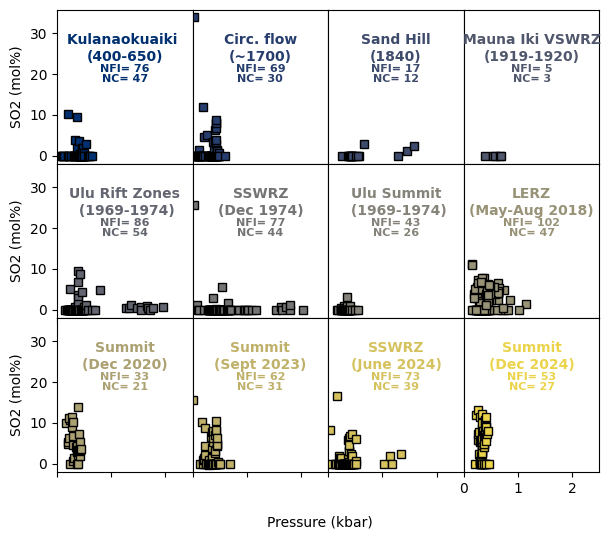

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math

Ulu_all=newdata[newdata['Sample'].str.contains('908|909|910|914|916|917|919|924|931')&~(newdata['SO2 mol%']>SO2_cutoff)&~(newdata['FI_type'].str.contains('S'))]
Ulu_summit=newdata[newdata['Sample'].str.contains('914|916|917|924')&~(newdata['SO2 mol%']>SO2_cutoff)&~(newdata['FI_type'].str.contains('S'))]
Ulu_rzs=newdata[newdata['Sample'].str.contains('908|909|910|931')&~(newdata['SO2 mol%']>SO2_cutoff)&~(newdata['FI_type'].str.contains('S'))]

# Define datasets
datasets = [UW,K21,L84,
            Iki_930,
            Ulu_rzs,
            Ulu_919,
            Ulu_summit,
            LERZ2018, K20, K23, K24, KD24]
titles = ["Kulanaokuaiki \n(400-650)", "Circ. flow\n(~1700)", "Sand Hill\n(1840)", 
          "Mauna Iki VSWRZ\n(1919-1920)",
          "Ulu Rift Zones\n (1969-1974)",
          "SSWRZ\n(Dec 1974)",
          "Ulu Summit\n (1969-1974)",
          "LERZ\n(May-Aug 2018)", "Summit\n(Dec 2020)", "Summit\n(Sept 2023)", "SSWRZ\n(June 2024)", "Summit\n(Dec 2024)"]

annotation_colors = sns.color_palette("cividis", len(datasets))

fig, axes = plt.subplots(3, num_cols, figsize=(7,6), sharey=True, sharex=True)
axes = axes.flatten()

for i, (ax, data, title, ann_color) in enumerate(zip(axes, datasets, titles, annotation_colors)):
    
    x = data['SingleCalc_P_kbar']

    if not all(pd.isna(x)):
        ax.errorbar(x=x, y=data['SO2 mol%'], 
                    mec='k', mfc=ann_color, fmt='s')

    # Set axis limits
    # ax.set_ylim([10, 0])  # Inverted y-axis
    ax.set_xlim([0, 2.5])  

    if i % num_cols == 0:
        ax.set_ylabel('SO2 (mol%)')
    else:
        ax.yaxis.set_tick_params(left=False, labelleft=False)

    # Ensure tick marks for x-axis
    ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=(i >= num_axes - num_cols))
    
    # Add title and annotation
    fontsize = 10
    ax.annotate(title, xy=(0.5, 0.75), xycoords='axes fraction', fontsize=fontsize,
                ha='center', va='center', color=ann_color, fontweight='bold')
    
    ax.annotate(f'NFI= {len(data)}', xy=(0.5, 0.62), xycoords='axes fraction', fontsize=fontsize-2,
                ha='center', va='center', color=ann_color, fontweight='bold')

    ax.annotate(f'NC= {len(data["Sample_crystal"].unique())}', xy=(0.5, 0.55), xycoords='axes fraction', 
                fontsize=fontsize-2, ha='center', va='center', color=ann_color, fontweight='bold')

    # if title =="SSWRZ\n(Dec 1974)":
    #     ax.fill_betweenx(y=[0, 10], x1=83.01501029514966, x2=83.84032141030799, color='grey', alpha=0.3, label='Eq ol Shea 24')
    # elif title =="SSWRZ\n(June 2024)":
    #     ax.fill_betweenx(y=[0, 10], x1=78.86156115618836, x2=79.83991990449506, color='grey', alpha=0.3, label='Eq ol Shea 24')

# Hide empty subplots if necessary
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout
plt.subplots_adjust(hspace=0, wspace=0)

# Add x-axis label only on the bottom row
fig.text(0.5, 0.02, 'Pressure (kbar)', ha='center', fontsize=10)

# Save figure
fig.savefig(figpath + slash + 'Kil_SO2P_plot.pdf', format='pdf', dpi=300, transparent=False)

plt.show()



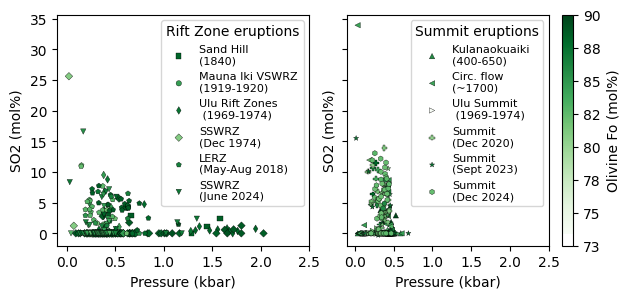

In [79]:
datasets = [L84, Iki_930, Ulu_rzs, Ulu_919,LERZ2018,K24,  
           UW, K21, Ulu_summit, K20, K23, KD24]
titles = ["Sand Hill\n(1840)", 
          "Mauna Iki VSWRZ\n(1919-1920)",
          "Ulu Rift Zones\n (1969-1974)",
          "SSWRZ\n(Dec 1974)",
          "LERZ\n(May-Aug 2018)", 
          "SSWRZ\n(June 2024)",
          "Kulanaokuaiki \n(400-650)", "Circ. flow\n(~1700)",
          "Ulu Summit\n (1969-1974)","Summit\n(Dec 2020)", "Summit\n(Sept 2023)", "Summit\n(Dec 2024)" ]

all_fo_ol = []
for data, title in zip(datasets, titles):
    if 'LERZ' in title:
        all_fo_ol.extend(data['Corrected Fo content (molar %)_Cambridge'].values)
    elif 'Sept 2023' in title:
        all_fo_ol.extend(data['Fo_Ol'].values)
    else:
        all_fo_ol.extend(data['Fo_Ol'].values)

all_fo_ol = np.array(all_fo_ol)
all_fo_ol = np.where(all_fo_ol > 1, all_fo_ol / 100, all_fo_ol)

global_min = np.nanmin(all_fo_ol)
global_max = np.nanmax(all_fo_ol)

markers = ['s', 'o', 'd', 'D', 'p', 'v', '^', '<', '>', 'P', '*', 'h']
fig, axes = plt.subplots(1, 2, figsize=(7, 3), sharey=True, sharex=True)
plt.subplots_adjust(hspace=0, wspace=0.15)

for i, (data, title, marker) in enumerate(zip(datasets, titles, markers)):

    if 'LERZ' in title:
        fo_ol = data['Corrected Fo content (molar %)_Cambridge']
    elif 'Sept 2023' in title:
        fo_ol = data['Fo_Ol']
    else:
        fo_ol = data['Fo_Ol']

    if np.any(fo_ol>1):
        fo_ol=fo_ol/100

    norm = plt.Normalize(vmin=global_min, vmax=global_max)
    colors= np.array(plt.cm.Greens(norm(fo_ol)))

    nan_mask = np.isnan(fo_ol)
    colors[nan_mask] = [1.0, 1.0, 1.0, 1.0]


    if i<6:
        axes[0].scatter(data['SingleCalc_P_kbar'], data['SO2 mol%'], 
                        c=fo_ol, cmap='Greens', norm=norm, marker=marker, label=title,alpha=1,edgecolors='k',linewidths=0.25,s=15)
    else:
        axes[1].scatter(data['SingleCalc_P_kbar'], data['SO2 mol%'], 
                        c=fo_ol,cmap='Greens',norm=norm, marker=marker, label=title,alpha=1,edgecolors='k',linewidths=0.25,s=15)

for ax in axes:

    ax.set_xlim([-0.1, 2.5])
    ax.set_ylabel('SO2 (mol%)')
    ax.set_xlabel('Pressure (kbar)')

axes[0].legend(fontsize=8,title='Rift Zone eruptions')
axes[1].legend(fontsize=8,title='Summit eruptions')

sm = plt.cm.ScalarMappable(cmap='Greens', norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes[1],orientation='vertical', label='Olivine Fo (mol%)')

tick_locs = cbar.get_ticks()
cbar.set_ticks(tick_locs)
cbar.set_ticklabels([f"{t * 100:.0f}" for t in tick_locs])

plt.show()


### Plot FI size vs Pressure


In [80]:
# Calculate scaled semiaxes for FI 
def scale(row, column_name):
    if row['mag'] == 50:
        return (row[column_name]) * 223.161 / 1920
    elif row['mag'] == 20:
        return (row[column_name]) * 546.419 / 1920
    elif row['mag'] == 100:
        return (row[column_name]) * 109.989 / 1920
    else:
        return None

newdata['FI_semiaxis_a_um_scaled'] = newdata.apply(scale, axis=1, column_name='FI_axis_a_um')
newdata['FI_semiaxis_b_um_scaled'] = newdata.apply(scale, axis=1, column_name='FI_axis_b_um')

LERZ2018['FI_semiaxis_a_um_scaled'] =LERZ2018.apply(scale, axis=1, column_name='FI_axis_a_um')
LERZ2018['FI_semiaxis_b_um_scaled'] =LERZ2018.apply(scale, axis=1, column_name='FI_axis_b_um')

newdata['FI_Area_um_scaled']=np.pi*newdata['FI_semiaxis_a_um_scaled']*newdata['FI_semiaxis_b_um_scaled']


Text(0, 0.5, 'P_kbar')

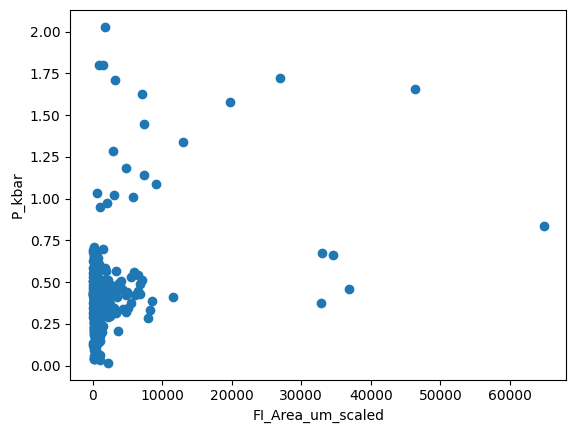

In [81]:
plt.scatter(newdata['FI_Area_um_scaled'],newdata['SingleCalc_P_kbar'])
plt.xlabel("FI_Area_um_scaled")
plt.ylabel("P_kbar")

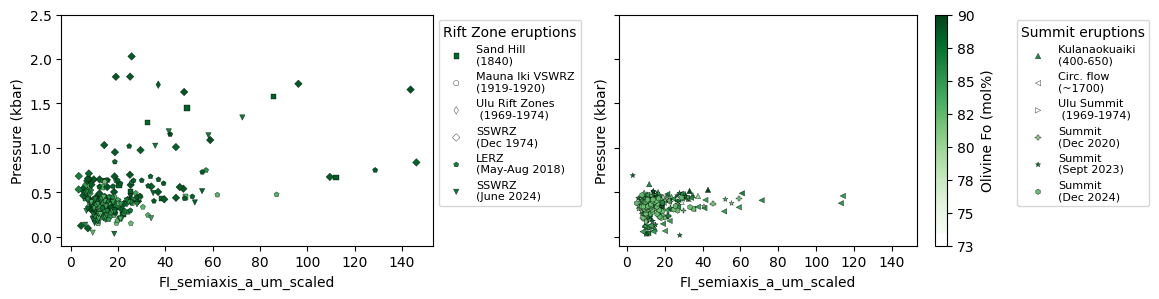

In [82]:
# This just creates sample filters for plotting
UW=newdata[(newdata['Sample'].str.contains('UW'))]
K21=newdata[(newdata['Sample'].str.contains('K21|921'))]
L84=newdata[(newdata['Sample'].str.contains('L84'))]
Ulu_919=newdata[newdata['Sample'].str.contains('919|920')]
K20=newdata[(newdata['Sample'].str.contains('K20'))]
K24=newdata[(newdata['Sample'].str.contains('K24'))]
KD24=newdata[(newdata['Sample'].str.contains('KD24'))]
Ulu_910=newdata[newdata['Sample'].str.contains('910')]
Ulu_908=newdata[newdata['Sample'].str.contains('908')]
Ulu_909=newdata[newdata['Sample'].str.contains('909')]
Ulu_916=newdata[newdata['Sample'].str.contains('916')]
Ulu_931=newdata[newdata['Sample'].str.contains('931')]
Ulu_914=newdata[newdata['Sample'].str.contains('914')]
Ulu_916=newdata[newdata['Sample'].str.contains('916')]
Ulu_917=newdata[newdata['Sample'].str.contains('917')]
Ulu_924=newdata[newdata['Sample'].str.contains('924')]
Iki_930=newdata[newdata['Sample'].str.contains('930')]
K23=newdata[newdata['Sample'].str.contains('K23')]

Ulu_all=newdata[newdata['Sample'].str.contains('908|909|910|914|916|917|919|924|931')&~(newdata['SO2 mol%']>SO2_cutoff)&~(newdata['FI_type'].str.contains('S'))]
Ulu_summit=newdata[newdata['Sample'].str.contains('914|916|917|924')&~(newdata['SO2 mol%']>SO2_cutoff)&~(newdata['FI_type'].str.contains('S'))]
Ulu_rzs=newdata[newdata['Sample'].str.contains('908|909|910|931')&~(newdata['SO2 mol%']>SO2_cutoff)&~(newdata['FI_type'].str.contains('S'))]


datasets = [L84, Iki_930, Ulu_rzs, Ulu_919,LERZ2018,K24,  
           UW, K21, Ulu_summit, K20, K23, KD24]
titles = ["Sand Hill\n(1840)", 
          "Mauna Iki VSWRZ\n(1919-1920)",
          "Ulu Rift Zones\n (1969-1974)",
          "SSWRZ\n(Dec 1974)",
          "LERZ\n(May-Aug 2018)", 
          "SSWRZ\n(June 2024)",
          "Kulanaokuaiki \n(400-650)", "Circ. flow\n(~1700)",
          "Ulu Summit\n (1969-1974)","Summit\n(Dec 2020)", "Summit\n(Sept 2023)", "Summit\n(Dec 2024)" ]

all_fo_ol = []
for data, title in zip(datasets, titles):
    if 'LERZ' in title:
        all_fo_ol.extend(data['Corrected Fo content (molar %)_Cambridge'].values)
    elif 'Sept 2023' in title:
        all_fo_ol.extend(data['Fo_Ol'].values)
    else:
        all_fo_ol.extend(data['Fo_Ol'].values)

all_fo_ol = np.array(all_fo_ol)
all_fo_ol = np.where(all_fo_ol > 1, all_fo_ol / 100, all_fo_ol)

global_min = np.nanmin(all_fo_ol)
global_max = np.nanmax(all_fo_ol)

markers = ['s', 'o', 'd', 'D', 'p', 'v', '^', '<', '>', 'P', '*', 'h']

fig, axes = plt.subplots(1, 2, figsize=(12, 3), sharey=True, sharex=True)
plt.subplots_adjust(hspace=0, wspace=0.5)

for i, (data, title, marker) in enumerate(zip(datasets, titles, markers)):

    if 'LERZ' in title:
        fo_ol = data['Corrected Fo content (molar %)_Cambridge']
    elif 'Sept 2023' in title:
        fo_ol = data['Fo_Ol']
    else:
        fo_ol = data['Fo_Ol']

    if np.any(fo_ol>1):
        fo_ol=fo_ol/100

    norm = plt.Normalize(vmin=global_min, vmax=global_max)
    colors= np.array(plt.cm.Greens(norm(fo_ol)))

    nan_mask = np.isnan(fo_ol)
    colors[nan_mask] = [1.0, 1.0, 1.0, 1.0]


    if i<6:
        axes[0].scatter(y=data['SingleCalc_P_kbar'], x=data['FI_semiaxis_a_um_scaled'], 
                        c=fo_ol, cmap='Greens', norm=norm, marker=marker, label=title,alpha=1,edgecolors='k',linewidths=0.25,s=15)
    else:
        axes[1].scatter(y=data['SingleCalc_P_kbar'], x=data['FI_semiaxis_a_um_scaled'], 
                        c=fo_ol,cmap='Greens',norm=norm, marker=marker, label=title,alpha=1,edgecolors='k',linewidths=0.25,s=15)

for ax in axes:

    ax.set_ylim([-0.1, 2.5])
    ax.set_xlabel('FI_semiaxis_a_um_scaled')
    ax.set_ylabel('Pressure (kbar)')

axes[0].legend(fontsize=8,title='Rift Zone eruptions', bbox_to_anchor=(1, 1))
axes[1].legend(fontsize=8,title='Summit eruptions', bbox_to_anchor=(1.8, 1))

sm = plt.cm.ScalarMappable(cmap='Greens', norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes[1],orientation='vertical', label='Olivine Fo (mol%)')

tick_locs = cbar.get_ticks()
cbar.set_ticks(tick_locs)
cbar.set_ticklabels([f"{t * 100:.0f}" for t in tick_locs])

plt.show()


## Plot EBSD data

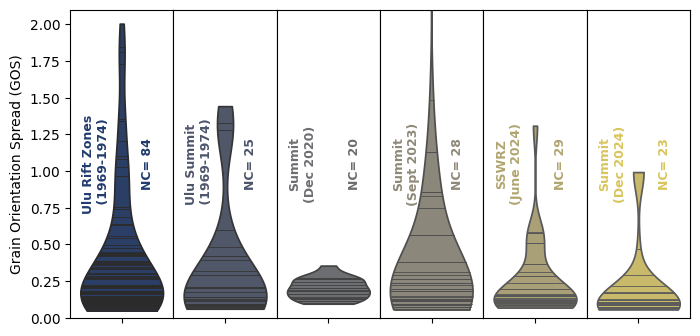

In [83]:
# Define datasets
Ulu_all=newdata[newdata['Sample'].str.contains('908|909|910|914|916|917|919|924|931')&~(newdata['SO2 mol%']>SO2_cutoff)&~(newdata['FI_type'].str.contains('S'))]
Ulu_summit=newdata[newdata['Sample'].str.contains('914|916|917|924')&~(newdata['SO2 mol%']>SO2_cutoff)&~(newdata['FI_type'].str.contains('S'))]
Ulu_rzs=newdata[newdata['Sample'].str.contains('908|909|910|931|919|920')&~(newdata['SO2 mol%']>SO2_cutoff)&~(newdata['FI_type'].str.contains('S'))]

datasets = [ Ulu_rzs,Ulu_summit,K20,K23, K24, KD24]
titles = ["Ulu Rift Zones\n (1969-1974)",
             "Ulu Summit\n (1969-1974)",
            "Summit\n(Dec 2020)",  "Summit\n(Sept 2023)", "SSWRZ\n(June 2024)","Summit\n(Dec 2024)"]

# Define the number of subplots based on datasets
num_axes = len(datasets)

# Generate colors using a seaborn color palette
annotation_colors = sns.color_palette("cividis", num_axes)  # Darker contrasting colors

# Create subplots
fig, axes = plt.subplots(1, num_axes, figsize=(8, 4), sharey=True)

# Plot data
for i, (ax, data, title, ann_color) in enumerate(zip(axes, datasets, titles, annotation_colors)):
    
    # Create violin plot
    sns.violinplot(data=data['GOS'], color=ann_color, inner='stick', ax=ax, cut=0)
    
    # Set y-axis properties
    ax.set_ylim([0,2.1])  # Inverted y-axis
    if i == 0:
        ax.set_ylabel('Grain Orientation Spread (GOS)')
    else:
        ax.yaxis.set_tick_params(left=False, labelleft=False)
    
    # Add title and annotation
    fontsize = 9
    ax.annotate(title, xy=(0.25, 0.5), xycoords='axes fraction', fontsize=fontsize,
                ha='center', va='center', color=ann_color, fontweight='bold', rotation=90)
    ax.annotate(f"NC= {data[(data['GOS'].notna()) & (data['Sample_crystal'].notna())]['Sample_crystal'].nunique()}",
                xy=(0.75, 0.5), xycoords='axes fraction', fontsize=fontsize,
                ha='center', va='center', color=ann_color, fontweight='bold', rotation=90)

# Adjust layout and save
plt.subplots_adjust(wspace=0)  # Slight spacing between plots
fig.savefig(figpath + slash + 'GOS_violin_plot.pdf', format='pdf', dpi=300, transparent=False)


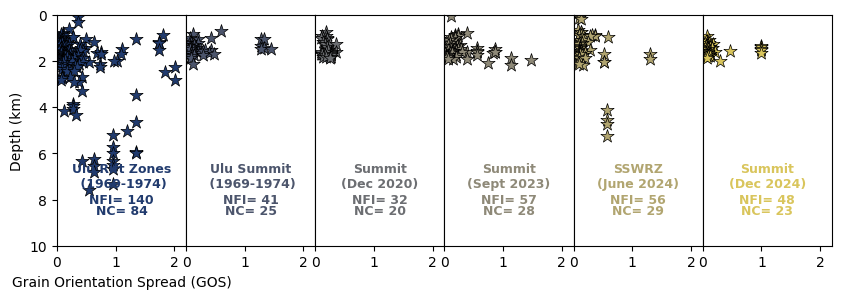

In [84]:
# Define datasets
Ulu_all=newdata[newdata['Sample'].str.contains('908|909|910|914|916|917|919|924|931')&~(newdata['SO2 mol%']>SO2_cutoff)&~(newdata['FI_type'].str.contains('S'))]
Ulu_summit=newdata[newdata['Sample'].str.contains('914|916|917|924')&~(newdata['SO2 mol%']>SO2_cutoff)&~(newdata['FI_type'].str.contains('S'))]
Ulu_rzs=newdata[newdata['Sample'].str.contains('908|909|910|931|919|920')&~(newdata['SO2 mol%']>SO2_cutoff)&~(newdata['FI_type'].str.contains('S'))]

datasets = [ Ulu_rzs,Ulu_summit,K20,K23, K24, KD24]
titles = ["Ulu Rift Zones\n (1969-1974)",
             "Ulu Summit\n (1969-1974)",
            "Summit\n(Dec 2020)",  "Summit\n(Sept 2023)", "SSWRZ\n(June 2024)","Summit\n(Dec 2024)"]

# Define the number of subplots based on datasets
num_axes = len(datasets)

# Generate colors using a seaborn color palette
annotation_colors = sns.color_palette("cividis", num_axes)  # Darker contrasting colors

# Create subplots
fig, axes = plt.subplots(1, num_axes, figsize=(10, 3), sharey=True)

# Plot data
for i, (ax, data, title, ann_color) in enumerate(zip(axes, datasets, titles, annotation_colors)):
    
    # Create violin plot
    ax.scatter(x=data['GOS'],y=data['SingleCalc_D_km'],marker='*',s=100,linewidths=0.5,edgecolors='k',color=ann_color)
    # sns.violinplot(data=data['GOS'], color=ann_color, inner='stick', ax=ax, cut=0)
    
    # Set y-axis properties
    ax.set_ylim([10,0])  # Inverted y-axis
    ax.set_xlim([0,2.2])  # Inverted y-axis
    if i == 0:
        ax.set_ylabel('Depth (km)')
        ax.set_xlabel('Grain Orientation Spread (GOS)')
    else:
        ax.yaxis.set_tick_params(left=False, labelleft=False)

    # Add title and annotation
    fontsize = 9
    ax.annotate(title, xy=(0.5, 0.30), xycoords='axes fraction', fontsize=fontsize,
                ha='center', va='center', color=ann_color, fontweight='bold', rotation=0)
    ax.annotate(f"NFI= {len(data[(data['GOS'].notna())])}", xy=(0.5, 0.20), xycoords='axes fraction', fontsize=fontsize,
                ha='center', va='center', color=ann_color, fontweight='bold', rotation=0)
    ax.annotate(f"NC= {data[(data['GOS'].notna()) & (data['Sample_crystal'].notna())]['Sample_crystal'].nunique()}", xy=(0.5, 0.15), xycoords='axes fraction', fontsize=fontsize,
                ha='center', va='center', color=ann_color, fontweight='bold', rotation=0)

# Adjust layout and save
plt.subplots_adjust(wspace=0)  # Slight spacing between plots
fig.savefig(figpath + slash + 'Pressure vs GOS_plot.pdf', format='pdf', dpi=300, transparent=False)

## Color by Fo content

## FO vs depth Ulu, EBSD as yellow dot

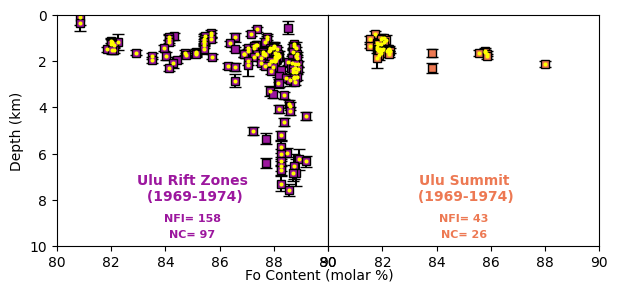

In [85]:
Ulu_all=newdata[newdata['Sample'].str.contains('908|909|910|914|916|917|919|924|931')&~(newdata['SO2 mol%']>SO2_cutoff)&~(newdata['FI_type'].str.contains('S'))]
Ulu_summit=newdata[newdata['Sample'].str.contains('914|916|917|924')&~(newdata['SO2 mol%']>SO2_cutoff)&~(newdata['FI_type'].str.contains('S'))]
Ulu_rzs=newdata[newdata['Sample'].str.contains('908|909|910|931|919|920')&~(newdata['SO2 mol%']>SO2_cutoff)&~(newdata['FI_type'].str.contains('S'))] # This rz contains SSWRZ 1974

# Define datasets
datasets = [Ulu_rzs,
            Ulu_summit]
titles = ["Ulu Rift Zones\n (1969-1974)",
          "Ulu Summit\n (1969-1974)"]

num_axes = len(datasets)
num_cols = 2#math.ceil(num_axes / 2)  # Compute number of columns for 2 rows

# Generate colors using a seaborn color palette
annotation_colors = sns.color_palette("plasma", num_axes)

# Create subplots with 3 rows
fig, axes = plt.subplots(1, num_cols, figsize=(7,3), sharey=True, sharex=True)

# Flatten axes array for easier iteration
axes = axes.flatten()

# Plot data
for i, (ax, data, title, ann_color) in enumerate(zip(axes, datasets, titles, annotation_colors)):
    
    # Determine which column to use for 'x'
    if 'May-Aug 2018' in title:
        x = data['Corrected Fo content (molar %)_Cambridge']
    else:
        # Handle cases where 'Fo_Ol' is all NaN or missing
        if 'Fo_Ol' in data.columns and not data['Fo_Ol'].dropna().empty:
            x = data['Fo_Ol']*100
        else:
            x = np.full(len(data), np.nan)  # Placeholder array of NaNs

    # Plot only if x has valid values
    
    if not all(pd.isna(x)):
        ax.errorbar(x=x, y=data['SingleCalc_D_km'], yerr=data['std_dev_MC_D_km'],
                    mec='k', mfc=ann_color, fmt='s',capsize=4,ecolor='k',zorder=-1)
    if 'GOS' in data.columns:
        gos_mask = ~data['GOS'].isna()
        ax.scatter(x[gos_mask], data.loc[gos_mask, 'SingleCalc_D_km'],
                   marker='.', color='yellow', label=None, s=15, linewidths=1,zorder=0)
    # Set axis limits
    ax.set_ylim([10, 0])  # Inverted y-axis
    ax.set_xlim([80, 90])  

    if i % num_cols == 0:
        ax.set_ylabel('Depth (km)')
    else:
        ax.yaxis.set_tick_params(left=False, labelleft=False)

    # Ensure tick marks for x-axis
    ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=(i >= num_axes - num_cols))
    
    # Add title and annotation
    fontsize = 10
    ax.annotate(title, xy=(0.5, 0.25), xycoords='axes fraction', fontsize=fontsize,
                ha='center', va='center', color=ann_color, fontweight='bold')
    
    ax.annotate(f'NFI= {len(data)}', xy=(0.5, 0.12), xycoords='axes fraction', fontsize=fontsize-2,
                ha='center', va='center', color=ann_color, fontweight='bold')

    ax.annotate(f'NC= {len(data["Sample_crystal"].unique())}', xy=(0.5, 0.05), xycoords='axes fraction', 
                fontsize=fontsize-2, ha='center', va='center', color=ann_color, fontweight='bold')

    if title =="SSWRZ\n(Dec 1974)":
        ax.fill_betweenx(y=[0, 10], x1=83.01501029514966, x2=83.84032141030799, color='grey', alpha=0.3, label='Eq ol Shea 24')
    elif title =="SSWRZ\n(June 2024)":
        ax.fill_betweenx(y=[0, 10], x1=78.86156115618836, x2=79.83991990449506, color='grey', alpha=0.3, label='Eq ol Shea 24')

# Hide empty subplots if necessary
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Adjust layout
plt.subplots_adjust(hspace=0, wspace=0)

# Add x-axis label only on the bottom row
fig.text(0.5, 0, 'Fo Content (molar %)', ha='center', fontsize=10)

# Save figure
fig.savefig(figpath + slash + 'Ulu_Fodepth_plot.pdf', format='pdf', dpi=300, transparent=False)

plt.show()

## All rift vs all summit deformation Fo depth

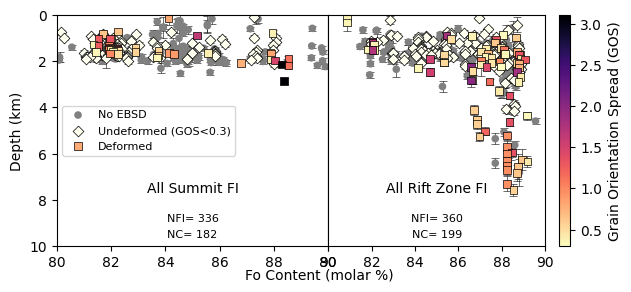

In [ ]:
mask=(~all_data_simplified['FI_type'].str.contains('T'))
datasets = [
            all_data_simplified[mask&all_data_simplified['Eruption_location_type(ERZ,VSWRZ,SSWRZ,Summit)'].str.contains("Summit")],
            all_data_simplified[mask&all_data_simplified['Eruption_location_type(ERZ,VSWRZ,SSWRZ,Summit)'].str.contains("RZ")],
            ]

titles = [
          "All Summit FI",
          "All Rift Zone FI",
          ]
num_axes = len(datasets)
num_cols = 2#math.ceil(num_axes / 2)  # Compute number of columns for 2 rows

# Generate colors using a seaborn color palette

### Color by variable
colorvar='GOS'
palette='magma_r'
global_min = 0.3
global_max = np.nanmax(all_data_simplified[mask][colorvar])
norm = plt.Normalize(vmin=global_min, vmax=global_max)

# ## Or setup a color palette
# annotation_colors = sns.color_palette("plasma", num_axes)

# Create subplots with 3 rows
fig, axes = plt.subplots(1, num_cols, figsize=(7,3), sharey=True, sharex=True)

# Flatten axes array for easier iteration
axes = axes.flatten()

# Plot data
for i, (ax, data, title) in enumerate(zip(axes, datasets, titles)):
    
    if 'Fo_Ol_%' in data.columns and not data['Fo_Ol_%'].dropna().empty:
        x = data['Fo_Ol_%']
    else:
        x = np.full(len(data), np.nan)  # Placeholder array of NaNs

    colors= np.array(plt.cm.Greens(norm(data[colorvar])))
    nan_mask = np.isnan(data[colorvar])
    colors[nan_mask] = [0, 0, 0, 0]

    # Plot only if x has valid values
    if not all(pd.isna(x)):
        ax.errorbar(x=x, y=data['SingleCalc_D_km'], yerr=data['std_dev_MC_D_km'],
                    mec='none', mfc='none', fmt='s',capsize=3,ecolor='k',zorder=-1,elinewidth=0.4,capthick=0.4)
        
    if 'GOS' in data.columns:
        gos_mask = ~data['GOS'].isna()
        gos_cutoff=data['GOS']>=0.3
        # ax.scatter(x[gos_mask], data.loc[gos_mask, 'SingleCalc_D_km'],
        #            marker='s', color=ann_color, label=None, s=15, linewidths=1,zorder=0)
        ax.scatter(x[~gos_mask], data.loc[~gos_mask, 'SingleCalc_D_km'],
                    color='grey', marker='o', label='No EBSD',alpha=1,edgecolors='none',linewidths=0.3,s=30)
        ax.scatter(x[gos_mask&~gos_cutoff], data.loc[gos_mask&~gos_cutoff, 'SingleCalc_D_km'],
                    color='ivory', marker='D', label='Undeformed (GOS<0.3)',alpha=1,edgecolors='k',linewidths=0.5,s=30)
        ax.scatter(x[gos_mask&gos_cutoff], data.loc[gos_mask&gos_cutoff, 'SingleCalc_D_km'],
                    c=data[colorvar][gos_mask&gos_cutoff], cmap=palette, norm=norm, marker='s', label='Deformed',alpha=1,edgecolors='k',linewidths=0.5,s=30)

   
    # Set axis limits
    ax.set_ylim([10, 0])  # Inverted y-axis
    ax.set_xlim([80, 90])  

    if i % num_cols == 0:
        ax.set_ylabel('Depth (km)')
    else:
        ax.yaxis.set_tick_params(left=False, labelleft=False)

    # Ensure tick marks for x-axis
    ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=(i >= num_axes - num_cols))
    
    # Add title and annotation
    fontsize = 10
    ax.annotate(title, xy=(0.5, 0.25), xycoords='axes fraction', fontsize=fontsize,
                ha='center', va='center', color='k')
    
    ax.annotate(f'NFI= {len(data)}', xy=(0.5, 0.12), xycoords='axes fraction', fontsize=fontsize-2,
                ha='center', va='center', color='k')

    ax.annotate(f'NC= {len(data["Sample_crystal"].unique())}', xy=(0.5, 0.05), xycoords='axes fraction', 
                fontsize=fontsize-2, ha='center', va='center', color='k')

    # if title =="SSWRZ\n(Dec 1974)":
    #     ax.fill_betweenx(y=[0, 10], x1=83.01501029514966, x2=83.84032141030799, color='grey', alpha=0.3, label='Eq ol Shea 24')
    # elif title =="SSWRZ\n(June 2024)":
    #     ax.fill_betweenx(y=[0, 10], x1=78.86156115618836, x2=79.83991990449506, color='grey', alpha=0.3, label='Eq ol Shea 24')

# Hide empty subplots if necessary
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

axes[0].legend(loc='center left',fontsize=8)

# Adjust layout
plt.subplots_adjust(hspace=0, wspace=0)
sm = plt.cm.ScalarMappable(cmap=palette, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes[1],orientation='vertical', label='Grain Orientation Spread (GOS)')

# Add x-axis label only on the bottom row
fig.text(0.5, 0, 'Fo Content (molar %)', ha='center', fontsize=10)

# Save figure
fig.savefig(figpath + slash + 'All_Fodepth_plot_riftvssummit.pdf', format='pdf', dpi=300, transparent=False)

plt.show()

/var/folders/r2/dcn33vbj1x1b46n5mm7vn9bc0000gn/T/ipykernel_40380/3348118975.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(loc='center left',fontsize=8)


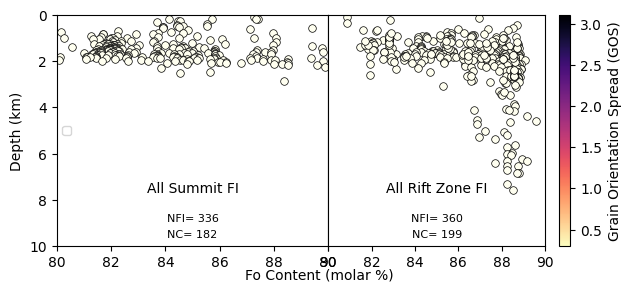

In [96]:
mask=(~all_data_simplified['FI_type'].str.contains('T'))
datasets = [
            all_data_simplified[mask&all_data_simplified['Eruption_location_type(ERZ,VSWRZ,SSWRZ,Summit)'].str.contains("Summit")],
            all_data_simplified[mask&all_data_simplified['Eruption_location_type(ERZ,VSWRZ,SSWRZ,Summit)'].str.contains("RZ")],
            ]

titles = [
          "All Summit FI",
          "All Rift Zone FI",
          ]
num_axes = len(datasets)
num_cols = 2#math.ceil(num_axes / 2)  # Compute number of columns for 2 rows

# Generate colors using a seaborn color palette

### Color by variable
colorvar='GOS'
palette='magma_r'
global_min = 0.3
global_max = np.nanmax(all_data_simplified[mask][colorvar])
norm = plt.Normalize(vmin=global_min, vmax=global_max)

# ## Or setup a color palette
# annotation_colors = sns.color_palette("plasma", num_axes)

# Create subplots with 3 rows
fig, axes = plt.subplots(1, num_cols, figsize=(7,3), sharey=True, sharex=True)

# Flatten axes array for easier iteration
axes = axes.flatten()

# Plot data
for i, (ax, data, title) in enumerate(zip(axes, datasets, titles)):
    
    if 'Fo_Ol_%' in data.columns and not data['Fo_Ol_%'].dropna().empty:
        x = data['Fo_Ol_%']
    else:
        x = np.full(len(data), np.nan)  # Placeholder array of NaNs

    colors= np.array(plt.cm.Greens(norm(data[colorvar])))
    nan_mask = np.isnan(data[colorvar])
    colors[nan_mask] = [0, 0, 0, 0]

    # # Plot only if x has valid values
    # if not all(pd.isna(x)):
    #     ax.errorbar(x=x, y=data['SingleCalc_D_km'], yerr=data['std_dev_MC_D_km'],
    #                 mec='none', mfc='none', fmt='s',capsize=3,ecolor='k',zorder=-1,elinewidth=0.4,capthick=0.4)
        
    if 'GOS' in data.columns:
        gos_mask = ~data['GOS'].isna()
        gos_cutoff=data['GOS']>=0.3
    

        ax.scatter(x, data['SingleCalc_D_km'],
                    color='ivory', marker='o',alpha=1,edgecolors='k',linewidths=0.5,s=30)

   
    # Set axis limits
    ax.set_ylim([10, 0])  # Inverted y-axis
    ax.set_xlim([80, 90])  

    if i % num_cols == 0:
        ax.set_ylabel('Depth (km)')
    else:
        ax.yaxis.set_tick_params(left=False, labelleft=False)

    # Ensure tick marks for x-axis
    ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=(i >= num_axes - num_cols))
    
    # Add title and annotation
    fontsize = 10
    ax.annotate(title, xy=(0.5, 0.25), xycoords='axes fraction', fontsize=fontsize,
                ha='center', va='center', color='k')
    
    ax.annotate(f'NFI= {len(data)}', xy=(0.5, 0.12), xycoords='axes fraction', fontsize=fontsize-2,
                ha='center', va='center', color='k')

    ax.annotate(f'NC= {len(data["Sample_crystal"].unique())}', xy=(0.5, 0.05), xycoords='axes fraction', 
                fontsize=fontsize-2, ha='center', va='center', color='k')

    # if title =="SSWRZ\n(Dec 1974)":
    #     ax.fill_betweenx(y=[0, 10], x1=83.01501029514966, x2=83.84032141030799, color='grey', alpha=0.3, label='Eq ol Shea 24')
    # elif title =="SSWRZ\n(June 2024)":
    #     ax.fill_betweenx(y=[0, 10], x1=78.86156115618836, x2=79.83991990449506, color='grey', alpha=0.3, label='Eq ol Shea 24')

# Hide empty subplots if necessary
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

axes[0].legend(loc='center left',fontsize=8)

# Adjust layout
plt.subplots_adjust(hspace=0, wspace=0)
sm = plt.cm.ScalarMappable(cmap=palette, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes[1],orientation='vertical', label='Grain Orientation Spread (GOS)')

# Add x-axis label only on the bottom row
fig.text(0.5, 0, 'Fo Content (molar %)', ha='center', fontsize=10)

# Save figure
fig.savefig(figpath + slash + 'All_Fodepth_plot_riftvssummit.pdf', format='pdf', dpi=300, transparent=False)

plt.show()

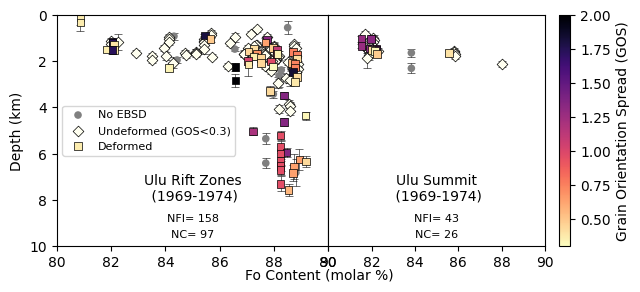

In [69]:
Ulu_all=newdata[newdata['Sample'].str.contains('908|909|910|914|916|917|919|924|931')&~(newdata['SO2 mol%']>SO2_cutoff)&~(newdata['FI_type'].str.contains('S'))]
Ulu_summit=newdata[newdata['Sample'].str.contains('914|916|917|924')&~(newdata['SO2 mol%']>SO2_cutoff)&~(newdata['FI_type'].str.contains('S'))]
Ulu_rzs=newdata[newdata['Sample'].str.contains('908|909|910|931|919|920')&~(newdata['SO2 mol%']>SO2_cutoff)&~(newdata['FI_type'].str.contains('S'))] # This rz contains SSWRZ 1974

# Define datasets
datasets = [Ulu_rzs,
            Ulu_summit]
titles = ["Ulu Rift Zones\n (1969-1974)",
          "Ulu Summit\n (1969-1974)"]

num_axes = len(datasets)
num_cols = 2#math.ceil(num_axes / 2)  # Compute number of columns for 2 rows

# Generate colors using a seaborn color palette

### Color by variable
colorvar='GOS'
palette='magma_r'
global_min = 0.3
global_max = np.nanmax(Ulu_all[colorvar])
norm = plt.Normalize(vmin=global_min, vmax=global_max)

# ## Or setup a color palette
# annotation_colors = sns.color_palette("plasma", num_axes)

# Create subplots with 3 rows
fig, axes = plt.subplots(1, num_cols, figsize=(7,3), sharey=True, sharex=True)

# Flatten axes array for easier iteration
axes = axes.flatten()

# Plot data
for i, (ax, data, title) in enumerate(zip(axes, datasets, titles)):
    
    # Determine which column to use for 'x'
    if 'May-Aug 2018' in title:
        x = data['Corrected Fo content (molar %)_Cambridge']
    else:
        # Handle cases where 'Fo_Ol' is all NaN or missing
        if 'Fo_Ol' in data.columns and not data['Fo_Ol'].dropna().empty:
            x = data['Fo_Ol']*100
        else:
            x = np.full(len(data), np.nan)  # Placeholder array of NaNs

    colors= np.array(plt.cm.Greens(norm(data[colorvar])))
    nan_mask = np.isnan(data[colorvar])
    colors[nan_mask] = [0, 0, 0, 0]

    # Plot only if x has valid values
    if not all(pd.isna(x)):
        ax.errorbar(x=x, y=data['SingleCalc_D_km'], yerr=data['std_dev_MC_D_km'],
                    mec='none', mfc='none', fmt='s',capsize=3,ecolor='k',zorder=-1,elinewidth=0.4,capthick=0.4)
        
    if 'GOS' in data.columns:
        gos_mask = ~data['GOS'].isna()
        gos_cutoff=data['GOS']>=0.3
        # ax.scatter(x[gos_mask], data.loc[gos_mask, 'SingleCalc_D_km'],
        #            marker='s', color=ann_color, label=None, s=15, linewidths=1,zorder=0)
        ax.scatter(x[~gos_mask], data.loc[~gos_mask, 'SingleCalc_D_km'],
                    color='grey', marker='o', label='No EBSD',alpha=1,edgecolors='none',linewidths=0.3,s=30)
        ax.scatter(x[gos_mask&~gos_cutoff], data.loc[gos_mask&~gos_cutoff, 'SingleCalc_D_km'],
                    color='ivory', marker='D', label='Undeformed (GOS<0.3)',alpha=1,edgecolors='k',linewidths=0.5,s=30)
        ax.scatter(x[gos_mask&gos_cutoff], data.loc[gos_mask&gos_cutoff, 'SingleCalc_D_km'],
                    c=data[colorvar][gos_mask&gos_cutoff], cmap=palette, norm=norm, marker='s', label='Deformed',alpha=1,edgecolors='k',linewidths=0.5,s=30)

   
    # Set axis limits
    ax.set_ylim([10, 0])  # Inverted y-axis
    ax.set_xlim([80, 90])  

    if i % num_cols == 0:
        ax.set_ylabel('Depth (km)')
    else:
        ax.yaxis.set_tick_params(left=False, labelleft=False)

    # Ensure tick marks for x-axis
    ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=(i >= num_axes - num_cols))
    
    # Add title and annotation
    fontsize = 10
    ax.annotate(title, xy=(0.5, 0.25), xycoords='axes fraction', fontsize=fontsize,
                ha='center', va='center', color='k')
    
    ax.annotate(f'NFI= {len(data)}', xy=(0.5, 0.12), xycoords='axes fraction', fontsize=fontsize-2,
                ha='center', va='center', color='k')

    ax.annotate(f'NC= {len(data["Sample_crystal"].unique())}', xy=(0.5, 0.05), xycoords='axes fraction', 
                fontsize=fontsize-2, ha='center', va='center', color='k')

    # if title =="SSWRZ\n(Dec 1974)":
    #     ax.fill_betweenx(y=[0, 10], x1=83.01501029514966, x2=83.84032141030799, color='grey', alpha=0.3, label='Eq ol Shea 24')
    # elif title =="SSWRZ\n(June 2024)":
    #     ax.fill_betweenx(y=[0, 10], x1=78.86156115618836, x2=79.83991990449506, color='grey', alpha=0.3, label='Eq ol Shea 24')

# Hide empty subplots if necessary
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

axes[0].legend(loc='center left',fontsize=8)

# Adjust layout
plt.subplots_adjust(hspace=0, wspace=0)
sm = plt.cm.ScalarMappable(cmap=palette, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes[1],orientation='vertical', label='Grain Orientation Spread (GOS)')

# Add x-axis label only on the bottom row
fig.text(0.5, 0, 'Fo Content (molar %)', ha='center', fontsize=10)

# Save figure
fig.savefig(figpath + slash + 'Ulu_Fodepth_plot.pdf', format='pdf', dpi=300, transparent=False)

plt.show()

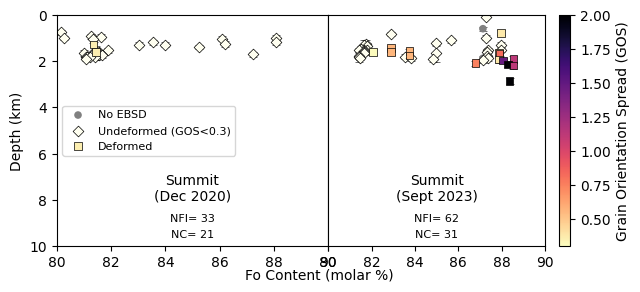

In [70]:
# Define datasets
datasets = [K20,K23]#,K24,KD24]
titles = ["Summit\n(Dec 2020)",  "Summit\n(Sept 2023)"]#, "SSWRZ\n(June 2024)","Summit\n(Dec 2024)"]
            # "Summit\n(Dec 2020)",  "Summit\n(Sept 2023)", "SSWRZ\n(June 2024)","Summit\n(Dec 2024)"]
num_axes = len(datasets)
num_cols = 2#math.ceil(num_axes / 2)  # Compute number of columns for 2 rows

# Generate colors using a seaborn color palette

### Color by variable
colorvar='GOS'
palette='magma_r'
global_min = 0.3
global_max = np.nanmax(Ulu_all[colorvar])
norm = plt.Normalize(vmin=global_min, vmax=global_max)

# ## Or setup a color palette
# annotation_colors = sns.color_palette("plasma", num_axes)

# Create subplots with 3 rows
fig, axes = plt.subplots(1, num_cols, figsize=(7,3), sharey=True, sharex=True)

# Flatten axes array for easier iteration
axes = axes.flatten()

# Plot data
for i, (ax, data, title) in enumerate(zip(axes, datasets, titles)):
    
    # Determine which column to use for 'x'
    if 'May-Aug 2018' in title:
        x = data['Corrected Fo content (molar %)_Cambridge']
    else:
        # Handle cases where 'Fo_Ol' is all NaN or missing
        if 'Fo_Ol' in data.columns and not data['Fo_Ol'].dropna().empty:
            x = data['Fo_Ol']*100
        else:
            x = np.full(len(data), np.nan)  # Placeholder array of NaNs

    colors= np.array(plt.cm.Greens(norm(data[colorvar])))
    nan_mask = np.isnan(data[colorvar])
    colors[nan_mask] = [0, 0, 0, 0]

    # Plot only if x has valid values
    if not all(pd.isna(x)):
        ax.errorbar(x=x, y=data['SingleCalc_D_km'], yerr=data['std_dev_MC_D_km'],
                    mec='none', mfc='none', fmt='s',capsize=3,ecolor='k',zorder=-1,elinewidth=0.4,capthick=0.4)
        
    if 'GOS' in data.columns:
        gos_mask = ~data['GOS'].isna()
        gos_cutoff=data['GOS']>=0.3
        # ax.scatter(x[gos_mask], data.loc[gos_mask, 'SingleCalc_D_km'],
        #            marker='s', color=ann_color, label=None, s=15, linewidths=1,zorder=0)
        ax.scatter(x[~gos_mask], data.loc[~gos_mask, 'SingleCalc_D_km'],
                    color='grey', marker='o', label='No EBSD',alpha=1,edgecolors='none',linewidths=0.3,s=30)
        ax.scatter(x[gos_mask&~gos_cutoff], data.loc[gos_mask&~gos_cutoff, 'SingleCalc_D_km'],
                    color='ivory', marker='D', label='Undeformed (GOS<0.3)',alpha=1,edgecolors='k',linewidths=0.5,s=30)
        ax.scatter(x[gos_mask&gos_cutoff], data.loc[gos_mask&gos_cutoff, 'SingleCalc_D_km'],
                    c=data[colorvar][gos_mask&gos_cutoff], cmap=palette, norm=norm, marker='s', label='Deformed',alpha=1,edgecolors='k',linewidths=0.5,s=30)

   
    # Set axis limits
    ax.set_ylim([10, 0])  # Inverted y-axis
    ax.set_xlim([80, 90])  

    if i % num_cols == 0:
        ax.set_ylabel('Depth (km)')
    else:
        ax.yaxis.set_tick_params(left=False, labelleft=False)

    # Ensure tick marks for x-axis
    ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=(i >= num_axes - num_cols))
    
    # Add title and annotation
    fontsize = 10
    ax.annotate(title, xy=(0.5, 0.25), xycoords='axes fraction', fontsize=fontsize,
                ha='center', va='center', color='k')
    
    ax.annotate(f'NFI= {len(data)}', xy=(0.5, 0.12), xycoords='axes fraction', fontsize=fontsize-2,
                ha='center', va='center', color='k')

    ax.annotate(f'NC= {len(data["Sample_crystal"].unique())}', xy=(0.5, 0.05), xycoords='axes fraction', 
                fontsize=fontsize-2, ha='center', va='center', color='k')

    # if title =="SSWRZ\n(Dec 1974)":
    #     ax.fill_betweenx(y=[0, 10], x1=83.01501029514966, x2=83.84032141030799, color='grey', alpha=0.3, label='Eq ol Shea 24')
    # elif title =="SSWRZ\n(June 2024)":
    #     ax.fill_betweenx(y=[0, 10], x1=78.86156115618836, x2=79.83991990449506, color='grey', alpha=0.3, label='Eq ol Shea 24')

# Hide empty subplots if necessary
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

axes[0].legend(loc='center left',fontsize=8)

# Adjust layout
plt.subplots_adjust(hspace=0, wspace=0)
sm = plt.cm.ScalarMappable(cmap=palette, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes[1],orientation='vertical', label='Grain Orientation Spread (GOS)')

# Add x-axis label only on the bottom row
fig.text(0.5, 0, 'Fo Content (molar %)', ha='center', fontsize=10)

# Save figure
fig.savefig(figpath + slash + 'K20_K23_Fodepth_plot.pdf', format='pdf', dpi=300, transparent=False)

plt.show()

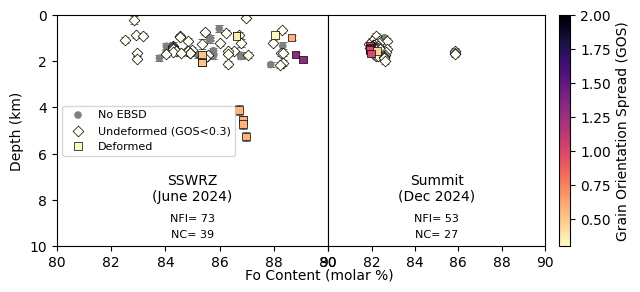

In [71]:
# Define datasets
datasets = [K24,KD24]
titles = ["SSWRZ\n(June 2024)","Summit\n(Dec 2024)"]
            # "Summit\n(Dec 2020)",  "Summit\n(Sept 2023)", "SSWRZ\n(June 2024)","Summit\n(Dec 2024)"]
num_axes = len(datasets)
num_cols = 2#math.ceil(num_axes / 2)  # Compute number of columns for 2 rows

# Generate colors using a seaborn color palette

### Color by variable
colorvar='GOS'
palette='magma_r'
global_min = 0.3
global_max = np.nanmax(Ulu_all[colorvar])
norm = plt.Normalize(vmin=global_min, vmax=global_max)

# ## Or setup a color palette
# annotation_colors = sns.color_palette("plasma", num_axes)

# Create subplots with 3 rows
fig, axes = plt.subplots(1, num_cols, figsize=(7,3), sharey=True, sharex=True)

# Flatten axes array for easier iteration
axes = axes.flatten()

# Plot data
for i, (ax, data, title) in enumerate(zip(axes, datasets, titles)):
    
    # Determine which column to use for 'x'
    if 'May-Aug 2018' in title:
        x = data['Corrected Fo content (molar %)_Cambridge']
    else:
        # Handle cases where 'Fo_Ol' is all NaN or missing
        if 'Fo_Ol' in data.columns and not data['Fo_Ol'].dropna().empty:
            x = data['Fo_Ol']*100
        else:
            x = np.full(len(data), np.nan)  # Placeholder array of NaNs

    colors= np.array(plt.cm.Greens(norm(data[colorvar])))
    nan_mask = np.isnan(data[colorvar])
    colors[nan_mask] = [0, 0, 0, 0]

    # Plot only if x has valid values
    if not all(pd.isna(x)):
        ax.errorbar(x=x, y=data['SingleCalc_D_km'], yerr=data['std_dev_MC_D_km'],
                    mec='none', mfc='none', fmt='s',capsize=3,ecolor='k',zorder=-1,elinewidth=0.4,capthick=0.4)
        
    if 'GOS' in data.columns:
        gos_mask = ~data['GOS'].isna()
        gos_cutoff=data['GOS']>=0.3
        # ax.scatter(x[gos_mask], data.loc[gos_mask, 'SingleCalc_D_km'],
        #            marker='s', color=ann_color, label=None, s=15, linewidths=1,zorder=0)
        ax.scatter(x[~gos_mask], data.loc[~gos_mask, 'SingleCalc_D_km'],
                    color='grey', marker='o', label='No EBSD',alpha=1,edgecolors='none',linewidths=0.3,s=30)
        ax.scatter(x[gos_mask&~gos_cutoff], data.loc[gos_mask&~gos_cutoff, 'SingleCalc_D_km'],
                    color='ivory', marker='D', label='Undeformed (GOS<0.3)',alpha=1,edgecolors='k',linewidths=0.5,s=30)
        ax.scatter(x[gos_mask&gos_cutoff], data.loc[gos_mask&gos_cutoff, 'SingleCalc_D_km'],
                    c=data[colorvar][gos_mask&gos_cutoff], cmap=palette, norm=norm, marker='s', label='Deformed',alpha=1,edgecolors='k',linewidths=0.5,s=30)

   
    # Set axis limits
    ax.set_ylim([10, 0])  # Inverted y-axis
    ax.set_xlim([80, 90])  

    if i % num_cols == 0:
        ax.set_ylabel('Depth (km)')
    else:
        ax.yaxis.set_tick_params(left=False, labelleft=False)

    # Ensure tick marks for x-axis
    ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=(i >= num_axes - num_cols))
    
    # Add title and annotation
    fontsize = 10
    ax.annotate(title, xy=(0.5, 0.25), xycoords='axes fraction', fontsize=fontsize,
                ha='center', va='center', color='k')
    
    ax.annotate(f'NFI= {len(data)}', xy=(0.5, 0.12), xycoords='axes fraction', fontsize=fontsize-2,
                ha='center', va='center', color='k')

    ax.annotate(f'NC= {len(data["Sample_crystal"].unique())}', xy=(0.5, 0.05), xycoords='axes fraction', 
                fontsize=fontsize-2, ha='center', va='center', color='k')

    # if title =="SSWRZ\n(Dec 1974)":
    #     ax.fill_betweenx(y=[0, 10], x1=83.01501029514966, x2=83.84032141030799, color='grey', alpha=0.3, label='Eq ol Shea 24')
    # elif title =="SSWRZ\n(June 2024)":
    #     ax.fill_betweenx(y=[0, 10], x1=78.86156115618836, x2=79.83991990449506, color='grey', alpha=0.3, label='Eq ol Shea 24')

# Hide empty subplots if necessary
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

axes[0].legend(loc='center left',fontsize=8)

# Adjust layout
plt.subplots_adjust(hspace=0, wspace=0)
sm = plt.cm.ScalarMappable(cmap=palette, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes[1],orientation='vertical', label='Grain Orientation Spread (GOS)')

# Add x-axis label only on the bottom row
fig.text(0.5, 0, 'Fo Content (molar %)', ha='center', fontsize=10)

# Save figure
fig.savefig(figpath + slash + 'K24_KD24_Fodepth_plot.pdf', format='pdf', dpi=300, transparent=False)

plt.show()

# Let'plot all of the EBSD regardless whether it has FI or not

In [ ]:

K20_EBSD_all=pd.read_excel('/Users/cljd/pCloud Drive/WORK-GENERAL/POSTDOC-UCB/BERKELEY-VIBE/Documents/Projects/PrePostCaldera_Kil2025/Github_repo/Data/Data_KS20-527/EBSD/Combined_EBSD/EBSD_combined_all.xlsx')
KD24_EBSD_all=pd.read_excel('/Users/cljd/pCloud Drive/WORK-GENERAL/POSTDOC-UCB/BERKELEY-VIBE/Documents/Projects/PrePostCaldera_Kil2025/Github_repo/Data/Data_KS24-628/EBSD/Combined_EBSD/EBSD_combined_all.xlsx')
Ulu_mounts_EBSD_all=pd.read_excel('/Users/cljd/pCloud Drive/WORK-GENERAL/POSTDOC-UCB/BERKELEY-VIBE/Documents/Projects/PrePostCaldera_Kil2025/Github_repo/Data/Data_Ulu_mounts/EBSD/Combined_EBSD/Ulu_EBSD_combined_all.xlsx')

SWRZ_EBSD_all=pd.read_excel('/Users/cljd/pCloud Drive/WORK-GENERAL/POSTDOC-UCB/BERKELEY-VIBE/Documents/Projects/PrePostCaldera_Kil2025/Github_repo/Data/Data_SWRZ/EBSD/Combined_EBSD/EBSD_combined_all.xlsx')
K24_EBSD_all=SWRZ_EBSD_all[SWRZ_EBSD_all['EBSD_name'].str.contains('K24')]
KL0919_EBSD_all=SWRZ_EBSD_all[SWRZ_EBSD_all['EBSD_name'].str.contains('919')]
Ulu_EBSD_all=pd.concat([Ulu_mounts_EBSD_all,KL0919_EBSD_all])

EBSD_data1=pd.read_excel(MasterFolder +slash+"Data_processing_notebooks"+slash+'Data_reprocessing_Literature'+slash+'Data_Lit'+slash+'K23_EBSDmap'+slash+'K23_wholemount_052225 (montaged map)_grain_results.xlsx')
EBSD_data2=pd.read_excel(MasterFolder +slash+"Data_processing_notebooks"+slash+'Data_reprocessing_Literature'+slash+'Data_Lit'+slash+'K23_EBSDmap'+slash+"K23_manual_map_day"+slash+'K23_1_grain_results.xlsx')
K23_EBSD_all=pd.concat([EBSD_data1,EBSD_data2])



,Unnamed: 0,Filename,Deformed,Slip_system,Blue_direction,Red_direction,Notes,Day,grainID,GOS,...,len20,file_mod,mean_length,median_length,Perc Tilt,Perc Twist,Perc unclassified,EBSD_name,EBSDname+grainID,Divangle
0,0.0,\Expl_600,Y,Y,SE,NE,0,100,80,1.413278,...,0.0,\Expl_600,195.100778,157.160961,NaN,NaN,NaN,NaN,NaN,NaN
1,1.0,\Expl_601,N,0,0,0,0,100,20,0.126191,...,0.0,0,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
2,2.0,\Expl_601,N,0,0,0,0,100,2,0.180567,...,0.0,0,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
3,3.0,\Expl_601,Y,Y,E,0,0,100,62,0.798379,...,0.0,\Expl_601,158.124051,130.973873,NaN,NaN,NaN,NaN,NaN,NaN
4,4.0,\Expl_602,M,0,0,0,0,100,33,0.355086,...,0.0,0,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
182,NaN,\Rapid_response_day2 Specimen 1 919_67_5,Y,NaN,NaN,NaN,NaN,2,15,0.593880,...,NaN,NaN,NaN,NaN,99.487346,0.000000,5.126542e-01,919_67_5,919_67_5_15,1.0
183,NaN,\Rapid_response_day2 Specimen 1 919_67_5,Y,NaN,NaN,NaN,NaN,2,53,0.504836,...,NaN,NaN,NaN,NaN,67.408576,17.483124,1.510830e+01,919_67_5,919_67_5_53,1.0
184,NaN,\Rapid_response_day2 Specimen 1 919_67_5,Uncertain,NaN,NaN,NaN,NaN,2,57,0.092402,...,NaN,NaN,NaN,NaN,100.000000,0.000000,0.000000e+00,919_67_5,919_67_5_57,1.0
185,NaN,\Rapid_response_day2 Specimen 1 919_68_6,Uncertain,NaN,NaN,NaN,NaN,2,17,0.142322,...,NaN,NaN,NaN,NaN,65.649225,34.350775,4.141305e-15,919_68_6,919_68_6_17,2.0


In [ ]:
titles = ["Sand Hill\n(1840)", 
          "Mauna Iki VSWRZ\n(1919-1920)",
          "Ulu Rift Zones\n (1969-1974)",
          "SSWRZ\n(Dec 1974)",
          "LERZ\n(May-Aug 2018)", 
          "SSWRZ\n(June 2024)",
          "Kulanaokuaiki \n(400-650)", "Circ. flow\n(~1700)",
          "Ulu Summit\n (1969-1974)","Summit\n(Dec 2020)", "Summit\n(Sept 2023)", "Summit\n(Dec 2024)" ]


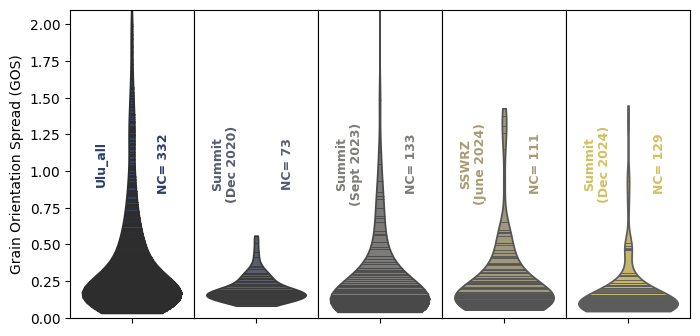

In [83]:
# Define datasets

datasets = [Ulu_EBSD_all,K20_EBSD_all,K23_EBSD_all,K24_EBSD_all,KD24_EBSD_all]
titles = ["Ulu_all","Summit\n(Dec 2020)","Summit\n(Sept 2023)","SSWRZ\n(June 2024)","Summit\n(Dec 2024)"]

# Define the number of subplots based on datasets
num_axes = len(datasets)

# Generate colors using a seaborn color palette
annotation_colors = sns.color_palette("cividis", num_axes)  # Darker contrasting colors

# Create subplots
fig, axes = plt.subplots(1, num_axes, figsize=(8, 4), sharey=True)

# Plot data
for i, (ax, data, title, ann_color) in enumerate(zip(axes, datasets, titles, annotation_colors)):
    
    # Create violin plot
    sns.violinplot(data=data['GOS'], color=ann_color, inner='stick', ax=ax, cut=0)
    
    # Set y-axis properties
    ax.set_ylim([0,2.1])  # Inverted y-axis
    if i == 0:
        ax.set_ylabel('Grain Orientation Spread (GOS)')
    else:
        ax.yaxis.set_tick_params(left=False, labelleft=False)
    
    # Add title and annotation
    fontsize = 9
    ax.annotate(title, xy=(0.25, 0.5), xycoords='axes fraction', fontsize=fontsize,
                ha='center', va='center', color=ann_color, fontweight='bold', rotation=90)
    ax.annotate(f"NC= {data[(data['GOS'].notna()) & (data['grainID'].notna())]['grainID'].nunique()}",
                xy=(0.75, 0.5), xycoords='axes fraction', fontsize=fontsize,
                ha='center', va='center', color=ann_color, fontweight='bold', rotation=90)

# Adjust layout and save
plt.subplots_adjust(wspace=0)  # Slight spacing between plots
fig.savefig(figpath + slash + 'GOS_violin_plot_K20_allEBSD.pdf', format='pdf', dpi=300, transparent=False)


In [ ]:
K23

## Import Kendra unpubd olivines

In [97]:
KD24_ols_Kendra=pd.read_excel(MasterFolder+slash+"Data"+slash+"Unpubd data from Kendra"+slash+"December2024HMM_Diffusion_Master_01142025.xlsx",sheet_name="CoreRim Master")

KD24_ols_Kendra =KD24_ols_Kendra.loc[:, ~KD24_ols_Kendra.columns.str.contains('Unnamed')].drop(KD24_ols_Kendra.tail(6).index)

KD24_ols_Kendra

,SAMPLE,SiO2 WT%,MgO WT%,FeO WT%,NiO WT%,CaO WT%,Total,Fo
0,KS24-617-WORI-1_ol1 Ave,39.484433,42.966033,16.818300,0.220630,0.252090,99.741487,81.994967
1,KS24-617-WORI-1_ol2 Ave,39.434500,43.270000,16.375867,0.230100,0.260377,99.570844,82.487267
2,KS24-617-WORI-1_ol3 Ave,39.454500,43.056700,16.785067,0.213760,0.263652,99.773679,82.055200
3,KS24-617-WORI-1_ol4 Ave,39.609700,43.774300,16.067400,0.240889,0.259273,99.951562,82.924867
4,KS24-617-WORI-1_ol5 Ave,39.827767,43.399333,16.089133,0.238321,0.259320,99.813874,82.783567
5,KS24-617-WORI-1_ol6 Ave,40.019867,43.167267,16.528433,0.209049,0.257977,100.182593,82.318333
6,KS24-617-WORI-1_ol7 Ave,39.756800,43.206733,16.186600,0.240085,0.262180,99.652399,82.633567
7,KS24-617-WORI-1_ol8 Ave,39.803033,42.790733,16.536900,0.236558,0.264095,99.631320,82.182900
8,KS24-617-WORI-1_ol9 Ave,39.686100,43.112600,16.428300,0.238447,0.256796,99.722243,82.388200
9,KS24-617-WORI-1_ol10 Ave,39.918667,43.145633,16.432300,0.224824,0.279385,100.000808,82.395733


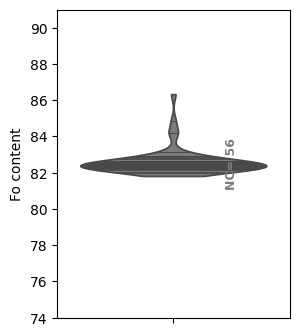

In [98]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define datasets
datasets = [KD24_ols_Kendra]  # Can have more datasets, but for now let's assume one
titles = ["SWRZ\n(Dec 1974)"]

# Define the number of subplots based on datasets
num_axes = len(datasets)

# Generate colors using a seaborn color palette
annotation_colors = sns.color_palette("cividis", num_axes)  # Darker contrasting colors

# Create subplots
fig, axes = plt.subplots(1, num_axes, figsize=(3, 4), sharey=True)

# If there's only one axis, make it iterable (like a list)
if num_axes == 1:
    axes = [axes]

# Plot data
for i, (ax, data, title, ann_color) in enumerate(zip(axes, datasets, titles, annotation_colors)):
    
    # Create violin plot
    sns.violinplot(data=data['Fo'], color=ann_color, inner='stick', ax=ax, cut=0)
    
    # Set y-axis properties
    ax.set_ylim([0, 2.1])  # Inverted y-axis
    if i == 0:
        ax.set_ylabel('Fo content')
    else:
        ax.yaxis.set_tick_params(left=False, labelleft=False)
    
    # Add title and annotation
    fontsize = 9
    # ax.annotate(title, xy=(0.25, 0.5), xycoords='axes fraction', fontsize=fontsize,
    #             ha='center', va='center', color=ann_color, fontweight='bold', rotation=90)
    ax.annotate(f"NC= {len(data[(data['Fo'].notna())])}",
                xy=(0.75, 0.5), xycoords='axes fraction', fontsize=fontsize,
                ha='center', va='center', color=ann_color, fontweight='bold', rotation=90)

# Adjust layout and save
plt.subplots_adjust(wspace=0)  # Slight spacing between plots

# Optionally set xlim
ax.set_ylim([74, 91])
fig.savefig(figpath + slash + 'Dec24_Kendra_Ol_violin_plot.pdf', format='pdf', dpi=300, transparent=False)


In [99]:
KD24_ols_profiles_Kendra=pd.read_excel(MasterFolder+slash+"Data"+slash+"Unpubd data from Kendra"+slash+"December2024HMM_Diffusion_Master_01142025.xlsx",sheet_name="ol33")

KD24_ols_profiles_Kendra =KD24_ols_profiles_Kendra.loc[:, ~KD24_ols_profiles_Kendra.columns.str.contains('Unnamed')].dropna(how='all')#.drop(KD24_ols_profiles_Kendra.tail(6).index)

KD24_ols_profiles_Kendra

,SAMPLE,SiO2 WT%,MgO WT%,FeO WT%,NiO WT%,CaO WT%,Total,Fo,RELDIST
0,Un 39 KS24-617-WORI-1_ol33_trav1,40.4104,43.8189,16.3836,0.219932,0.288659,101.121491,82.6618,0.00000
1,Un 39 KS24-617-WORI-1_ol33_trav1,40.3005,43.5617,16.3846,0.216461,0.275291,100.738552,82.5764,9.96572
2,Un 39 KS24-617-WORI-1_ol33_trav1,40.3067,43.7030,16.3504,0.225529,0.271164,100.856793,82.6530,20.00900
3,Un 39 KS24-617-WORI-1_ol33_trav1,40.1169,43.6395,16.2488,0.233582,0.268351,100.507133,82.7213,29.97470
4,Un 39 KS24-617-WORI-1_ol33_trav1,40.0354,43.6762,16.3202,0.231534,0.264374,100.527708,82.6706,40.01800
...,...,...,...,...,...,...,...,...,...
69,Un 40 KS24-617-WORI-1_ol33_trav2,40.5088,46.9187,11.3501,0.376798,0.219803,99.374201,88.0509,280.00200
70,Un 40 KS24-617-WORI-1_ol33_trav2,40.5091,46.9056,11.3925,0.391807,0.218019,99.417026,88.0086,290.05600
71,Un 40 KS24-617-WORI-1_ol33_trav2,40.6610,46.9752,11.3996,0.378683,0.217764,99.632247,88.0177,300.00100
72,Un 40 KS24-617-WORI-1_ol33_trav2,40.6881,47.3479,11.4504,0.377036,0.219624,100.083060,88.0541,310.04800


In [100]:
KD24_ols_profiles_Kendra.columns.to_list()

['  SAMPLE',
 'SiO2 WT%',
 ' MgO WT%',
 ' FeO WT%',
 ' NiO WT%',
 ' CaO WT%',
 'Total',
 'Fo',
 ' RELDIST']

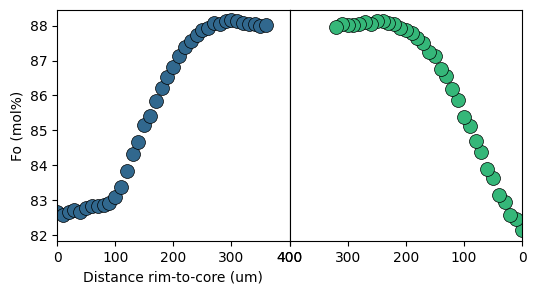

In [101]:
# Define datasets
datasets = [KD24_ols_profiles_Kendra[KD24_ols_profiles_Kendra['  SAMPLE'].str.contains("trav1")],KD24_ols_profiles_Kendra[KD24_ols_profiles_Kendra['  SAMPLE'].str.contains("trav2")]]
titles = ["Traverse 1", 
          "Traverse 2"]

# Define the number of subplots based on datasets
num_axes = len(datasets)

# Generate colors using a seaborn color palette
annotation_colors = sns.color_palette("viridis", num_axes)  # Darker contrasting colors

# Create subplots
fig, axes = plt.subplots(1, num_axes, figsize=(6, 3), sharey=True)

# Plot data
for i, (ax, data, title, ann_color) in enumerate(zip(axes, datasets, titles, annotation_colors)):
    
    # Create violin plot
    ax.scatter(x=data[' RELDIST'],y=data['Fo'],marker='o',s=100,linewidths=0.5,edgecolors='k',color=ann_color)
    # sns.violinplot(data=data['GOS'], color=ann_color, inner='stick', ax=ax, cut=0)
    
    # # Set y-axis properties
    # ax.set_ylim([10,0])  # Inverted y-axis
  # Inverted y-axis
    if i == 0:
        ax.set_xlabel('Distance rim-to-core (um)')
        ax.set_ylabel('Fo (mol%)')
        ax.set_xlim([0,400])
    else:
        ax.yaxis.set_tick_params(left=False, labelleft=False)
        ax.set_xlim([400,0])

    
    # Add title and annotation
    fontsize = 9

# Adjust layout and save
plt.subplots_adjust(wspace=0)  # Slight spacing between plots
fig.savefig(figpath + slash + 'Ol33_Dec24_profile.pdf', format='pdf', dpi=300, transparent=False)


In [102]:
K24_ols_profiles_Kendra=pd.read_excel(MasterFolder+slash+"Data"+slash+"Unpubd data from Kendra"+slash+"3087-1_Lynn_2020Kilauea_DataTables_01122024.xlsx",sheet_name="Ol 2",skiprows=2)

K24_ols_profiles_Kendra =K24_ols_profiles_Kendra.loc[:, ~K24_ols_profiles_Kendra.columns.str.contains('Unnamed')].dropna(how='all')#.drop(K24_ols_profiles_Kendra.tail(6).index)

# K24_ols_profiles_Kendra=K24_ols_profiles_Kendra[K24_ols_profiles_Kendra['Valid']==1]
K24_ols_profiles_Kendra

,SAMPLE,Distance (μm),SiO2,FeO,MgO,CaO,MnO,NiO,Total,Fo,Initial,Model
0,KS20-527_2-transect,300.8810,39.9520,11.2012,48.1396,0.216475,0.130430,0.397643,100.037348,88.4540,88.5,88.5000
1,KS20-527_2-transect,290.9940,39.7974,11.1398,47.9763,0.216333,0.134179,0.396817,99.660829,88.4755,88.5,88.5000
2,KS20-527_2-transect,280.9190,40.1258,11.2474,47.9028,0.225756,0.135212,0.402800,100.039768,88.3614,88.5,88.5000
3,KS20-527_2-transect,270.8490,39.8987,11.1601,47.7998,0.219193,0.143057,0.389587,99.610437,88.4192,88.5,88.5000
4,KS20-527_2-transect,260.9180,39.8779,11.1485,47.9014,0.218444,0.164312,0.397462,99.708018,88.4516,88.5,88.5000
5,KS20-527_2-transect,250.9750,39.8426,11.5480,48.0378,0.224399,0.142874,0.380431,100.176104,88.1169,88.5,88.5000
6,KS20-527_2-transect,240.9960,40.0614,11.2067,48.0568,0.226257,0.132814,0.418380,100.102351,88.4315,88.5,88.5000
7,KS20-527_2-transect,231.0130,39.8648,11.2801,47.9306,0.218413,0.159855,0.373661,99.827429,88.3374,88.5,88.5000
8,KS20-527_2-transect,220.9020,39.9891,11.0021,48.0294,0.222793,0.126736,0.390365,99.760494,88.6128,88.5,88.5000
9,KS20-527_2-transect,210.8780,39.9234,11.1828,47.9526,0.230127,0.167136,0.398491,99.854554,88.4311,88.5,88.5000


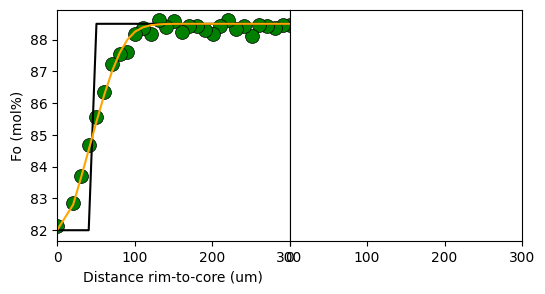

In [103]:
# Define datasets
datasets = [K24_ols_profiles_Kendra,K24_ols_profiles_Kendra]
titles = ["Fo", 
          "Ni, Ca"]

# Define the number of subplots based on datasets
num_axes = len(datasets)

# Generate colors using a seaborn color palette
annotation_colors = sns.color_palette("viridis", num_axes)  # Darker contrasting colors

# Create subplots
fig, axes = plt.subplots(1, num_axes, figsize=(6, 3), sharey=False)

# Plot data
for i, (ax, data, title, ann_color) in enumerate(zip(axes, datasets, titles, annotation_colors)):
    
    if i==0:
        ax.scatter(x=data['Distance (μm)'],y=data['Fo'],marker='o',s=100,linewidths=0.5,edgecolors='k',color='green')
        ax.plot(data['Distance (μm)'],data['Initial'],color='k')
        ax.plot(data['Distance (μm)'],data['Model'],color='orange')
    # else:
        # ax.scatter(x=data['Distance (μm)'],y=data[' CaO WT%'],marker='s',s=100,linewidths=0.5,edgecolors='k',color='orange')
        # ax.scatter(x=data['Distance (μm)'],y=data[' NiO WT%'],marker='d',s=100,linewidths=0.5,edgecolors='k',color='midnightblue')
    # sns.violinplot(data=data['GOS'], color=ann_color, inner='stick', ax=ax, cut=0)
    
    # # Set y-axis properties
    # ax.set_ylim([10,0])  # Inverted y-axis
  # Inverted y-axis
    if i == 0:
        ax.set_xlabel('Distance rim-to-core (um)')
        ax.set_ylabel('Fo (mol%)')
        ax.set_xlim([0,300])
    else:
        ax.yaxis.set_tick_params(left=False, labelleft=False)
        ax.set_xlim([0,300])

    
    # Add title and annotation
    fontsize = 9

# Adjust layout and save
plt.subplots_adjust(wspace=0)  # Slight spacing between plots
fig.savefig(figpath + slash + 'Ol2_Dec20_profile.pdf', format='pdf', dpi=300, transparent=False)


In [104]:
K24_ols_profiles_Kendra=pd.read_excel(MasterFolder+slash+"Data"+slash+"Unpubd data from Kendra"+slash+"3087-1_Lynn_2020Kilauea_DataTables_01122024.xlsx",sheet_name="S1 Timescales Summary",skiprows=2)
K24_ols_profiles_Kendra =K24_ols_profiles_Kendra.loc[:, ~K24_ols_profiles_Kendra.columns.str.contains('Unnamed')].dropna(how='all')#.drop(K24_ols_profiles_Kendra.tail(6).index)

# K24_ols_profiles_Kendra=K24_ols_profiles_Kendra[K24_ols_profiles_Kendra['Valid']==1]
K24_ols_profiles_Kendra


,Olivine ID,Zoning Type,Ci,Co,t (days),± (days)
0,1,Normal,88.5,82.4,187.0,56.0
1,2,Normal,88.5,82.0,30.0,9.0
2,3,Normal,87.5,82.0,64.0,19.0
3,5,Normal,87.9,82.4,238.0,71.0
4,7,Normal,88,82.3,43.0,13.0
5,10,Normal,88.2,82.0,326.0,98.0
6,11,Normal,87.8,83.4,39.0,12.0
7,12,Normal,88,82.7,51.0,15.0
8,13,Normal,88.2,83.0,60.0,18.0
9,15,Normal,88,83.1,521.0,156.0


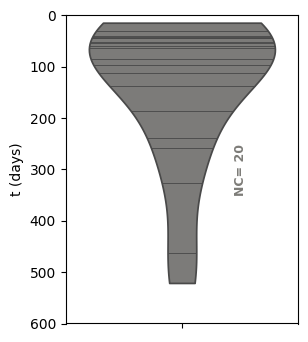

In [105]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define datasets
datasets = [K24_ols_profiles_Kendra]  # Can have more datasets, but for now let's assume one
titles = ["SWRZ\n(Dec 1974)"]

# Define the number of subplots based on datasets
num_axes = len(datasets)

# Generate colors using a seaborn color palette
annotation_colors = sns.color_palette("cividis", num_axes)  # Darker contrasting colors

# Create subplots
fig, axes = plt.subplots(1, num_axes, figsize=(3, 4), sharey=True)

# If there's only one axis, make it iterable (like a list)
if num_axes == 1:
    axes = [axes]

# Plot data
for i, (ax, data, title, ann_color) in enumerate(zip(axes, datasets, titles, annotation_colors)):
    
    # Create violin plot
    sns.violinplot(data=data['t (days)'], color=ann_color, inner='stick', ax=ax, cut=0,)
    
    ax.set_ylim([600,0])
    if i == 0:
        ax.set_ylabel('t (days)')
    else:
        ax.yaxis.set_tick_params(left=False, labelleft=False)
    
    # Add title and annotation
    fontsize = 9
    # ax.annotate(title, xy=(0.25, 0.5), xycoords='axes fraction', fontsize=fontsize,
    #             ha='center', va='center', color=ann_color, fontweight='bold', rotation=90)
    ax.annotate(f"NC= {len(data[(data['t (days)'].notna())])}",
                xy=(0.75, 0.5), xycoords='axes fraction', fontsize=fontsize,
                ha='center', va='center', color=ann_color, fontweight='bold', rotation=90)

# Adjust layout and save
plt.subplots_adjust(wspace=0)  # Slight spacing between plots

fig.savefig(figpath + slash + 'Dec20_Kendra_Ol_violin_plot.pdf', format='pdf', dpi=300, transparent=False)


# UP TO HERE I CLEANED UP ON JAN 30 2025

## Lets get the equilibrium Olivine Fo contents here 

In [28]:
import Thermobar as pt

In [30]:
Ulu_MG_input=pt.import_excel(r"C:\Users\charl\Documents\Python dev\PrePostCalderaKil_2025\Version_on_pcloud\Data\Data_SWRZ\1974_olivine_glass_data\UluData.xlsx",
                         sheet_name='Matrix Glass')
Ulu_all=Ulu_MG_input['my_input'] ## All columns
Ulu_Liqs_all=Ulu_MG_input['Liqs'] ## Just Liquid columns
Ulu_Liqs_19=Ulu_Liqs_all.loc[Ulu_all['Eruption']==919]
Ulu_Liqs_19.head()
Mean_19=np.mean(Ulu_Liqs_19)

In [41]:
## Glasses 


K24_MG_input=pt.import_excel(r"C:\Users\charl\Documents\Python dev\PrePostCalderaKil_2025\Version_on_pcloud\Data_processing_notebooks\Data_processing_SWRZ\Notebook_Compiled_data\GlassData2024.xlsx",
                         sheet_name='Sheet1', suffix='_Liq')
K24_all=K24_MG_input['my_input'] ## All columns
K24_Liqs_all=K24_MG_input['Liqs'][3:9] ## Just Liquid columns
Liq_Mean_24=np.mean(K24_Liqs_all)

In [42]:
Eq_Ol_19=pt.calculate_eq_ol_content(liq_comps=Ulu_Liqs_19, Kd_model="Shea2022",Fe3Fet_Liq=0.18)
Eq_Ol_24=pt.calculate_eq_ol_content(liq_comps=K24_Liqs_all, Kd_model="Shea2022",Fe3Fet_Liq=0.18)

In [43]:
np.mean(Eq_Ol_19['Eq Fo (Shea, Kd=0.335)'])

0.834256220498497

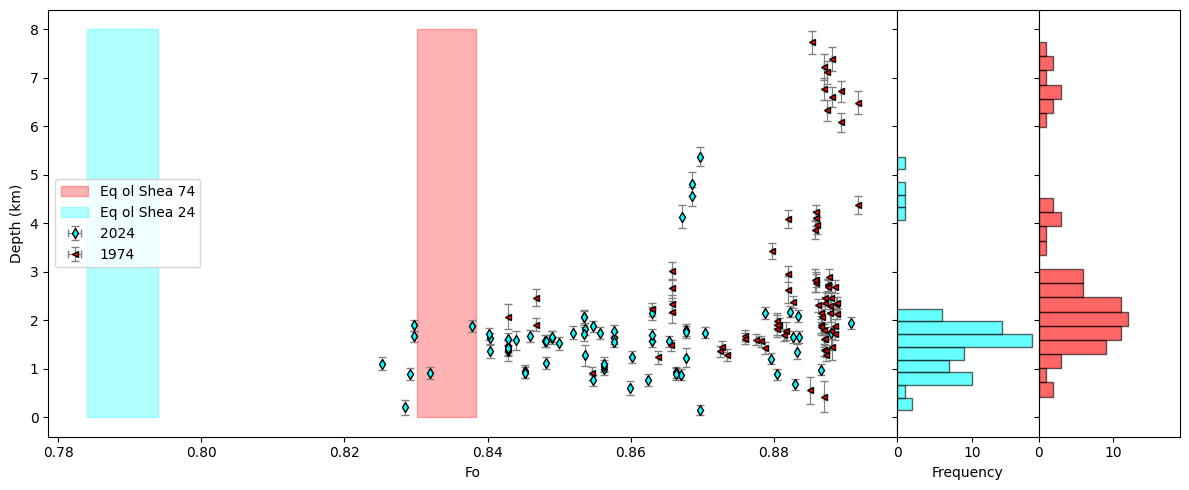

In [62]:
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(12, 5))
gs = gridspec.GridSpec(1, 3, width_ratios=[3, 0.5, 0.5], wspace=0)

ax1 = plt.subplot(gs[0])

# Calculate x coordinates and plot rectangles for Eq_Ol_19
x1 = np.mean(Eq_Ol_19['Eq Fo (Shea, Kd=0.325)'])
x2 = np.mean(Eq_Ol_19['Eq Fo (Shea, Kd=0.345)'])
ax1.fill_betweenx(y=[0, 8], x1=x1, x2=x2, color='red', alpha=0.3, label='Eq ol Shea 74')

# Calculate x coordinates and plot rectangles for Eq_Ol_24
x1 = np.mean(Eq_Ol_24['Eq Fo (Shea, Kd=0.325)'])
x2 = np.mean(Eq_Ol_24['Eq Fo (Shea, Kd=0.345)'])
ax1.fill_betweenx(y=[0, 8], x1=x1, x2=x2, color='cyan', alpha=0.3, label='Eq ol Shea 24')

# Plot error bars
ax1.errorbar(df_combo['Fo'].loc[K24], MC_Av_rho_T_df_B['SingleCalc_D_km'].loc[K24], xerr=0, yerr=MC_Av_rho_T_df_B['std_dev_MC_D_km_from_percentile'].loc[K24],
             fmt='d', ecolor='grey', elinewidth=0.8, mfc='cyan', ms=5, mec='k', capsize=3, label='2024')
ax1.errorbar(df_combo['Fo'].loc[U919], MC_Av_rho_T_df_B['SingleCalc_D_km'].loc[U919], xerr=0, yerr=MC_Av_rho_T_df_B['std_dev_MC_D_km_from_percentile'].loc[U919],
             fmt='<', ecolor='grey', elinewidth=0.8, mfc='red', ms=5, mec='k', capsize=3, label='1974')

ax1.set_xlabel('Fo')
ax1.set_ylabel('Depth (km)')
ax1.legend()

# Histogram plot
ax2 = plt.subplot(gs[1], sharey=ax1)
ax3 = plt.subplot(gs[2], sharey=ax1, sharex=ax2)
ax2.hist(MC_Av_rho_T_df_B['SingleCalc_D_km'].loc[K24], bins=20, stacked=True, orientation='horizontal', color=['cyan'], ec='k', alpha=0.6)
ax3.hist(MC_Av_rho_T_df_B['SingleCalc_D_km'].loc[U919], bins=25, stacked=True, orientation='horizontal', color=['red'], ec='k', alpha=0.6)

ax2.set_xlabel('Frequency')
plt.setp(ax2.get_yticklabels(), visible=False)
plt.setp(ax3.get_yticklabels(), visible=False)
plt.tight_layout()
fig.savefig('FoDepth.png', dpi=300)
plt.show()